# 018. DPO(Direct Preference Optimization) / Direct Preference Optimization

## 1. 概要 / Overview

DPO(Direct Preference Optimization、直接選好最適化)は、RLHF(Reinforcement Learning from Human Feedback)の
KL 正則化つきの目的関数の最適解を報酬について解き直し、Bradley-Terry モデルに代入することで、報酬モデルの学習と強化学習の
2 段階を、選好データに対する 1 つの分類損失に置き換える手法である。本トピックでは DPO と、決定的な選好での過適合を避ける
IPO(Identity Preference Optimization)をスクラッチ実装し、[017](./017_reward_model_and_rlhf.ipynb) で作った参照方策
(合成課題で SFT したモデル)と既知の真の報酬 $r^*$ の上で、(A)$\beta$ を小さくしていくと真の報酬が上がってから下がる
**過最適化(overoptimization)** が報酬モデルなしでも起きるか、(B)ラベルが決定的なときに DPO のマージンが伸び続け IPO では
そうならないか、(C)マージンが広がる一方で選好された応答の尤度が下がる **尤度の置き換わり(likelihood displacement)**
が起きるか、(D)それが似た応答の組ほど大きいかを検証する。

### 1.1 実行の手順

本番実行は Google Colab T4 の **1 つのセッションで完結** させる。5.1 節のセットアップセルで`SMOKE_TEST = False`にして、
「すべてのセルを実行」する。

実行時間の予算は 1 セッションあたり **T4 で 120 分** とする。本番の学習を始める前に(6.4 節)、スケーリングの計測
(6.3 節)から 1 セッション全体の実行時間を **削る段階**(6.1 節)ごとに見積もり、予算に収まる最小の段階を自動で選ぶ。
選択は見積もりのみに基づき、どの実験の結果も参照しない。最後の段階でも予算を超える場合は、学習の前に例外で停止する。

本トピックで学習したモデルは後続のトピックの入力にならず、読者がノートブックの外で試すためのものでもないので、
Hugging Face Hub にはアップロードしない。

## 2. 参考論文 / References

1. Rafailov, R., Sharma, A., Mitchell, E., Ermon, S., Manning, C. D., Finn, C.,
   "Direct Preference Optimization: Your Language Model is Secretly a Reward Model", NeurIPS 2023.
   https://arxiv.org/abs/2305.18290(DPO の原典。3.2・3.3 節)
2. Azar, M. G., Rowland, M., Piot, B., Guo, D., Calandriello, D., Valko, M., Munos, R.,
   "A General Theoretical Paradigm to Understand Learning from Human Preferences", AISTATS 2024.
   https://arxiv.org/abs/2310.12036(ΨPO の一般形と IPO、決定的な選好での過適合。3.4・3.5 節、実験 B)
3. Rafailov, R., Chittepu, Y., Park, R., Sikchi, H., Hejna, J., Knox, B., Finn, C., Niekum, S.,
   "Scaling Laws for Reward Model Overoptimization in Direct Alignment Algorithms", NeurIPS 2024.
   https://arxiv.org/abs/2406.02900(直接選好最適化の過最適化。3.7 節、実験 A)
4. Razin, N., Malladi, S., Bhaskar, A., Chen, D., Arora, S., Hanin, B.,
   "Unintentional Unalignment: Likelihood Displacement in Direct Preference Optimization", ICLR 2025.
   https://arxiv.org/abs/2410.08847(尤度の置き換わりと CHES スコア。3.6 節、実験 C・D)
5. Pal, A., Karkhanis, D., Dooley, S., Roberts, M., Naidu, S., White, C.,
   "Smaug: Fixing Failure Modes of Preference Optimisation with DPO-Positive", arXiv 2024.
   https://arxiv.org/abs/2402.13228(編集距離の小さい組で選好された応答の尤度が下がること。3.6 節、実験 D)
6. Ethayarajh, K., Xu, W., Muennighoff, N., Jurafsky, D., Kiela, D.,
   "KTO: Model Alignment as Prospect Theoretic Optimization", ICML 2024. https://arxiv.org/abs/2402.01306(3.8 節)
7. Hong, J., Lee, N., Thorne, J., "ORPO: Monolithic Preference Optimization without Reference Model", EMNLP 2024.
   https://arxiv.org/abs/2403.07691(3.8 節)
8. Meng, Y., Xia, M., Chen, D., "SimPO: Simple Preference Optimization with a Reference-Free Reward", NeurIPS 2024.
   https://arxiv.org/abs/2405.14734(3.8 節)
9. Xu, S., Fu, W., Gao, J., Ye, W., Liu, W., Mei, Z., Wang, G., Yu, C., Wu, Y.,
   "Is DPO Superior to PPO for LLM Alignment? A Comprehensive Study", ICML 2024. https://arxiv.org/abs/2404.10719(3.8 節)
10. Tajwar, F., Singh, A., Sharma, A., Rafailov, R., Schneider, J., Xie, T., Ermon, S., Finn, C., Kumar, A.,
    "Preference Fine-Tuning of LLMs Should Leverage Suboptimal, On-Policy Data", ICML 2024.
    https://arxiv.org/abs/2404.14367(3.8 節)
11. Gao, L., Schulman, J., Hilton, J., "Scaling Laws for Reward Model Overoptimization", ICML 2023.
    https://arxiv.org/abs/2210.10760(報酬モデルの過最適化。017 の実験 B・C。3.7 節)
12. Christiano, P. F., Leike, J., Brown, T. B., Martic, M., Legg, S., Amodei, D.,
    "Deep Reinforcement Learning from Human Preferences", NeurIPS 2017. https://arxiv.org/abs/1706.03741(3.1 節)
13. Ouyang, L., Wu, J., Jiang, X., Almeida, D., Wainwright, C. L., Mishkin, P., Zhang, C., Agarwal, S., Slama, K.,
    Ray, A., et al., "Training Language Models to Follow Instructions with Human Feedback", NeurIPS 2022.
    https://arxiv.org/abs/2203.02155(InstructGPT の RLHF の 3 段階。3.1 節)
14. Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L., Chen, W.,
    "LoRA: Low-Rank Adaptation of Large Language Models", ICLR 2022. https://arxiv.org/abs/2106.09685
    (方策の学習に使う。[012](../03_efficient_training/012_low_rank_adaptation.ipynb))

## 3. 理論 / Theory

### 3.1 動機: RLHF の 2 段階の学習

[017](./017_reward_model_and_rlhf.ipynb) の RLHF(Christiano et al. [12]、Ouyang et al. [13])は、SFT(Supervised
Fine-Tuning、教師あり微調整)の後に、選好データから報酬モデル $r_\phi$ を学習し、その報酬を KL 正則化つきで最大化する
方策を PPO(Proximal Policy Optimization)で学習した。この 2 段階には次の手間がある。

- 報酬モデルという 2 つ目のモデルを学習し、方策の学習中にはロールアウト(方策からの応答のサンプリング)ごとに
  スコアリングしなければならない。
- PPO は価値関数・GAE(Generalized Advantage Estimation)・クリップの幅・KL ペナルティの係数 $\beta$ など多くの
  超パラメータを持つ。017 の PPO では、KL 係数が小さい条件で、代理報酬(報酬モデルのスコア)が上がる一方で真の報酬が
  下がった。

DPO(Rafailov et al., NeurIPS 2023 [1])は、017 の 3.4 節で導出した最適解の形を使って、この 2 段階を **選好データに対する
1 つの損失** に置き換える。

```mermaid
flowchart LR
    subgraph RLHF["RLHF(017): 3 段階"]
        S1["SFT"] --> R1["報酬モデル r_phi を学習<br/>(Bradley-Terry の損失)"]
        R1 --> P1["PPO で方策を学習<br/>(ロールアウト・価値関数・KL ペナルティ)"]
    end
    subgraph DPO["DPO(018): 2 段階"]
        S2["SFT(= 参照方策 pi_ref)"] --> D2["選好の組で方策を直接学習<br/>(DPO 損失。サンプリングなし)"]
    end
```

### 3.2 DPO 損失の導出

017 の 3.4 節で、KL 正則化つきの目的関数

$$
\max_\pi \; \mathbb{E}_{x \sim \mathcal{X}} \left[ \mathbb{E}_{y \sim \pi(\cdot \mid x)} [ r(x, y) ]
- \beta \, \mathrm{KL}\left( \pi(\cdot \mid x) \,\|\, \pi_{\mathrm{ref}}(\cdot \mid x) \right) \right]
$$

の最適解が

$$
\pi^*(y \mid x) = \frac{1}{Z(x)} \pi_{\mathrm{ref}}(y \mid x) \exp\left( \frac{r(x, y)}{\beta} \right), \qquad
Z(x) = \sum_y \pi_{\mathrm{ref}}(y \mid x) \exp\left( \frac{r(x, y)}{\beta} \right)
$$

であることを導いた。記号は次のとおりである。

- $x$: プロンプト(指示部分)。$\mathcal{X}$: プロンプトの分布。$y$: 応答。
- $r(x, y)$: 報酬。$\pi_{\mathrm{ref}}$: 参照方策(SFT モデル)。$\pi^*$: 最適な方策。
- $\beta > 0$: KL 正則化の係数。$Z(x)$: 分配関数(プロンプトだけの関数)。

**報酬について解く**: 両辺の対数をとって整理すると

$$
r(x, y) = \beta \log \frac{\pi^*(y \mid x)}{\pi_{\mathrm{ref}}(y \mid x)} + \beta \log Z(x)
$$

となる。すなわち、任意の報酬は「その報酬の最適方策と参照方策の対数比の $\beta$ 倍」に、プロンプトだけの項を足したもので
表せる。

**Bradley-Terry モデルに代入する**: 017 の 3.2 節の Bradley-Terry モデルは、同じプロンプトへの 2 つの応答のうち $y_w$ が
$y_l$ より選好される確率を

$$
P(y_w \succ y_l \mid x) = \sigma\left( r(x, y_w) - r(x, y_l) \right)
$$

とする。ここで $y_w$ は選好された応答、$y_l$ は選好されなかった応答、$\sigma(z) = 1 / (1 + e^{-z})$ はシグモイド関数、
$\succ$ は「選好される」を表す。上の $r$ を代入すると、報酬の **差** だけが現れるので $\beta \log Z(x)$ は打ち消され

$$
P(y_w \succ y_l \mid x) = \sigma\left( \beta \log \frac{\pi^*(y_w \mid x)}{\pi_{\mathrm{ref}}(y_w \mid x)}
- \beta \log \frac{\pi^*(y_l \mid x)}{\pi_{\mathrm{ref}}(y_l \mid x)} \right)
$$

となる。計算できない $Z(x)$(全応答の和)が消えることが要点である。017 の 3.2 節で述べた「報酬は定数の差を除いて
しか識別できない」性質が、ここでは $Z(x)$ を消す働きをしている。

**最尤推定**: 最適方策 $\pi^*$ をパラメータ $\theta$ の方策 $\pi_\theta$ で置き換え、選好データ $\mathcal{D}$ の負の対数尤度を
最小化すると、DPO 損失

$$
\mathcal{L}_{\mathrm{DPO}}(\theta) = -\mathbb{E}_{(x, y_w, y_l) \sim \mathcal{D}} \left[ \log \sigma\left(
\beta \log \frac{\pi_\theta(y_w \mid x)}{\pi_{\mathrm{ref}}(y_w \mid x)}
- \beta \log \frac{\pi_\theta(y_l \mid x)}{\pi_{\mathrm{ref}}(y_l \mid x)} \right) \right]
$$

が得られる。報酬モデルを経由せず、方策そのものを 017 の報酬モデルと同じ Bradley-Terry の損失で学習する。サンプリング
(ロールアウト)は不要で、学習は選好データ上の教師あり学習になる。

### 3.3 暗黙の報酬(implicit reward)と勾配

**暗黙の報酬**: 3.2 節の式から、方策 $\pi_\theta$ は報酬

$$
\hat{r}_\theta(x, y) = \beta \log \frac{\pi_\theta(y \mid x)}{\pi_{\mathrm{ref}}(y \mid x)}
$$

の最適方策とみなせる(論文の副題「言語モデルは密かに報酬モデルである」)。DPO 損失は、この暗黙の報酬を報酬モデルとした
Bradley-Terry の損失 $-\log \sigma(\hat{r}_\theta(x, y_w) - \hat{r}_\theta(x, y_l))$ そのものである。暗黙の報酬による選好の
正解率($\hat{r}_\theta(x, y_w) > \hat{r}_\theta(x, y_l)$ である組の割合)を、学習が進んでいるかの指標に使う。

**勾配**: $u = \hat{r}_\theta(x, y_w) - \hat{r}_\theta(x, y_l)$ とおくと、$\frac{d}{du}\left[ -\log \sigma(u) \right] = -\sigma(-u)$ なので

$$
\nabla_\theta \mathcal{L}_{\mathrm{DPO}} = -\beta \, \mathbb{E}_{(x, y_w, y_l) \sim \mathcal{D}} \left[
\sigma\left( \hat{r}_\theta(x, y_l) - \hat{r}_\theta(x, y_w) \right)
\left( \nabla_\theta \log \pi_\theta(y_w \mid x) - \nabla_\theta \log \pi_\theta(y_l \mid x) \right) \right]
$$

となる($\pi_{\mathrm{ref}}$ は $\theta$ によらない)。勾配は $\log \pi_\theta(y_w \mid x)$ を上げ $\log \pi_\theta(y_l \mid x)$ を
下げる向きで、その重み $\sigma(\hat{r}_\theta(x, y_l) - \hat{r}_\theta(x, y_w))$ は、暗黙の報酬が組の順序を **誤って**
並べているほど大きく、正しく大きな差で並べるほど 0 に近づく。

**系列の対数確率の分解**: 自己回帰の言語モデルでは

$$
\log \pi_\theta(y \mid x) = \sum_{t=1}^{\lvert y \rvert} \log \pi_\theta(y_t \mid x, y_{<t})
$$

である($y_t$ は応答の $t$ 番目のトークン、$y_{<t}$ はそれより前のトークン、$\lvert y \rvert$ は応答のトークン数)。和は
**応答部分のトークンだけ** にわたり、プロンプトのトークンは含めない。プロンプトは $x$ として条件に入るだけで、その尤度は
$y_w$ と $y_l$ で共通なので差をとると消える。これは [016](./016_supervised_fine_tuning.ipynb) の損失マスク(指示部分の
トークンを損失に含めない)と同じ区別である。

```mermaid
flowchart LR
    B["選好の組のバッチ<br/>(x, y_w, y_l)"] --> P["方策 pi_theta(LoRA)で順伝播<br/>log pi_theta(y_w), log pi_theta(y_l)<br/>(応答部分のトークンの和)"]
    B --> R["参照方策 pi_ref(事前計算)<br/>log pi_ref(y_w), log pi_ref(y_l)"]
    P --> H["対数比のマージン h"]
    R --> H
    H --> L1["DPO 損失 -log sigma(beta h)"]
    H --> L2["IPO 損失 (h - 1/(2 tau))^2"]
    L1 --> U["LoRA のパラメータを更新"]
    L2 --> U
```

### 3.4 記法: 対数比のマージン

以降の実験では、Azar et al.(AISTATS 2024 [2])の記法に従い、**対数比のマージン**

$$
h_\theta(x, y_w, y_l) = \log \frac{\pi_\theta(y_w \mid x) \, \pi_{\mathrm{ref}}(y_l \mid x)}{\pi_\theta(y_l \mid x) \, \pi_{\mathrm{ref}}(y_w \mid x)}
= \log \frac{\pi_\theta(y_w \mid x)}{\pi_{\mathrm{ref}}(y_w \mid x)} - \log \frac{\pi_\theta(y_l \mid x)}{\pi_{\mathrm{ref}}(y_l \mid x)}
$$

を使う(単位は nats)。DPO 損失は $\mathcal{L}_{\mathrm{DPO}} = \mathbb{E}\left[ -\log \sigma(\beta h_\theta) \right]$ と書ける。
学習の前($\pi_\theta = \pi_{\mathrm{ref}}$)には $h_\theta = 0$ で、DPO 損失は $\log 2$ である。

### 3.5 決定的な選好での過適合と IPO

**経験的な選好確率**: 同じ組 $(x, y, y')$ が $K$ 回観測され、そのうち $y$ が選好された割合を $\hat{p} \in [0, 1]$ とする。
この組の DPO 損失の和を $K$ で割ると、$h = h_\theta(x, y, y')$(向きを $y$ が先に固定する。$h_\theta(x, y', y) = -h$)について

$$
\ell_{\mathrm{DPO}}(h) = -\hat{p} \log \sigma(\beta h) - (1 - \hat{p}) \log \sigma(-\beta h)
$$

となる。これは 2 値の交差エントロピーで、$\hat{p} \in (0, 1)$ なら $\sigma(\beta h) = \hat{p}$、すなわち **有限の**

$$
h^*_{\mathrm{DPO}} = \frac{1}{\beta} \mathrm{logit}(\hat{p}) = \frac{1}{\beta} \log \frac{\hat{p}}{1 - \hat{p}}
$$

で最小になる。

**決定的な選好**(Azar et al. [2] の議論): $\hat{p} = 1$ なら $\ell_{\mathrm{DPO}}(h) = -\log \sigma(\beta h)$ は $h$ について単調に減少し、
最小値は $h \to \infty$ でしか達成されない。$\pi_\theta(y \mid x) \le 1$ なので、$h \to \infty$ には
$\pi_\theta(y' \mid x) \to 0$ が必要であり、これは **$\beta$ の値によらない**。KL 正則化の係数 $\beta$ は、本来は方策が
$\pi_{\mathrm{ref}}$ から離れすぎるのを防ぐためのものだが、決定的な選好のもとでは損失の最小点を変えず(到達の速さを変える
だけで)、正則化として働かない。

**有限のデータでは $\hat{p}$ は 0 か 1 になる**: 実際の選好データでは、各組は通常 **1 回しか観測されない**($K = 1$)。
このとき、ラベルが Bradley-Terry モデルから確率的に抽選されたものであっても、経験的な選好確率 $\hat{p}$ は 0 か 1 であり、
上の「決定的な選好」の状況になる。DPO の最適解では、観測された組の選好されなかった応答の確率が 0 に押しやられる。

**ΨPO と IPO**: Azar et al. [2] は、非減少の関数 $\Psi: [0, 1] \to \mathbb{R}$ を使った一般形(ΨPO)

$$
\max_\pi \; \mathbb{E}_{x \sim \mathcal{X}} \, \mathbb{E}_{y \sim \pi(\cdot \mid x), \, y' \sim \mu(\cdot \mid x)}
\left[ \Psi\left( p^*(y \succ y' \mid x) \right) \right] - \tau \, \mathrm{KL}(\pi \,\|\, \pi_{\mathrm{ref}})
$$

を考えた。$p^*(y \succ y' \mid x)$ は真の選好確率、$\mu$ はデータの応答の分布、$\tau > 0$ は KL 正則化の係数(DPO の
$\beta$ に対応する)である。Bradley-Terry モデルのもとで $\Psi(q) = \log(q / (1 - q))$ とすると RLHF・DPO の目的関数に
一致する。この $\Psi$ は $q \to 1$ で発散するので、決定的な選好が過適合を生む。$\Psi$ を **恒等写像** $\Psi(q) = q$ とした
ものが IPO(Identity Preference Optimization)で、その経験損失は

$$
\mathcal{L}_{\mathrm{IPO}}(\theta) = \mathbb{E}_{(x, y_w, y_l) \sim \mathcal{D}} \left[
\left( h_\theta(x, y_w, y_l) - \frac{1}{2\tau} \right)^2 \right]
$$

である。マージンを有限の目標値 $1 / (2\tau)$ へ回帰させるので、$\hat{p} = 1$ でも最適なマージンは有限である。

**IPO の最適なマージン**: 同じ組が $y$ の選好として $\hat{p}$ の割合、$y'$ の選好として $1 - \hat{p}$ の割合で観測されるとき、
損失は

$$
\ell_{\mathrm{IPO}}(h) = \hat{p} \left( h - \frac{1}{2\tau} \right)^2 + (1 - \hat{p}) \left( -h - \frac{1}{2\tau} \right)^2
$$

で、$\frac{d \ell_{\mathrm{IPO}}}{dh} = 2\hat{p}\left(h - \frac{1}{2\tau}\right) + 2(1 - \hat{p})\left(h + \frac{1}{2\tau}\right) = 0$ から

$$
h^*_{\mathrm{IPO}} = \frac{2\hat{p} - 1}{2\tau}
$$

となる。$\hat{p} = 1$ でも $1 / (2\tau)$ にとどまり、$\tau$ が小さいほど目標値は大きい(正則化が弱い)。本トピックでは $\tau = \beta$
とする。実験 B は、同じ組を $K$ 回重複させたデータで、この 2 つの損失の振る舞いの違いを検証する。

### 3.6 尤度の置き換わり(likelihood displacement)

DPO 損失はマージン $h_\theta$(2 つの対数比の **差**)にしか依存しない。したがって、損失が下がってマージンが広がっても、
$\log \pi_\theta(y_w \mid x)$ 自体が上がるとは限らない。$\log \pi_\theta(y_w \mid x)$ と $\log \pi_\theta(y_l \mid x)$ がともに
下がり、$y_l$ の方が大きく下がれば、マージンは広がる。

**勾配の共有による説明**: 学習率 $\eta$ の勾配法の 1 ステップで、1 つの組 $(x, y_w, y_l)$ だけで更新したときの
$\log \pi_\theta(y_w \mid x)$ の変化は、1 次の近似で

$$
\Delta \log \pi_\theta(y_w \mid x) \approx \eta \beta \, \sigma\left( -\beta h_\theta \right)
\left( \lVert g_w \rVert^2 - \langle g_w, g_l \rangle \right), \qquad
g_w = \nabla_\theta \log \pi_\theta(y_w \mid x), \; g_l = \nabla_\theta \log \pi_\theta(y_l \mid x)
$$

となる(3.3 節の勾配と $g_w$ の内積)。$\langle g_w, g_l \rangle$ が $\lVert g_w \rVert^2$ を上回るとき、すなわち $y_w$ と $y_l$ の勾配が
よく似ているとき、選好された応答の尤度は **下がる**。$y_w$ と $y_l$ が共通の接頭辞や共通のトークンを多く持つほど、
同じパラメータ・似た内部表現を通って確率が決まるので、$y_l$ を下げる勾配が $y_w$ も下げる。

**CHES スコア**(Razin et al., ICLR 2025 [4]): Razin et al. は、隠れ状態(語彙への射影の直前の、最終層の隠れ状態)と
語彙の埋め込みに着目した解析から、この現象の起こりやすさを表す **CHES スコア**(centered hidden embedding similarity、
中心化した隠れ状態の類似度)

$$
\mathrm{CHES}_x(y_w, y_l) = \left\langle \sum_{k=1}^{\lvert y_w \rvert} h_{x, y_{w, <k}}, \; \sum_{k'=1}^{\lvert y_l \rvert} h_{x, y_{l, <k'}} \right\rangle
- \left\lVert \sum_{k=1}^{\lvert y_w \rvert} h_{x, y_{w, <k}} \right\rVert^2
$$

を導いた。$h_{x, y_{<k}} \in \mathbb{R}^{d_{\mathrm{model}}}$ は、プロンプト $x$ と応答の先頭 $k - 1$ トークンを入力したときの
隠れ状態(応答の $k$ 番目のトークンを予測する位置の隠れ状態)、$d_{\mathrm{model}}$ は隠れ状態の次元である。上の勾配の式の
$\langle g_w, g_l \rangle - \lVert g_w \rVert^2$ を隠れ状態で表した形で、CHES スコアが大きいほど $\log \pi_\theta(y_w \mid x)$ が
下がりやすい。長さで正規化した版(同論文の Definition 3)は、内積を $\lvert y_w \rvert \lvert y_l \rvert$ で、第 2 項を
$\lvert y_w \rvert^2$ で割る。

**編集距離の小さい組**(Pal et al., arXiv 2024 [5]): Pal et al. は、$y_w$ と $y_l$ が少数のトークンしか違わない(編集距離の
小さい)組で DPO を行うと、選好された応答の尤度が下がりうることを理論と実験で示した(違いのある位置より後のトークンで
確率が下がる)。実験 D は、応答の文字列の正規化編集距離を類似度の代理として、近い組だけ・遠い組だけで学習したときの
$\log \pi_\theta(y_w \mid x)$ の下がり方を比べる。編集距離は勾配の共有の度合いの **代理** にすぎないので、CHES スコアを
診断量として併記する。

### 3.7 直接選好最適化の過最適化

017 の 3.6 節の過最適化(Gao et al., ICML 2023 [11])は、学習した報酬モデル(代理報酬)と真の報酬のずれに最適化の圧力が
かかることで起きた。DPO には明示的な報酬モデルがないが、Rafailov et al.(NeurIPS 2024 [3])は、DPO などの直接選好最適化
(Direct Alignment Algorithms)でも、$\beta$ を小さくして KL ダイバージェンスの予算を大きくするほど、真の報酬(彼らの実験では
より強いモデルによる評価)がはじめ上がり、やがて下がることを報告した。

**理由**: 暗黙の報酬 $\hat{r}_\theta$ は有限の選好データから推定した報酬であり、017 の報酬モデルと同じく真の報酬とずれる。
3.5 節のとおり、有限のデータでは $\hat{p}$ が 0 か 1 になるので、DPO はデータに現れた選好されなかった応答の確率を 0 へ
押しやり、その分の確率をデータの外の応答(選好データに現れず、暗黙の報酬が正しく評価できない応答)へ移しうる。
$\beta$ が小さいほど方策は $\pi_{\mathrm{ref}}$ から遠くへ動けるので、このずれにつけ込む余地が大きくなる。

**017 の best-of-n との対応**(定性的な比較のみ): 017 の best-of-n では、最適化の圧力を $n$ で、方策の移動量を KL の
上界 $\log n - (n - 1)/n$ で表した。DPO では圧力を $1/\beta$ で表し、移動量はサンプリングによる KL ダイバージェンスの推定値で
測る。本トピックは報酬モデルを学習しないので、同じ KL での両者の真の報酬を定量的には比べない。

**KL ダイバージェンスの推定**: 方策 $\pi_\theta$ の KL ダイバージェンスを、$\pi_\theta$ からサンプリングした応答による
モンテカルロ推定

$$
\widehat{\mathrm{KL}} = \frac{1}{M} \sum_{i=1}^{M} \left[ \log \pi_\theta(y_i \mid x_i) - \log \pi_{\mathrm{ref}}(y_i \mid x_i) \right],
\qquad y_i \sim \pi_\theta(\cdot \mid x_i)
$$

で求める($M$ は応答の数、$x_i$ は評価用のプロンプト)。これは $\mathbb{E}_x[\mathrm{KL}(\pi_\theta(\cdot \mid x) \,\|\,
\pi_{\mathrm{ref}}(\cdot \mid x))]$ の不偏推定量である。

### 3.8 位置づけ: DPO の派生手法と、off-policy / on-policy のデータ

DPO の後、参照方策や組の構造を変えた手法が提案された。本トピックでは実装せず、位置づけのみを述べる。

| 手法 | 学習に使うデータ | 参照方策 | 要点 |
|---|---|---|---|
| DPO [1] | 組 $(x, y_w, y_l)$ | 使う | 暗黙の報酬 $\beta \log(\pi_\theta / \pi_{\mathrm{ref}})$ の Bradley-Terry の損失 |
| IPO [2] | 組 | 使う | マージンを $1 / (2\tau)$ へ回帰させる二乗損失。決定的な選好でも最適解が有限 |
| KTO [6] | 単独の応答と「良い / 悪い」の 2 値のラベル | 使う | 組を作らずに学習する。プロスペクト理論の価値関数の形の損失 |
| ORPO [7] | 組 | 使わない | SFT の損失にオッズ比の項を足し、SFT と選好の学習を 1 段階にまとめる |
| SimPO [8] | 組 | 使わない | 長さで正規化した平均対数確率 $\frac{\beta}{\lvert y \rvert} \log \pi_\theta(y \mid x)$ を暗黙の報酬とし、目標のマージンを加える |

KTO(Kahneman-Tversky Optimization)・ORPO(Odds Ratio Preference Optimization)・SimPO(Simple Preference Optimization)の
正式名称は、それぞれの論文の題名に対応する。

**off-policy と on-policy のデータ**: 本トピックの選好データは、学習の前に参照方策 $\pi_{\mathrm{ref}}$ から 1 度だけ
サンプリングした応答の組であり、学習中の方策 $\pi_\theta$ からは取り直さない(off-policy)。学習が進んで $\pi_\theta$ が
$\pi_{\mathrm{ref}}$ から離れると、データの応答は $\pi_\theta$ が実際に生成する応答を代表しなくなる。Xu et al.(ICML 2024 [9])は、
DPO が分布の外の応答に偏った解を見つけうること、学習中の方策からデータを取り直すと改善することを示し、PPO との比較を行った。
Tajwar et al.(ICML 2024 [10])は、学習中の方策からサンプリングしたデータ(on-policy)と、確率を下げる方向の目的関数
(負の勾配)が、望ましい応答が参照方策で低い確率にあるときに有効であることを示した。017 の PPO はロールアウトのたびに
方策から応答を取り直す on-policy の手法である。

### 3.9 アルゴリズム

```text
procedure DPO_018(pi_ref, loss in {DPO, IPO}, beta):
    pairs  <- (x, y1, y2) with y1, y2 ~ pi_ref(. | x), drop y1 == y2 and r*(y1) == r*(y2)
    kappa  <- log 3 / median(|r*(y1) - r*(y2)|)                           # 017, 3.3
    labels <- K draws from Bernoulli(sigma(kappa (r*(y1) - r*(y2))))       # stochastic
              or K copies of [r*(y1) > r*(y2)]                              # deterministic
    ref_w, ref_l <- log pi_ref(y_w | x), log pi_ref(y_l | x)   (precomputed once, cached)
    policy <- pi_ref + LoRA (W_q, W_v), B = 0  (so policy == pi_ref at step 0)
    for step in 1..T:
        (x, y_w, y_l) <- minibatch of instances
        h <- (log pi(y_w|x) - ref_w) - (log pi(y_l|x) - ref_l)            # sums over response tokens
        loss <- mean(-log sigma(beta h))            if DPO                  # 3.2
                mean((h - 1/(2 beta))^2)            if IPO (tau = beta)     # 3.5
        update LoRA parameters with AdamW
    evaluate: y ~ policy(. | x_eval) -> E[r*(y)], KL estimate mean(log pi(y) - log pi_ref(y))
```

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装、本トピックで新規作成または拡張)**:

- `src/training/direct_preference.py`(新規):
  - 応答部分の対数確率の和(`sequence_log_prob_sums()`は勾配を保つ版、`compute_response_log_prob_sums()`は評価用の
    勾配なしの版)。バッチ化は 017 の`collate_rollout_sequences()`(`src/training/ppo.py`)をそのまま使う。トークンの
    対数確率の取り出しは、017 の`gather_response_log_probs()`と同じ位置・同じ one-hot の積だが、語彙への射影を応答の位置に
    限って行う(017 の関数は全位置の logits を作るので、語彙 8192 のもとで学習のメモリと時間の大半を占めた。値が一致する
    ことを 5.6 節で照合する)。017 の関数は変更していない。
  - 参照方策の対数確率の事前計算`precompute_reference_log_probs()`(呼び出し側の辞書をキャッシュとして、条件・シードを
    またいで再利用する)。
  - 対数比のマージン`compute_log_ratio_margin()`、DPO 損失`dpo_loss()`($-\log \sigma(z)$ を`torch.logaddexp(0, -z)`で
    計算)、IPO 損失`ipo_loss()`。
  - 学習ループ`train_direct_preference()`(損失の種類を引数で切り替える。ステップごとの損失・マージン・暗黙の報酬による
    正解率・$\log \pi_\theta(y_w) - \log \pi_{\mathrm{ref}}(y_w)$ などを記録し、指定したステップ(実験 B の $T/2$ と $T$)で
    評価関数を呼んで結果を記録する)。
  - CHES スコアの計算`compute_ches_statistics()`・`ches_from_statistics()`(Razin et al. の Definition 2・3)。
- `src/data/preference.py`(017 の既存モジュールへの追加。既存の関数は変更しない):
  - $K$ 回独立に抽選したラベル`sample_preference_label_matrix()`、決定的なラベルを $K$ 回重複させる
    `deterministic_preference_label_matrix()`、事例の列への展開`flatten_preference_labels()`。
  - 正規化編集距離`normalized_edit_distance()`(既存の`levenshtein_distance()`を長い方の文字数で割る)と、層ごとに近い組・
    遠い組を同数選ぶ`select_similarity_stratified_pairs()`。

**ノートブック内に直接書く(018 固有)**: 016 の評価集合の再生成と参照方策の照合、プロンプトの分割、選好の組の生成、
学習の実行と条件の組み合わせ、**方策の評価**(方策からのサンプリングによる真の報酬の期待値と KL ダイバージェンスの推定。
017 の`sample_generate_until_stop()`と`compute_true_reward()`を呼ぶ)、$\beta$ の較正、判定、スケーリングの計測。
方策の評価は 016・017 の合成課題の真の報酬に依存するので、018 固有としてノートブックに置く。

**参照方策の扱い**: 参照方策 $\pi_{\mathrm{ref}}$ は凍結した`GPTLanguageModel`として 1 つだけメモリに持ち、方策はその
複製に LoRA(Low-Rank Adaptation、[012](../03_efficient_training/012_low_rank_adaptation.ipynb))を Query・Value 射影に
$r = 8$ で掛けたものとする。LoRA の $B$ は 0 で初期化されるので、学習前の方策は参照方策と一致する(5.6 節で確かめる)。
学習データの応答の $\log \pi_{\mathrm{ref}}$ は学習中に変わらないので **事前計算してキャッシュ** し、全条件・全シードで
再利用する(参照方策の順伝播は学習データについて 1 回だけになる)。方策からサンプリングした評価用の応答は学習した方策ごとに
異なるので、その $\log \pi_{\mathrm{ref}}$ は保持している参照方策で計算する。アダプタを無効にして参照方策の代わりにする設計は
とらない。LoRA の層に無効化の機能を足す変更が必要になるうえ、本トピックのモデル(約 520 万パラメータ、約 21 MB)では
参照方策を別に持つメモリの負担が無視できるためである。

**アップロード方針**: Hugging Face Hub へのアップロードはしない。学習した方策は条件比較のためのもので、後続のトピックの
入力にならず、読者がノートブックの外で試すためのものでもない。

**生成物の置き場所**:

| 生成物 | 置き場所 |
|---|---|
| 参照方策・トークナイザ | Hugging Face Hub から取得(`kojikojiprg/ai-theories-small-gpt-en`のブランチ`sft-synthetic`、`kojikojiprg/ai-theories-tokenizer-en`)。018 では書き込まない |
| プロンプト・選好の組・ラベル・参照方策の対数確率(キャッシュ) | メモリ上のみ(同一セッション内。入力から決定的に再生成できる。ファイルに保存しない) |
| 学習した方策 | メモリ上のみ(評価の直後に破棄する) |
| 判定の記録 | 判定と前提条件を計算した各セルの出力 |

外部から取得するのは、Hugging Face Hub の参照方策(`sft-synthetic`のブランチの`config.json`・`model_state.pt`)と
トークナイザ(`tokenizer.json`)のみである。018 は英語版 Wikipedia のコーパスを使わない。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)

`SMOKE_TEST`(スモークテストか本番か)はこのセルでのみ切り替える。本トピックは Hub にアップロードしないので、
アップロードのフラグはない。実行環境はこのセルで 1 回だけ印字する。再現性のため、CUDA の cuBLAS が決定的な演算を使うための
環境変数`CUBLAS_WORKSPACE_CONFIG`を torch の読み込み前に設定し、`torch.use_deterministic_algorithms(True)`を有効にする
(5.8 節で学習・生成の経路を一通り実行して確かめる)。

In [1]:
# 環境セットアップ(Google Colab)
import os
import sys
import time

SMOKE_TEST = True  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)

NOTEBOOK_START_TIME = time.time()
# cuBLAS を決定的にする(torch が CUDA を初期化する前に設定する必要がある)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.isdir("/content/ai-theories"):  # 2 回目の実行では clone し直さない
        !git clone https://github.com/kojikojiprg/ai-theories.git /content/ai-theories
    %cd /content/ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt

# インストールで版が入れ替わったパッケージの古い版がメモリに残っていないかを、torch などを import する前に確かめる。
# Colab では食い違いがあればカーネルを終了する(再接続後、もう一度「すべてのセルを実行」する)
from src.utils.environment import check_preloaded_package_versions  # noqa: E402

check_preloaded_package_versions(on_mismatch="restart" if IN_COLAB else "raise")

import torch  # noqa: E402

from src.utils.environment import print_execution_environment  # noqa: E402

torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
execution_environment = print_execution_environment(device)
print(
    f"SMOKE_TEST={SMOKE_TEST}、決定的な実行: {torch.are_deterministic_algorithms_enabled()}、"
    f"CUBLAS_WORKSPACE_CONFIG={os.environ['CUBLAS_WORKSPACE_CONFIG']}"
)

読み込み済みのパッケージの版の検査(requirements.txt): 食い違いなし。検査した配布物 3 個(packaging==26.3, python-dateutil==2.9.0.post0, six==1.17.0)、未読み込みのため検査しなかった配布物 50 個、__version__ がないため比べなかった配布物 1 個(typing-extensions)、表記の違いで誤検出するため比べなかった配布物 0 個(なし)


実行環境 / Execution environment
  Python                                 : 3.12.11
  OS / platform                          : macOS-26.6.2-arm64-arm-64bit
  torch                                  : 2.13.0
  torch のビルド時の CUDA                : 該当なし
  cuDNN                                  : 該当なし
  デバイス / device                      : mps
  GPU 名 / GPU name                      : 該当なし
  compute capability                     : 該当なし
  GPU の総メモリ (GiB)                   : 該当なし
  コミット / git commit                  : ffc9b5a5b9aa799d2025a56ae7de87f21ee1775c
  未コミットの変更 / uncommitted changes : あり
  実行日時 (UTC)                         : 2026-09-28T05:23:19+00:00
SMOKE_TEST=True、決定的な実行: True、CUBLAS_WORKSPACE_CONFIG=:4096:8


In [2]:
import copy
import functools
import hashlib
import itertools
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from huggingface_hub import hf_hub_download
from torch import nn

from src.data.instruction import (
    END_MARKER,
    TASK_NAMES,
    WORD_VOCABULARY,
    build_evaluation_examples,
    build_training_examples,
    encode_instruction_example,
    sample_word_sequences,
    score_generated_response,
)
from src.data.preference import (
    calibrate_label_scale,
    compute_bradley_terry_probability,
    compute_true_reward,
    deterministic_preference_label_matrix,
    flatten_preference_labels,
    normalized_edit_distance,
    sample_preference_label_matrix,
    select_similarity_stratified_pairs,
)
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub
from src.generation.stopping import greedy_generate_until_stop, sample_generate_until_stop
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.lora import LoRALinear, apply_lora
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.models.reward_model import compute_final_hidden_states
from src.training.direct_preference import (
    ches_from_statistics,
    compute_ches_statistics,
    compute_log_ratio_margin,
    compute_response_log_prob_sums,
    dpo_loss,
    ipo_loss,
    precompute_reference_log_probs,
    sequence_log_prob_sums,
    train_direct_preference,
)
from src.training.instruction_tuning import (
    evaluate_instruction_negative_log_likelihood,
    make_epoch_batches,
)
from src.training.optimizer import AdamW
from src.training.ppo import collate_rollout_sequences, gather_response_log_probs
from src.utils.reporting import dumps_compact_json
from src.utils.statistics import fit_power_law_exponent

MODEL_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"
REFERENCE_REVISION = "sft-synthetic"  # 017 がアップロードした参照方策(LoRA をマージした SFT モデル)
TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-tokenizer-en"


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def timed_call(fn) -> float:
    sync_device()
    start = time.time()
    fn()
    sync_device()
    return time.time() - start


def hash_json(obj) -> str:
    return hashlib.sha256(json.dumps(obj, sort_keys=True).encode("utf-8")).hexdigest()[:16]


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各節で記録)

/Users/koji/projects/ai-theories/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 5.2 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所(`LEVELS`)に集約する。参照方策は 017 の学習済みのものを使うので縮小しない。

**縮小の規則**:

- 選好の組の候補の数 $N_{\mathrm{cand}}$(本番 8192・スモークテスト 256)と、実験 A〜C の学習用の組の数 $N$(本番 2048・
  スモークテスト 64)を縮小する。**$N_{\mathrm{cand}} = 4N$** の関係を両水準で保つ(実験 D は候補から近い組・遠い組を
  それぞれ約 1/4 ずつ選ぶので、実験 D のデータ量が実験 A〜C とほぼ同じになる)。
- 学習ステップ数 $T$(本番 768・スモークテスト 24)を縮小する。バッチサイズ 32 事例は縮小せず、
  **$32 T = 3 N K$(実験 A〜C のデータをちょうど 3 エポック)** の関係を両水準で保つ。
- 評価用の入力の数 $\lvert X \rvert$(本番 128・スモークテスト 8)、$\beta$ の較正用の入力の数(本番 32・スモークテスト 4)、
  ブートストラップの反復回数を縮小する。
- **縮小しないもの**: 重複の回数 $K = 4$、評価用のプロンプトあたりのサンプル数 $m = 8$、$\beta$ の較正の格子(3.2〜0.1、
  公比 $\sqrt{2}$ の 11 点)、実験 A の水準が格子の連続する 6 点であること(公比 $\sqrt{2}$)、標準の $\beta$ の決め方、崩壊の領域の
  観察の水準(標準の $\beta$ から格子を 2 点・4 点下る)、学習率・LoRA の設定・warmup の比率、実験 D の層の作り方
  (課題 4 × $\lvert \Delta r^* \rvert$ の 4 区間)と選ぶ割合 1/4、前提条件・判定の閾値。
- **削る段階の表**(6.1 節)は本番とスモークテストで同じ構造にする。シード数は本番の 5 → 3 をスモークテストでは 3 → 2 に
  縮小する(「削る前 > 削った後 $\ge 2$」の順序関係を保つ)。
- **テスト専用の上書き**: 環境変数`AI_THEORIES_FORCE_STAGE`(0〜3)が設定されているときのみ、6.4 節で見積もりによる
  段階の選択の代わりにその段階を使う(スモークテストで全段階の経路を確かめるため)。本番では受け付けず、このセルで停止する。

In [3]:
# --- 全水準で共通の定数(本番実行前に宣言し、SMOKE_TEST で変えない) ---
TASK_COUNT = len(TASK_NAMES)  # 課題の数
MIN_WORDS, MAX_WORDS = 3, 8  # 入力の単語数(016・017 と同じ)
MAX_NEW_TOKENS = 32  # 生成の上限トークン数(016・017 と同じ)
TEMPERATURE = 1.0  # サンプリングの温度(top-k・top-p なし、017 と同じ)
GENERATION_BATCH_SIZE = 512  # サンプリングの 1 回の順伝播の事例数の上限(結果の再現性にのみ影響)
LOG_PROB_BATCH_SIZE = 256  # 評価用の対数確率の計算の 1 回の順伝播の系列数

# 参照方策の照合(017 の 6.5 節・6.14 節のセル出力から転記した独立な定数)
REFERENCE_SHA256_017 = "5814fbc024a27adc1624ee9a718fbbd5a7e28f5d20a0df40c8d4633126a91ab5"
REFERENCE_EXACT_MATCH_017 = 0.8180  # 016 の評価集合 1000 事例の貪欲法の完全一致率
REFERENCE_FORMAT_RATE_017 = 1.0000  # 同じ評価集合の形式の遵守率
REFERENCE_RESPONSE_NLL_017 = 0.6005  # 同じ評価集合の応答部分の負の対数尤度(nats / トークン)
REFERENCE_EXACT_TOLERANCE = 0.005  # 5 事例分(デバイスによる貪欲法の僅差の分かれを許す)
REFERENCE_NLL_TOLERANCE = 0.0005  # 017 の印字の丸め(0.00005)とデバイスの差を許す
DATA_SEED_016 = 16_016  # 016 の合成データの乱数シード(016 の評価集合を再生成する)
NUM_EVAL_INPUTS_016 = 250
SFT_NUM_EXAMPLES_016 = 65_536  # 016 の学習データの事例数(乱数の消費を 016 と揃える)

# 018 のプロンプト・選好の組・乱数シード
PROMPT_SEED = 18_018  # 評価用・較正用・学習用の入力(互いに素)
PAIR_SEED = 18_019  # 選好の組の応答のサンプリング(torch.Generator)
EVAL_PAIR_SEED = 18_020  # 評価用の組(実験 B の診断量)の応答のサンプリング
LABEL_SEED_BASE = 18_300  # シード s のラベルの抽選は np.random.default_rng(18300 + s)
LORA_INIT_SEED_BASE = 18_200  # シード s の LoRA の A の初期化は torch.manual_seed(18200 + s)
BATCH_SEED_BASE = 18_400  # シード s のミニバッチの順序は make_epoch_batches(..., 18400 + s)
EVAL_SAMPLE_SEED_BASE = (
    18_500  # シード s の方策の評価のサンプリング(全条件で共通の乱数の状態から始める)
)
CALIBRATION_SAMPLE_SEED = 18_600  # beta の較正の KL の推定のサンプリング
TIMING_SEED = 18_099  # スケーリングの計測専用
PILOT_INPUT_SPECS_018 = ((18_998, 4096), (18_997, 128))  # 6.2 節のパイロットの入力(本番から除く)

# 学習(6.2 節のパイロットで決めた値を含む)
NUM_DRAWS = 4  # K: 1 つの組を観測する回数(6.2 節。E[p_hat が (0, 1)] >= 0.5 となる最小の 2 のべき)
BATCH_SIZE = 32  # 1 ステップの事例の数(2 x 32 系列)
LEARNING_RATE = 1e-3  # 6.2 節のパイロット 3(学習の損失と発散の有無のみで決めた)
WARMUP_RATIO = 0.1  # 線形 warmup の後は一定(DPO の原論文の実装と同じ形)
LORA_RANK, LORA_ALPHA = 8, 8.0
LORA_TARGET_MODULES = ("w_q", "w_v")
CHECK_BETA = 0.1  # 5.6〜6.6 節の確認・計測だけに使う beta(判定には影響しない)
BETA_GRID = tuple(
    3.2 * 2.0 ** (-k / 2) for k in range(11)
)  # 較正の格子 3.2〜0.1(公比 sqrt(2)、11 点。6.2 節)
NUM_A_LEVELS = 6  # 実験 A の水準の数(格子の連続する 6 点、公比 sqrt(2)。最小の水準が標準の beta)
COLLAPSE_OFFSETS = (
    2,
    4,
)  # 崩壊の領域の観察: 標準の beta から格子を 2 点・4 点下った beta(判定なし、シード 0 のみ)
STANDARD_KL_MAX = 2.0  # 較正: 標準の beta(実験 B〜D、実験 A の最小の水準)は、KL がこの値以下にとどまる最小の beta(nats、6.1 節)
SAMPLES_PER_PROMPT = 8  # m: 評価用のプロンプトあたりのサンプル数
D_FRACTION = 0.25  # 実験 D: 各層で近い組・遠い組として選ぶ割合
D_REWARD_BINS = 4  # 実験 D: |Delta r*| の区間の数(候補の分位点で区切る)

# 前提条件・判定
ACCURACY_MIN = 0.55  # 学習の成立: 学習用の事例での暗黙の報酬による正解率
KL_RATIO_MIN = 4.0  # 実験 A: KL(最小の beta) / KL(最大の beta) の下限
MIXED_FRACTION_MIN = 0.4  # 実験 B: 確率的なラベルで p_hat が (0, 1) となる組の割合の下限
EXPECTED_MIXED_TARGET = 0.5  # K の決め方: E[p_hat が (0, 1)] の目標
KAPPA_TARGET = 0.75  # median sigma(kappa |Delta r*|) の目標(017 と同じ)
BOOTSTRAP_SEED = 0
SESSION_BUDGET_SECONDS = 120 * 60  # 1 セッションの予算(T4 で 120 分)

LEVELS = {
    "smoke": {
        "NUM_CANDIDATE_PAIRS": 256,
        "NUM_MAIN_PAIRS": 64,
        "TRAIN_STEPS": 24,
        "NUM_EVAL_INPUTS": 8,
        "NUM_CALIBRATION_INPUTS": 4,
        "BOOTSTRAP_RESAMPLES": 1_000,
    },
    "prod": {
        "NUM_CANDIDATE_PAIRS": 8192,
        "NUM_MAIN_PAIRS": 2048,
        "TRAIN_STEPS": 768,
        "NUM_EVAL_INPUTS": 128,
        "NUM_CALIBRATION_INPUTS": 32,
        "BOOTSTRAP_RESAMPLES": 10_000,
    },
}
CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
FORCED_STAGE_VALUE = os.environ.get("AI_THEORIES_FORCE_STAGE")
if FORCED_STAGE_VALUE is not None and not SMOKE_TEST:
    raise RuntimeError(
        f"本番(SMOKE_TEST=False)では段階の強制(AI_THEORIES_FORCE_STAGE={FORCED_STAGE_VALUE!r})を受け付けない。"
        "環境変数を削除して再実行すること。"
    )
FORCED_STAGE = None if FORCED_STAGE_VALUE is None else int(FORCED_STAGE_VALUE)
assert FORCED_STAGE is None or FORCED_STAGE in (0, 1, 2, 3), FORCED_STAGE

CFG = LEVELS[CURRENT_LEVEL_NAME]
PROD_CFG = LEVELS["prod"]
NUM_CANDIDATE_PAIRS = CFG["NUM_CANDIDATE_PAIRS"]
NUM_MAIN_PAIRS = CFG["NUM_MAIN_PAIRS"]  # N
TRAIN_STEPS = CFG["TRAIN_STEPS"]  # T
HALF_STEP = TRAIN_STEPS // 2  # 実験 B の T/2
NUM_EVAL_INPUTS = CFG["NUM_EVAL_INPUTS"]  # |X|
NUM_EVAL_PROMPTS = NUM_EVAL_INPUTS * TASK_COUNT
NUM_CALIBRATION_INPUTS = CFG["NUM_CALIBRATION_INPUTS"]
BOOTSTRAP_RESAMPLES = CFG["BOOTSTRAP_RESAMPLES"]

# --- 削る段階(6.1 節)。順序: 実験 D のシード数 -> 実験 A のシード数 -> 実験 B(と C)のシード数 ---
STAGES = {
    "prod": {
        0: {"NUM_SEEDS_D": 5, "NUM_SEEDS_A": 5, "NUM_SEEDS_B": 5},
        1: {"NUM_SEEDS_D": 3, "NUM_SEEDS_A": 5, "NUM_SEEDS_B": 5},
        2: {"NUM_SEEDS_D": 3, "NUM_SEEDS_A": 3, "NUM_SEEDS_B": 5},
        3: {"NUM_SEEDS_D": 3, "NUM_SEEDS_A": 3, "NUM_SEEDS_B": 3},
    },
    "smoke": {  # 本番と同じ構造(シード数 5 -> 3 を 3 -> 2 に縮小)
        0: {"NUM_SEEDS_D": 3, "NUM_SEEDS_A": 3, "NUM_SEEDS_B": 3},
        1: {"NUM_SEEDS_D": 2, "NUM_SEEDS_A": 3, "NUM_SEEDS_B": 3},
        2: {"NUM_SEEDS_D": 2, "NUM_SEEDS_A": 2, "NUM_SEEDS_B": 3},
        3: {"NUM_SEEDS_D": 2, "NUM_SEEDS_A": 2, "NUM_SEEDS_B": 2},
    },
}

# --- 縮小規則の確認 ---
assert set(LEVELS["smoke"]) == set(LEVELS["prod"])
for _name, _level in LEVELS.items():
    assert _level["NUM_CANDIDATE_PAIRS"] == 4 * _level["NUM_MAIN_PAIRS"]
    assert (
        BATCH_SIZE * _level["TRAIN_STEPS"] == 3 * _level["NUM_MAIN_PAIRS"] * NUM_DRAWS
    )  # 3 エポック
    assert _level["TRAIN_STEPS"] % 2 == 0  # T/2 が整数
    _stages = STAGES[_name]
    assert set(_stages) == {0, 1, 2, 3}
    for _k in range(1, 4):  # 段階が上がるほど、どの量も減るか変わらない
        for _key in ("NUM_SEEDS_D", "NUM_SEEDS_A", "NUM_SEEDS_B"):
            assert _stages[_k][_key] <= _stages[_k - 1][_key]
    assert all(min(s.values()) >= 2 for s in _stages.values())
for _k in range(1, 4):  # 本番とスモークテストで、各段階で何が変わるかが同じ(構造を保つ縮小)
    for _key in ("NUM_SEEDS_D", "NUM_SEEDS_A", "NUM_SEEDS_B"):
        assert (STAGES["prod"][_k][_key] == STAGES["prod"][_k - 1][_key]) == (
            STAGES["smoke"][_k][_key] == STAGES["smoke"][_k - 1][_key]
        )
for _key in LEVELS["prod"]:
    assert LEVELS["smoke"][_key] < LEVELS["prod"][_key], _key
assert all(
    math.isclose(a / b, math.sqrt(2.0)) for a, b in zip(BETA_GRID, BETA_GRID[1:], strict=False)
)  # 公比 sqrt(2)
assert math.isclose(BETA_GRID[0], 3.2) and math.isclose(BETA_GRID[-1], 0.1)
assert len(BETA_GRID) >= NUM_A_LEVELS

print(f"水準 {CURRENT_LEVEL_NAME!r}: {json.dumps(CFG)}")
print(
    f"学習: T = {TRAIN_STEPS}(T/2 = {HALF_STEP})、バッチ {BATCH_SIZE} 事例、学習率 {LEARNING_RATE}"
    f"(warmup {WARMUP_RATIO:.0%} の後は一定)、LoRA r = {LORA_RANK}・alpha = {LORA_ALPHA}・対象 {LORA_TARGET_MODULES}"
)
print(
    f"データ: 候補の組 N_cand = {NUM_CANDIDATE_PAIRS:,}、実験 A〜C の組 N = {NUM_MAIN_PAIRS:,}、K = {NUM_DRAWS}"
    f"(事例 {NUM_MAIN_PAIRS * NUM_DRAWS:,} = {BATCH_SIZE * TRAIN_STEPS // (NUM_MAIN_PAIRS * NUM_DRAWS)} エポック)"
)
print(
    f"評価: |X| = {NUM_EVAL_INPUTS}(プロンプト {NUM_EVAL_PROMPTS})x m = {SAMPLES_PER_PROMPT}、較正用の入力 "
    f"{NUM_CALIBRATION_INPUTS}、ブートストラップ {BOOTSTRAP_RESAMPLES:,} 回"
)
print(
    f"beta: 較正の格子 {[round(b, 6) for b in BETA_GRID]}、実験 A の水準の数 {NUM_A_LEVELS}(格子の連続する点)、"
    f"標準の beta の KL の閾値 {STANDARD_KL_MAX} nats、崩壊の領域の観察は標準の beta から格子を {COLLAPSE_OFFSETS} 点下る"
)
print(f"削る段階({CURRENT_LEVEL_NAME!r}、6.4 節で選ぶ): {json.dumps(STAGES[CURRENT_LEVEL_NAME])}")

水準 'smoke': {"NUM_CANDIDATE_PAIRS": 256, "NUM_MAIN_PAIRS": 64, "TRAIN_STEPS": 24, "NUM_EVAL_INPUTS": 8, "NUM_CALIBRATION_INPUTS": 4, "BOOTSTRAP_RESAMPLES": 1000}
学習: T = 24(T/2 = 12)、バッチ 32 事例、学習率 0.001(warmup 10% の後は一定)、LoRA r = 8・alpha = 8.0・対象 ('w_q', 'w_v')
データ: 候補の組 N_cand = 256、実験 A〜C の組 N = 64、K = 4(事例 256 = 3 エポック)
評価: |X| = 8(プロンプト 32)x m = 8、較正用の入力 4、ブートストラップ 1,000 回
beta: 較正の格子 [3.2, 2.262742, 1.6, 1.131371, 0.8, 0.565685, 0.4, 0.282843, 0.2, 0.141421, 0.1]、実験 A の水準の数 6(格子の連続する点)、標準の beta の KL の閾値 2.0 nats、崩壊の領域の観察は標準の beta から格子を (2, 4) 点下る
削る段階('smoke'、6.4 節で選ぶ): {"0": {"NUM_SEEDS_D": 3, "NUM_SEEDS_A": 3, "NUM_SEEDS_B": 3}, "1": {"NUM_SEEDS_D": 2, "NUM_SEEDS_A": 3, "NUM_SEEDS_B": 3}, "2": {"NUM_SEEDS_D": 2, "NUM_SEEDS_A": 2, "NUM_SEEDS_B": 3}, "3": {"NUM_SEEDS_D": 2, "NUM_SEEDS_A": 2, "NUM_SEEDS_B": 2}}


### 5.3 参照方策・トークナイザの取得(017 がアップロードしたもの)

参照方策 $\pi_{\mathrm{ref}}$ は`kojikojiprg/ai-theories-small-gpt-en`のブランチ`sft-synthetic`(017 で SFT し、LoRA をマージした
重み)、トークナイザは`kojikojiprg/ai-theories-tokenizer-en`から取得する。取得した`model_state.pt`の SHA-256 が、017 の
6.14 節のセル出力に記録された値(ノートブックに独立な定数として転記したもの)と一致することを確かめる。

In [4]:
tokenizer, _tokenizer_from_hub = load_bpe_id_tokenizer_from_hub(TOKENIZER_REPO_ID)
assert _tokenizer_from_hub, "トークナイザを Hugging Face Hub から取得できなかった"
_config_path = hf_hub_download(MODEL_REPO_ID, "config.json", revision=REFERENCE_REVISION)
_state_path = hf_hub_download(MODEL_REPO_ID, "model_state.pt", revision=REFERENCE_REVISION)
REFERENCE_SHA256 = hashlib.sha256(Path(_state_path).read_bytes()).hexdigest()
assert REFERENCE_SHA256 == REFERENCE_SHA256_017, (REFERENCE_SHA256, REFERENCE_SHA256_017)
MODEL_CONFIG = json.loads(Path(_config_path).read_text(encoding="utf-8"))
assert MODEL_CONFIG["positional_encoding"] == "rope"
assert MODEL_CONFIG["normalization"] == "rmsnorm" and MODEL_CONFIG["feed_forward"] == "swiglu"
assert MODEL_CONFIG["norm_first"] and MODEL_CONFIG["dropout"] == 0.0
assert tokenizer.vocab_size == MODEL_CONFIG["vocabulary_size"]
CONTEXT_LENGTH = MODEL_CONFIG["sequence_length"]
D_MODEL, NUM_LAYERS, NUM_HEADS = (
    MODEL_CONFIG["d_model"],
    MODEL_CONFIG["num_layers"],
    MODEL_CONFIG["num_heads"],
)


def build_model(state_dict: dict) -> GPTLanguageModel:
    model = GPTLanguageModel(
        vocabulary_size=MODEL_CONFIG["vocabulary_size"],
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=MODEL_CONFIG["d_ff"],
        max_sequence_length=CONTEXT_LENGTH,
        positional_transform=RotaryPositionEmbedding(
            D_MODEL // NUM_HEADS, max_position=CONTEXT_LENGTH
        ),
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(
            SwiGLUFeedForwardNetwork, D_MODEL, MODEL_CONFIG["swiglu_d_ff"]
        ),
        tie_embeddings=MODEL_CONFIG["tie_embeddings"],
    )
    result = model.load_state_dict(state_dict)
    assert not result.missing_keys and not result.unexpected_keys
    for p in model.parameters():
        p.requires_grad_(False)
    return model.to(device).eval()


REFERENCE_STATE = torch.load(_state_path, map_location="cpu")
reference_policy = build_model(REFERENCE_STATE)
TOTAL_PARAMETERS = sum(p.numel() for p in reference_policy.parameters())
print(
    f"参照方策: {MODEL_REPO_ID}@{REFERENCE_REVISION}、SHA-256 {REFERENCE_SHA256}(017 の記録と一致: OK)"
)
print(
    f"層数 = {NUM_LAYERS}、d_model = {D_MODEL}、ヘッド数 = {NUM_HEADS}、語彙サイズ = {tokenizer.vocab_size}、"
    f"文脈長 = {CONTEXT_LENGTH}、パラメータ数 = {TOTAL_PARAMETERS:,}"
)

参照方策: kojikojiprg/ai-theories-small-gpt-en@sft-synthetic、SHA-256 5814fbc024a27adc1624ee9a718fbbd5a7e28f5d20a0df40c8d4633126a91ab5(017 の記録と一致: OK)
層数 = 4、d_model = 256、ヘッド数 = 8、語彙サイズ = 8192、文脈長 = 256、パラメータ数 = 5,246,208


### 5.4 データ: 016 の評価集合の再生成と、018 のプロンプトの分割

**016 の評価集合の再生成**: 参照方策の照合(5.5 節)に使うため、016 と同じ関数・同じ乱数シード(`16016`)・同じ除外集合
(016 のパイロットの評価入力)で、016 の学習データと評価集合を再生成する(017 の 5.4 節と同じ手順)。016 の本番のセル出力と
照合できる量(評価集合の先頭の入力、パイロットの評価入力の数 726)をアサーションで確かめる。

**018 のプロンプト**: 016 の学習データ・評価集合・パイロットの評価入力、および 018 のパイロット(6.2 節)の入力と重複しない
入力を、1 つの乱数生成器(`PROMPT_SEED`)から順に引き、次の 3 つの互いに素な集合に分ける。参照方策の SFT の学習データを
除くのは、参照方策が学習で見た入力で方策を学習・評価しないためである。

| 集合 | 入力の数 | 事例の作り方 | 用途 |
|---|---|---|---|
| 評価用 | $\lvert X \rvert$ | 入力と 4 課題の直積(016 の`build_evaluation_examples()`) | 方策の評価(真の報酬・KL)、評価用の組 |
| 較正用 | 本番 32 | 同上 | $\beta$ の較正(KL のみを測る) |
| 学習用 | $N_{\mathrm{cand}}$ | 入力 1 つにつき 1 事例、4 事例ごとに 4 課題を 1 回ずつ(016 の`build_training_examples()`) | 選好の組の候補 |

プロンプトはすべて 016 の短い水準のテンプレート(学習に使った指示文、`SEEN_INSTRUCTIONS`)を使う。

In [5]:
_t0_data = time.time()
# --- 016 のパイロットの評価入力(016 の 5.4 節と同じ関数・同じ乱数シード) ---
PILOT_EVALUATION_INPUT_SPECS_016 = (
    (2016, 250, len(WORD_VOCABULARY), 3, 8),
    (1, 100, len(WORD_VOCABULARY), 3, 8),
    (1, 100, len(WORD_VOCABULARY), 4, 8),
    (1, 100, 32, 3, 8),
    (1, 100, 32, 4, 8),
    (1, 100, 16, 3, 8),
)
PILOT_EVALUATION_INPUTS_016 = set()
for _seed, _count, _vocab, _lo, _hi in PILOT_EVALUATION_INPUT_SPECS_016:
    PILOT_EVALUATION_INPUTS_016 |= set(
        sample_word_sequences(
            np.random.default_rng(_seed), _count, WORD_VOCABULARY[:_vocab], _lo, _hi
        )
    )

# --- 016 の学習データ・評価集合(016 の build_dataset と同じ手順) ---
_rng_016 = np.random.default_rng(DATA_SEED_016)
_eval_inputs_016 = sample_word_sequences(
    _rng_016,
    NUM_EVAL_INPUTS_016,
    WORD_VOCABULARY,
    MIN_WORDS,
    MAX_WORDS,
    exclude=PILOT_EVALUATION_INPUTS_016,
)
_train_inputs_016 = sample_word_sequences(
    _rng_016,
    SFT_NUM_EXAMPLES_016,
    WORD_VOCABULARY,
    MIN_WORDS,
    MAX_WORDS,
    exclude=set(_eval_inputs_016) | PILOT_EVALUATION_INPUTS_016,
)
build_training_examples(_train_inputs_016, _rng_016)  # 乱数の消費を 016 と揃える
EVAL_EXAMPLES_016 = build_evaluation_examples(_eval_inputs_016, _rng_016)
assert len(PILOT_EVALUATION_INPUTS_016) == 726  # 016 の 5.4 節の印字と一致
assert _eval_inputs_016[0] == (
    "agreement",
    "green",
    "billion",
    "software",
    "genus",
    "member",
    "novel",
    "community",
)  # 016 の 5.4 節の印字(評価集合の先頭の入力)と一致
EVAL_ENCODED_016 = [
    encode_instruction_example(tokenizer.encode, tokenizer.decode, e.prompt(False), e.response())
    for e in EVAL_EXAMPLES_016
]

# --- 018 のパイロットの入力(6.2 節。本番の入力と重複させない) ---
PILOT_INPUTS_018 = set()
for _seed, _count in PILOT_INPUT_SPECS_018:
    PILOT_INPUTS_018 |= set(
        sample_word_sequences(
            np.random.default_rng(_seed), _count, WORD_VOCABULARY, MIN_WORDS, MAX_WORDS
        )
    )

# --- 018 のプロンプト: 評価用・較正用・学習用(互いに素) ---
_excluded = (
    set(_train_inputs_016) | set(_eval_inputs_016) | PILOT_EVALUATION_INPUTS_016 | PILOT_INPUTS_018
)
_rng = np.random.default_rng(PROMPT_SEED)
EVAL_INPUTS = sample_word_sequences(
    _rng, NUM_EVAL_INPUTS, WORD_VOCABULARY, MIN_WORDS, MAX_WORDS, exclude=_excluded
)
CALIBRATION_INPUTS = sample_word_sequences(
    _rng,
    NUM_CALIBRATION_INPUTS,
    WORD_VOCABULARY,
    MIN_WORDS,
    MAX_WORDS,
    exclude=_excluded | set(EVAL_INPUTS),
)
TRAIN_INPUTS = sample_word_sequences(
    _rng,
    NUM_CANDIDATE_PAIRS,
    WORD_VOCABULARY,
    MIN_WORDS,
    MAX_WORDS,
    exclude=_excluded | set(EVAL_INPUTS) | set(CALIBRATION_INPUTS),
)
EVAL_EXAMPLES = build_evaluation_examples(EVAL_INPUTS, _rng)
CALIBRATION_EXAMPLES = build_evaluation_examples(CALIBRATION_INPUTS, _rng)
TRAIN_EXAMPLES = build_training_examples(TRAIN_INPUTS, _rng)
EVAL_PROMPT_IDS = [tokenizer.encode(e.prompt(False)) for e in EVAL_EXAMPLES]
CALIBRATION_PROMPT_IDS = [tokenizer.encode(e.prompt(False)) for e in CALIBRATION_EXAMPLES]
TRAIN_PROMPT_IDS = [tokenizer.encode(e.prompt(False)) for e in TRAIN_EXAMPLES]
DATA_SECONDS = time.time() - _t0_data

# --- 不変条件: 学習用と評価用(と較正用)のプロンプトの入力が重ならない ---
_sets = {"評価用": set(EVAL_INPUTS), "較正用": set(CALIBRATION_INPUTS), "学習用": set(TRAIN_INPUTS)}
for _a, _b in itertools.combinations(_sets, 2):
    assert not (_sets[_a] & _sets[_b]), f"{_a} と {_b} の入力が重複する"
for _name, _s in _sets.items():
    assert not (_s & _excluded), f"{_name} の入力が 016 のデータ・パイロットの入力と重複する"
assert len(set(TRAIN_INPUTS)) == NUM_CANDIDATE_PAIRS and len(set(EVAL_INPUTS)) == NUM_EVAL_INPUTS
assert [(e.words, e.task) for e in EVAL_EXAMPLES] == [
    (x, t) for x in EVAL_INPUTS for t in TASK_NAMES
]
assert all(not e.unseen for e in EVAL_EXAMPLES + CALIBRATION_EXAMPLES + TRAIN_EXAMPLES)
_longest_prompt = max(map(len, EVAL_PROMPT_IDS + CALIBRATION_PROMPT_IDS + TRAIN_PROMPT_IDS))
assert _longest_prompt + MAX_NEW_TOKENS <= CONTEXT_LENGTH
EVAL_INPUT_INDEX = np.repeat(np.arange(NUM_EVAL_INPUTS), TASK_COUNT)  # プロンプト -> 入力 x

print(
    f"016 の評価集合を再生成: {len(EVAL_EXAMPLES_016)} 事例、016 のパイロットの評価入力 {len(PILOT_EVALUATION_INPUTS_016)} 個、"
    "先頭の評価入力が 016 の印字と一致: OK"
)
print(
    f"018 のプロンプト: 評価用 {len(EVAL_EXAMPLES)}(|X| = {NUM_EVAL_INPUTS} x {TASK_COUNT} 課題)、較正用 "
    f"{len(CALIBRATION_EXAMPLES)}、学習用 {len(TRAIN_EXAMPLES):,}。互いに素で、016 のデータ・016 と 018 のパイロットの入力とも"
    f"重複しない: OK。最長のプロンプト {_longest_prompt} トークン({DATA_SECONDS:.1f}s)"
)

016 の評価集合を再生成: 1000 事例、016 のパイロットの評価入力 726 個、先頭の評価入力が 016 の印字と一致: OK
018 のプロンプト: 評価用 32(|X| = 8 x 4 課題)、較正用 16、学習用 256。互いに素で、016 のデータ・016 と 018 のパイロットの入力とも重複しない: OK。最長のプロンプト 45 トークン(0.5s)


### 5.5 参照方策の照合

読み込んだ参照方策で、017 が記録した評価値を再計算して照合する。期待値は 017 のセル出力から転記した定数(5.2 節の
`REFERENCE_*_017`)で、実測値は読み込んだ重みから計算するので、両者は同じ変数に由来しない。

- 016 の評価集合(250 入力 × 4 課題 = 1000 事例)での貪欲法の完全一致率(017: 0.8180、許容 ±0.005)と形式の遵守率
  (017: 1.0000、許容 ±0.005)。許容は、デバイスによって logits の僅差の候補で貪欲法の選択が分かれうる分(5 事例)である。
- 同じ評価集合の応答部分の負の対数尤度(教師強制、017: 0.6005 nats / トークン、許容 ±0.0005)。

照合に失敗したら、以降の実験は意味を持たないので停止する。

In [6]:
_t0_refcheck = time.time()
_prompts_016 = [list(x.token_ids[: x.prompt_length]) for x in EVAL_ENCODED_016]
_generated_016 = greedy_generate_until_stop(
    reference_policy, _prompts_016, tokenizer.decode, END_MARKER, MAX_NEW_TOKENS, device, 64
)
_scores_016 = [
    score_generated_response(tokenizer.decode(g), e.answer)
    for g, e in zip(_generated_016, EVAL_EXAMPLES_016, strict=True)
]
REFERENCE_FORMAT_RATE = float(np.mean([s[0] for s in _scores_016]))
REFERENCE_EXACT_MATCH = float(np.mean([s[1] for s in _scores_016]))
_nll = evaluate_instruction_negative_log_likelihood(reference_policy, EVAL_ENCODED_016, device)
REFERENCE_RESPONSE_NLL = float(_nll["response_sum"].sum() / _nll["response_count"].sum())
REFCHECK_SECONDS = time.time() - _t0_refcheck
print(
    f"完全一致率 {REFERENCE_EXACT_MATCH:.4f}(017: {REFERENCE_EXACT_MATCH_017:.4f}、差 "
    f"{REFERENCE_EXACT_MATCH - REFERENCE_EXACT_MATCH_017:+.4f})、形式の遵守率 {REFERENCE_FORMAT_RATE:.4f}"
    f"(017: {REFERENCE_FORMAT_RATE_017:.4f})、応答部分の負の対数尤度 {REFERENCE_RESPONSE_NLL:.5f}"
    f"(017: {REFERENCE_RESPONSE_NLL_017:.4f}、差 {REFERENCE_RESPONSE_NLL - REFERENCE_RESPONSE_NLL_017:+.5f})"
)
assert abs(REFERENCE_EXACT_MATCH - REFERENCE_EXACT_MATCH_017) <= REFERENCE_EXACT_TOLERANCE
assert abs(REFERENCE_FORMAT_RATE - REFERENCE_FORMAT_RATE_017) <= REFERENCE_EXACT_TOLERANCE
assert abs(REFERENCE_RESPONSE_NLL - REFERENCE_RESPONSE_NLL_017) <= REFERENCE_NLL_TOLERANCE
print(f"参照方策の照合: 017 の記録と許容の範囲で一致: OK({REFCHECK_SECONDS:.1f}s)")

完全一致率 0.8180(017: 0.8180、差 +0.0000)、形式の遵守率 1.0000(017: 1.0000)、応答部分の負の対数尤度 0.60045(017: 0.6005、差 -0.00005)
参照方策の照合: 017 の記録と許容の範囲で一致: OK(4.8s)


### 5.6 損失・対数確率・ラベル・類似度・CHES スコアのハーネスの確認

- **応答部分の対数確率**: `sequence_log_prob_sums()`(応答の位置だけを語彙へ射影する)が、017 の
  `gather_response_log_probs()`(全位置の logits から取り出す)の和と一致すること(行列積の丸めの範囲、$10^{-4}$ nats 以内)。
  `compute_response_log_prob_sums()`(長さ順のバッチ)が 1 系列ずつの計算と一致すること。
- **学習前の方策と参照方策の一致**: LoRA を掛けた直後($B = 0$)の方策の対数確率が、同じバッチの参照方策の対数確率と
  **bit 単位で一致** し、そこから計算した DPO 損失が $\log 2$、IPO 損失が $(1/(2\tau))^2$ に **完全に一致** すること。
- **損失と勾配**: `dpo_loss()`が`-F.logsigmoid`と一致すること、極端なマージンでも有限であること。DPO 損失のマージンに
  ついての勾配が $-\beta \sigma(-\beta h) / n$(3.3 節、$n$ はバッチの事例数)に一致すること。`ipo_loss()`の手計算との一致。
- **ラベル**: 重複させたラベルの抽選頻度が Bradley-Terry モデルの確率に一致すること、決定的なラベルが同点で停止すること、
  事例の列への展開の順序。
- **正規化編集距離・層別の選択**: 手計算の例との一致。層ごとの件数が近い組・遠い組で一致し、互いに重ならず、各層で近い組の
  距離が遠い組の距離以下であること。
- **CHES スコア**: バッチでの計算が 1 系列ずつの素朴な計算と一致すること。
- **学習ループ**: 数ステップの学習で、LoRA 以外のパラメータが参照方策と bit 単位で一致したまま(凍結)であること。

In [7]:
_t0_harness = time.time()
_rng_check = np.random.default_rng(0)
_probe_prompts = [TRAIN_PROMPT_IDS[i] for i in range(8)]
_probe_responses = sample_generate_until_stop(
    reference_policy,
    _probe_prompts * 2,
    tokenizer.decode,
    END_MARKER,
    MAX_NEW_TOKENS,
    device,
    torch.Generator(device=device).manual_seed(0),
    TEMPERATURE,
    GENERATION_BATCH_SIZE,
)

# --- 応答部分の対数確率: 017 の gather_response_log_probs() の和との照合 ---
_batch = [t.to(device) for t in collate_rollout_sequences(_probe_prompts * 2, _probe_responses)]
with torch.no_grad():
    _new = sequence_log_prob_sums(reference_policy, *_batch)
    _old = gather_response_log_probs(reference_policy(_batch[0]), *_batch).sum(dim=1)
LOG_PROB_PATH_MAX_DIFF = float((_new - _old).abs().max())
assert LOG_PROB_PATH_MAX_DIFF <= 1e-4, LOG_PROB_PATH_MAX_DIFF
_batched = compute_response_log_prob_sums(
    reference_policy, _probe_prompts * 2, _probe_responses, device, 5
)
_single = np.array(
    [
        compute_response_log_prob_sums(reference_policy, [p], [r], device)[0]
        for p, r in zip(_probe_prompts * 2, _probe_responses, strict=True)
    ]
)
assert np.abs(_batched - _single).max() <= 1e-4
print(
    f"応答部分の対数確率: 017 の gather_response_log_probs() の和との差の最大値 {LOG_PROB_PATH_MAX_DIFF:.2e}"
    f"(<= 1e-4)、長さ順のバッチと 1 系列ずつの差の最大値 {np.abs(_batched - _single).max():.2e}: OK"
)

# --- 学習前(LoRA の B = 0)の方策と参照方策の一致、初期の損失 ---
_policy = copy.deepcopy(reference_policy)
torch.manual_seed(LORA_INIT_SEED_BASE)
apply_lora(_policy, LORA_TARGET_MODULES, rank=LORA_RANK, alpha=LORA_ALPHA)
assert all(
    torch.count_nonzero(m.lora_b) == 0 for m in _policy.modules() if isinstance(m, LoRALinear)
)
with torch.no_grad():
    _policy_sums = sequence_log_prob_sums(_policy, *_batch)
    _reference_sums = sequence_log_prob_sums(reference_policy, *_batch)
assert torch.equal(_policy_sums, _reference_sums), (
    "B = 0 の方策と参照方策の対数確率が bit 単位で一致しない"
)
_margin0 = compute_log_ratio_margin(
    _policy_sums[:8], _policy_sums[8:], _reference_sums[:8], _reference_sums[8:]
)
assert torch.equal(_margin0, torch.zeros_like(_margin0))
# DPO 損失 = log 2: 丸めた値 float32(log 2) との差を印字する(logaddexp の実装の丸めで 1 ulp までずれうるので、
# 1 ulp 以内を許す)。IPO 損失 (0 - 1/(2 tau))^2 は正確に表せる値なので完全一致を求める。
_dpo_initial_loss = dpo_loss(_margin0, CHECK_BETA).cpu()
_dpo_initial_diff = float(
    (_dpo_initial_loss - torch.tensor(math.log(2.0), dtype=torch.float32)).abs()
)
assert _dpo_initial_diff <= torch.finfo(torch.float32).eps * math.log(2.0), _dpo_initial_diff
assert torch.equal(ipo_loss(_margin0, CHECK_BETA).cpu(), torch.tensor((1 / (2 * CHECK_BETA)) ** 2))
print(
    "学習前(B = 0)の方策と参照方策の対数確率が bit 単位で一致、マージン 0、DPO 損失と float32 の log 2 の差 "
    f"{_dpo_initial_diff:.1e}(1 ulp 以内)、IPO 損失 = (1/(2 tau))^2 = {(1 / (2 * CHECK_BETA)) ** 2:g}(完全に一致): OK"
)

# --- 損失と勾配 ---
_h = torch.tensor([3.0, -50.0, 0.0, 40.0, -1e4, 1e4], requires_grad=True)
torch.testing.assert_close(dpo_loss(_h, 0.5), -F.logsigmoid(0.5 * _h).mean())
dpo_loss(_h, 0.5).backward()
torch.testing.assert_close(_h.grad, -0.5 * torch.sigmoid(-0.5 * _h.detach()) / _h.numel())
assert torch.isfinite(dpo_loss(_h.detach(), 0.5))
torch.testing.assert_close(
    ipo_loss(torch.tensor([1.0, 7.0]), 0.1), torch.tensor(((1 - 5) ** 2 + (7 - 5) ** 2) / 2)
)
print(
    "DPO 損失: -logsigmoid と一致、勾配 = -beta sigma(-beta h) / n、極端なマージンでも有限。IPO 損失の手計算と一致: OK"
)

# --- ラベル ---
_first_r, _second_r = np.array([0.5, 0.6, 0.9]), np.array([0.6, 0.5, 0.1])
_matrix = sample_preference_label_matrix(
    _first_r, _second_r, 4.0, 100_000, np.random.default_rng(1)
)
np.testing.assert_allclose(
    _matrix.mean(axis=1), compute_bradley_terry_probability(_first_r - _second_r, 4.0), atol=0.01
)
assert deterministic_preference_label_matrix(_first_r, _second_r, 3).tolist() == [
    [False] * 3,
    [True] * 3,
    [True] * 3,
]
try:
    deterministic_preference_label_matrix(np.array([0.5]), np.array([0.5]), 2)
    raise AssertionError("同点で停止しなかった")
except ValueError:
    pass
_pairs, _chosen = flatten_preference_labels(np.array([[True, False], [False, False]]))
assert _pairs.tolist() == [0, 0, 1, 1] and _chosen.tolist() == [True, False, False, False]
print(
    "ラベル: 抽選頻度が Bradley-Terry の確率と一致(誤差 0.01 以内)、決定的なラベルと同点での停止、展開の順序: OK"
)

# --- 正規化編集距離・層別の選択 ---
assert math.isclose(normalized_edit_distance("abc", "abd"), 1 / 3)
assert normalized_edit_distance("", "") == 0.0 and normalized_edit_distance("a", "") == 1.0
_labels = [int(v) for v in _rng_check.integers(0, 5, size=500)]
_distances = _rng_check.random(500)
_near, _far, _counts = select_similarity_stratified_pairs(_labels, _distances, 0.25)
assert not (set(_near.tolist()) & set(_far.tolist()))
for _label, _c in _counts.items():
    _n = [i for i in _near if _labels[i] == _label]
    _f = [i for i in _far if _labels[i] == _label]
    assert len(_n) == len(_f) == _c["near"] == int(_c["size"] * 0.25)
    assert max(_distances[_n]) <= min(_distances[_f])
print("正規化編集距離の手計算、層別の選択(層ごとの件数の一致・重なりなし・近い組 <= 遠い組): OK")

# --- CHES スコア: 1 系列ずつの素朴な計算との照合 ---
_stats = compute_ches_statistics(
    reference_policy, _probe_prompts, _probe_responses[:8], _probe_responses[8:], device, 3
)


def _naive_hidden_sum(prompt, response):
    tokens = torch.tensor([list(prompt) + list(response)], device=device)
    with torch.no_grad():
        hidden = compute_final_hidden_states(reference_policy, tokens)[0]
    return (
        hidden[len(prompt) - 1 : len(prompt) - 1 + len(response)].sum(dim=0).cpu().double().numpy()
    )


for _i in range(8):
    _s1 = _naive_hidden_sum(_probe_prompts[_i], _probe_responses[_i])
    _s2 = _naive_hidden_sum(_probe_prompts[_i], _probe_responses[8 + _i])
    np.testing.assert_allclose(
        [_stats["inner"][_i], _stats["norm_first"][_i], _stats["norm_second"][_i]],
        [_s1 @ _s2, _s1 @ _s1, _s2 @ _s2],
        rtol=1e-4,
    )
_ches = ches_from_statistics(_stats, np.array([True, False] * 4))
np.testing.assert_allclose(_ches[1], _stats["inner"][1] - _stats["norm_second"][1])
print(
    "CHES スコア: バッチでの計算が 1 系列ずつの素朴な計算と一致(相対誤差 1e-4 以内)、向きの指定: OK"
)

# --- 学習ループ: LoRA 以外が凍結されていること ---
_reference_first = compute_response_log_prob_sums(
    reference_policy, _probe_prompts, _probe_responses[:8], device
)
_reference_second = compute_response_log_prob_sums(
    reference_policy, _probe_prompts, _probe_responses[8:], device
)
_history = train_direct_preference(
    _policy,
    _probe_prompts,
    _probe_responses[:8],
    _probe_responses[8:],
    _reference_first,
    _reference_second,
    [[0, 1, 2, 3], [4, 5, 6, 7], [0, 2, 4, 6]],
    AdamW([p for p in _policy.parameters() if p.requires_grad], lr=LEARNING_RATE, weight_decay=0.0),
    "dpo",
    CHECK_BETA,
    device,
)
_reference_parameters = dict(reference_policy.named_parameters())
for _name, _p in _policy.named_parameters():
    if _p.requires_grad:
        assert "lora_" in _name
    else:
        assert torch.equal(_p, _reference_parameters[_name.replace(".base_layer", "")]), _name
assert abs(_history["loss"][0] - math.log(2.0)) <= 1e-5 and len(_history["loss"]) == 3
del _policy
HARNESS_SECONDS = time.time() - _t0_harness
print(
    f"学習ループ: 3 ステップの後も LoRA 以外のパラメータが参照方策と bit 単位で一致、1 ステップ目の損失 "
    f"{_history['loss'][0]:.7f}(log 2 = {math.log(2):.7f}): OK"
)
print(f"\nこのセルの実行時間: {HARNESS_SECONDS:.1f}s")

応答部分の対数確率: 017 の gather_response_log_probs() の和との差の最大値 0.00e+00(<= 1e-4)、長さ順のバッチと 1 系列ずつの差の最大値 9.54e-06: OK
学習前(B = 0)の方策と参照方策の対数確率が bit 単位で一致、マージン 0、DPO 損失と float32 の log 2 の差 0.0e+00(1 ulp 以内)、IPO 損失 = (1/(2 tau))^2 = 25(完全に一致): OK
DPO 損失: -logsigmoid と一致、勾配 = -beta sigma(-beta h) / n、極端なマージンでも有限。IPO 損失の手計算と一致: OK
ラベル: 抽選頻度が Bradley-Terry の確率と一致(誤差 0.01 以内)、決定的なラベルと同点での停止、展開の順序: OK
正規化編集距離の手計算、層別の選択(層ごとの件数の一致・重なりなし・近い組 <= 遠い組): OK
CHES スコア: バッチでの計算が 1 系列ずつの素朴な計算と一致(相対誤差 1e-4 以内)、向きの指定: OK


学習ループ: 3 ステップの後も LoRA 以外のパラメータが参照方策と bit 単位で一致、1 ステップ目の損失 0.6931472(log 2 = 0.6931472): OK

このセルの実行時間: 1.2s


### 5.7 学習と評価のヘルパー

- `sample_responses()`: 方策から temperature 1.0(top-k・top-p なし)で終端記号まで生成する(017 と同じ)。
- `true_rewards()`: 応答を復号して $r^*$ を計算する(同じ文字列・同じ正解の組はキャッシュする)。
- `reference_log_probs()`: 学習データの応答の $\log \pi_{\mathrm{ref}}$ を`precompute_reference_log_probs()`で求める。
  鍵(参照方策の SHA-256・プロンプトと応答のハッシュ)ごとにキャッシュし、全条件・全シードで再利用する。
- `build_dataset()`: 組の添字とラベルの行列 $(N, K)$ から、学習の事例(プロンプト・$y_w$・$y_l$・その $\log \pi_{\mathrm{ref}}$)を
  作る。組の中の向きは、1 つ目の応答 $y_1$ を先にした $\hat{p}$($y_1$ が選ばれた割合)で持つ。
- `pair_statistics()`: 組ごとの $\log \pi_\theta - \log \pi_{\mathrm{ref}}$(`first`・`second`)と $\hat{p}$ から、事例単位の量
  (事例の平均。組 $i$ は事例 $K$ 個に対応するので、$\hat{p}_i$ で向きを重み付けした組の平均と等しい)を求める。
  $h_{1,i} = \Delta_{1,i} - \Delta_{2,i}$($\Delta$ は $\log \pi_\theta - \log \pi_{\mathrm{ref}}$、$y_1$ を選好とした向きのマージン)として
  - マージンの平均 $\bar{h} = \frac{1}{N} \sum_i (2\hat{p}_i - 1) h_{1,i}$
  - 暗黙の報酬による正解率 $\frac{1}{N} \sum_i \left[ \hat{p}_i \mathbb{1}(h_{1,i} > 0) + (1 - \hat{p}_i) \mathbb{1}(h_{1,i} < 0) \right]$
  - 選好された応答の対数比の平均 $\frac{1}{N} \sum_i \left[ \hat{p}_i \Delta_{1,i} + (1 - \hat{p}_i) \Delta_{2,i} \right]$(実験 C・D)
- `run_training()`: 1 つの条件・シードの学習と評価。LoRA の初期化(`torch.manual_seed(18200 + s)`)・ミニバッチの順序
  (`make_epoch_batches(K N, T, 32, 18400 + s)`)はシード $s$ で決まり、同じシードなら損失・ラベルが違っても共通である。
  学習中のステップ $T/2$ と $T$ で学習用の組全体の $\Delta_1, \Delta_2$ を記録する。学習の後、評価用のプロンプトごとに
  $m$ 個の応答をサンプリングし(乱数の状態はシードごとに全条件で共通)、真の報酬と KL ダイバージェンスの推定値を入力 $x$
  ごとの和として記録する(応答のトークン数と、終端記号で止まった応答の数も記録する)。$\beta$ の較正では、較正用のプロンプトで **KL ダイバージェンスのみ** を測り、真の報酬を計算しない。

In [8]:
def sample_responses(
    model: nn.Module, prompts: list, seed: int, stop_text: str = END_MARKER
) -> list:
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)
    return sample_generate_until_stop(
        model,
        prompts,
        tokenizer.decode,
        stop_text,
        MAX_NEW_TOKENS,
        device,
        generator,
        TEMPERATURE,
        GENERATION_BATCH_SIZE,
    )


TRUE_REWARD_CACHE: dict[tuple[str, tuple[str, ...]], float] = {}


def true_rewards(responses: list, examples: list) -> np.ndarray:
    values = np.empty(len(responses), dtype=np.float64)
    for i, (response, example) in enumerate(zip(responses, examples, strict=True)):
        key = (tokenizer.decode(response), example.answer)
        if key not in TRUE_REWARD_CACHE:
            TRUE_REWARD_CACHE[key] = compute_true_reward(*key)
        values[i] = TRUE_REWARD_CACHE[key]
    return values


REFERENCE_LOG_PROB_CACHE: dict = {}  # 参照方策の対数確率のキャッシュ(条件・シードをまたいで再利用)
CACHE_STATS = {"hit": 0, "miss": 0}


def reference_log_probs(prompts: list, responses: list, cache: dict | None) -> np.ndarray:
    key = (REFERENCE_SHA256, hash_json([prompts, responses]))
    values, hit = precompute_reference_log_probs(
        reference_policy,
        prompts,
        responses,
        device,
        LOG_PROB_BATCH_SIZE,
        cache,
        key if cache is not None else None,
    )
    CACHE_STATS["hit" if hit else "miss"] += 1
    return values


def learning_rate_schedule(num_steps: int):
    warmup = max(1, round(WARMUP_RATIO * num_steps))
    return lambda step: LEARNING_RATE * min(1.0, step / warmup)


def build_dataset(
    pairs: dict, pair_indices: np.ndarray, label_matrix: np.ndarray, cache: dict | None
) -> dict:
    # pairs: {"prompts", "first", "second"}(候補の組)。label_matrix[i, k] は組 pair_indices[i] の k 回目で y_1 が選ばれたか
    pair_indices = np.asarray(pair_indices)
    assert label_matrix.shape == (len(pair_indices), NUM_DRAWS)
    prompts = [pairs["prompts"][i] for i in pair_indices]
    first = [pairs["first"][i] for i in pair_indices]
    second = [pairs["second"][i] for i in pair_indices]
    reference_first = reference_log_probs(prompts, first, cache)
    reference_second = reference_log_probs(prompts, second, cache)
    local, first_chosen = flatten_preference_labels(label_matrix)
    return {
        "pair_indices": pair_indices,
        "prompts": prompts,
        "first": first,
        "second": second,
        "reference_first": reference_first,
        "reference_second": reference_second,
        "p_hat": label_matrix.mean(axis=1),  # y_1 が選ばれた割合
        "instances": {
            "prompts": [prompts[i] for i in local],
            "chosen": [
                first[i] if c else second[i] for i, c in zip(local, first_chosen, strict=True)
            ],
            "rejected": [
                second[i] if c else first[i] for i, c in zip(local, first_chosen, strict=True)
            ],
            "reference_chosen": np.where(
                first_chosen, reference_first[local], reference_second[local]
            ),
            "reference_rejected": np.where(
                first_chosen, reference_second[local], reference_first[local]
            ),
        },
    }


def pair_log_ratios(model: nn.Module, dataset: dict) -> dict:
    # 組ごとの log pi_theta - log pi_ref(学習用の組全体)。train_direct_preference の evaluate に渡す
    first = compute_response_log_prob_sums(
        model, dataset["prompts"], dataset["first"], device, LOG_PROB_BATCH_SIZE
    )
    second = compute_response_log_prob_sums(
        model, dataset["prompts"], dataset["second"], device, LOG_PROB_BATCH_SIZE
    )
    return {
        "first": first - dataset["reference_first"],
        "second": second - dataset["reference_second"],
    }


def pair_contributions(ratios: dict, p_hat: np.ndarray) -> dict:
    # 組ごとの寄与(組の平均をとると事例単位の平均になる)
    h1 = ratios["first"] - ratios["second"]
    return {
        "margin": (2 * p_hat - 1) * h1,
        "accuracy": p_hat * (h1 > 0) + (1 - p_hat) * (h1 < 0),
        "chosen_log_ratio": p_hat * ratios["first"] + (1 - p_hat) * ratios["second"],
        "rejected_log_ratio": p_hat * ratios["second"] + (1 - p_hat) * ratios["first"],
    }


def pair_statistics(ratios: dict, p_hat: np.ndarray) -> dict:
    return {k: float(v.mean()) for k, v in pair_contributions(ratios, p_hat).items()}


def build_policy(seed: int) -> GPTLanguageModel:
    policy = copy.deepcopy(reference_policy)
    torch.manual_seed(LORA_INIT_SEED_BASE + seed)
    apply_lora(policy, LORA_TARGET_MODULES, rank=LORA_RANK, alpha=LORA_ALPHA)
    return policy


def evaluate_policy(
    policy: nn.Module, prompts: list, examples: list | None, seed: int, stop_text: str = END_MARKER
) -> dict:
    # 方策から m 個ずつサンプリングし、KL の推定値(と examples があれば真の報酬)を入力 x ごとの和で返す
    flat_prompts = [p for p in prompts for _ in range(SAMPLES_PER_PROMPT)]
    responses = sample_responses(policy, flat_prompts, seed, stop_text)
    policy_lp = compute_response_log_prob_sums(
        policy, flat_prompts, responses, device, LOG_PROB_BATCH_SIZE
    )
    reference_lp = compute_response_log_prob_sums(
        reference_policy, flat_prompts, responses, device, LOG_PROB_BATCH_SIZE
    )
    per_input = SAMPLES_PER_PROMPT * TASK_COUNT  # 入力 1 つあたりの応答の数
    result = {
        "kl_by_input": (policy_lp - reference_lp).reshape(-1, per_input).sum(axis=1),
        "length_by_input": np.array([len(r) for r in responses], dtype=np.float64)
        .reshape(-1, per_input)
        .sum(axis=1),
        "stopped_by_input": np.array(
            [END_MARKER in tokenizer.decode(r) for r in responses], dtype=np.float64
        )
        .reshape(-1, per_input)
        .sum(axis=1),  # 終端記号で止まった応答の数
        "count_per_input": per_input,
    }
    if examples is not None:  # 真の報酬(beta の較正では計算しない)
        flat_examples = [e for e in examples for _ in range(SAMPLES_PER_PROMPT)]
        rewards = true_rewards(responses, flat_examples)
        result["true_reward_by_input"] = rewards.reshape(-1, per_input).sum(axis=1)
        result["exact_by_input"] = (
            (rewards == 1.0).reshape(-1, per_input).sum(axis=1).astype(np.float64)
        )
        result["example_response"] = tokenizer.decode(responses[0])
    total = per_input * len(result["kl_by_input"])
    result["kl"] = float(result["kl_by_input"].sum() / total)
    result["mean_tokens"] = float(result["length_by_input"].sum() / total)
    result["stop_rate"] = float(result["stopped_by_input"].sum() / total)
    return result


def run_training(
    dataset: dict,
    loss_type: str,
    beta: float,
    seed: int,
    evaluation: str,
    num_steps: int | None = None,
) -> dict:
    # evaluation: "full"(評価用のプロンプトで真の報酬と KL)、"kl_only"(較正用のプロンプトで KL のみ)、"none"
    num_steps = TRAIN_STEPS if num_steps is None else num_steps
    t0 = time.time()
    policy = build_policy(seed)
    instances = dataset["instances"]
    batches = make_epoch_batches(
        len(instances["prompts"]), num_steps, BATCH_SIZE, BATCH_SEED_BASE + seed
    )
    history = train_direct_preference(
        policy,
        instances["prompts"],
        instances["chosen"],
        instances["rejected"],
        instances["reference_chosen"],
        instances["reference_rejected"],
        batches,
        AdamW(
            [p for p in policy.parameters() if p.requires_grad], lr=LEARNING_RATE, weight_decay=0.0
        ),
        loss_type,
        beta,
        device,
        learning_rate_schedule(num_steps),
        evaluation_steps=(num_steps // 2, num_steps),
        evaluate=lambda model: pair_log_ratios(model, dataset),
    )
    train_seconds = time.time() - t0
    record = {
        "loss_type": loss_type,
        "beta": beta,
        "seed": seed,
        "history": history,
        "batches_hash": hash_json(batches),
        "train_seconds": train_seconds,
        "final": pair_statistics(history["evaluations"][num_steps], dataset["p_hat"]),
    }
    t0 = time.time()
    if evaluation == "full":
        record["eval"] = evaluate_policy(
            policy, EVAL_PROMPT_IDS, EVAL_EXAMPLES, EVAL_SAMPLE_SEED_BASE + seed
        )
        record["eval_pairs"] = pair_log_ratios(policy, EVAL_PAIR_DATASET)
    elif evaluation == "kl_only":
        record["eval"] = evaluate_policy(
            policy, CALIBRATION_PROMPT_IDS, None, CALIBRATION_SAMPLE_SEED
        )
    else:
        assert evaluation == "none", evaluation
    record["eval_seconds"] = time.time() - t0
    del policy
    return record

### 5.8 決定的な実行の確認

`torch.use_deterministic_algorithms(True)`のもとで、選好の組のサンプリング・参照方策の対数確率の計算・DPO / IPO の学習
(数ステップ)・方策の評価(サンプリングと KL の推定)を 2 回実行し、決定的な実装を持たない演算で例外にならないこと、
2 回の結果が bit 単位で一致することを確かめる。LoRA 以外のパラメータ(埋め込みを含む)は凍結しているので、017 で MPS に
あった埋め込みの逆伝播の非決定性は、本トピックの学習には現れない。

In [9]:
def _short_determinism_run() -> tuple:
    prompts = TRAIN_PROMPT_IDS[:8]
    flat = sample_responses(reference_policy, [p for p in prompts for _ in range(2)], 1)
    pairs = {"prompts": prompts, "first": flat[0::2], "second": flat[1::2]}
    labels = np.ones((8, NUM_DRAWS), dtype=bool)
    dataset = build_dataset(pairs, np.arange(8), labels, cache=None)
    records = []
    for loss_type in ("dpo", "ipo"):
        record = run_training(dataset, loss_type, CHECK_BETA, 0, "kl_only", num_steps=4)
        for key in ("train_seconds", "eval_seconds"):
            record.pop(key)
        records.append(record)
    return flat, dataset["reference_first"], records


def _equal(a, b) -> bool:
    # 入れ子の辞書・リスト・numpy の配列を bit 単位で比べる
    if isinstance(a, dict):
        return a.keys() == b.keys() and all(_equal(a[k], b[k]) for k in a)
    if isinstance(a, (list, tuple)):
        return len(a) == len(b) and all(_equal(x, y) for x, y in zip(a, b, strict=True))
    if isinstance(a, np.ndarray):
        return a.shape == b.shape and a.dtype == b.dtype and np.array_equal(a, b)
    if isinstance(a, float) and math.isnan(a):
        return isinstance(b, float) and math.isnan(b)
    return a == b


_first_run, _second_run = _short_determinism_run(), _short_determinism_run()
assert _equal(_first_run, _second_run), "2 回の実行が bit 単位で一致しない"
print(
    f"決定的な実行({device}、torch.are_deterministic_algorithms_enabled() = {torch.are_deterministic_algorithms_enabled()}): "
    "サンプリング・参照方策の対数確率・DPO と IPO の 4 ステップの学習・評価のサンプリングと KL を 2 回実行して、"
    "bit 単位で一致。例外なし: OK"
)

決定的な実行(mps、torch.are_deterministic_algorithms_enabled() = True): サンプリング・参照方策の対数確率・DPO と IPO の 4 ステップの学習・評価のサンプリングと KL を 2 回実行して、bit 単位で一致。例外なし: OK


## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。** パイロット(6.2 節)を受けて決めた設定は、
本番実行の前に決めたものであり、6.2 節に経緯を記録した。

#### 共通の設定

- **参照方策 $\pi_{\mathrm{ref}}$**: 017 の SFT モデル(`kojikojiprg/ai-theories-small-gpt-en`のブランチ`sft-synthetic`、5.3・5.5 節)。
- **方策**: $\pi_{\mathrm{ref}}$ の複製の Query・Value 射影に LoRA($r = 8$、$\alpha = 8$)を掛け、LoRA のみを学習する。AdamW
  (重み減衰 0)、学習率 $10^{-3}$(6.2 節)、最初の 10% のステップで線形 warmup し、その後は一定。gradient clipping なし。
  バッチは 32 事例、ステップ数は **全条件で共通の $T = 768$**。
- **選好の組の候補**: 学習用の各プロンプトについて、$\pi_{\mathrm{ref}}$ から 2 応答を抽選する(temperature 1.0、top-k・top-p
  なし、乱数シード`18019`)。$y_1 = y_2$(文字列として同一、正規化編集距離 0)の組と、$\Delta r^* = r^*(y_1) - r^*(y_2) = 0$ の組を
  除外する。**除外は組だけで決まり、ラベルの種類によらない**(確率的・決定的なラベルの両条件で組の集合は同一。アサーションで
  確かめる)。
- **$\kappa$**: 除外後の候補の組の $\Delta r^*$ から、017 と同じ式 $\kappa = \log 3 / \operatorname{median}(\lvert \Delta r^* \rvert)$ で決める。
- **ラベル**: 1 つの組を $K = 4$ 回観測したデータとする。
  - **確率的なラベル**: シード $s$ ごとに、候補の組すべてについて $K$ 回独立に尺度 $\kappa$ の Bradley-Terry モデルから
    抽選する(乱数シード $18300 + s$)。
  - **決定的なラベル**: 真の報酬の高い方を選好とするラベルを $K$ 回重複させる(事例数を確率的なラベルと揃える)。
- **実験 A〜C の学習データ**: 除外後の候補の組の先頭 $N = 2048$ 組(事例 $NK = 8192$、$T$ ステップでちょうど 3 エポック)。
  **実験 A と実験 B の DPO・確率的なラベルの条件は同じデータ** であり、標準の $\beta$(下記)が実験 A の水準に含まれる場合は、
  同じシードの学習を共有する(実験 C も共有する)。
- **標準の $\beta$**(実験 B〜D。IPO の $\tau$ も同じ値 $\tau = \beta$ とし、目標のマージンは $1 / (2\tau)$): 6.7 節の較正の
  $\widehat{\mathrm{KL}}$ **のみ** から、格子を大きい $\beta$ から順に見て $\widehat{\mathrm{KL}} \le 2$ nats が続く最小の格子点とする
  (最大の格子点で超える場合は最大の格子点)。**規則の理由**: 実験 B〜D は学習用の組のマージンと尤度の振る舞いを調べる実験で
  あり、方策が参照方策から大きく離れて崩れた状態ではなく、参照方策の近傍にとどまる範囲で最も正則化の弱い設定を標準にする。
  2 nats は、017 の best-of-n で調べた KL の上界の範囲(0〜3.86 nats)の内側にある。DPO の原論文でよく使われる $\beta = 0.1$ は、
  全パラメータを小さな学習率で 1 エポック程度学習する設定での値であり、本トピックの LoRA・学習率 $10^{-3}$・3 エポックの
  設定では、6.2 節のパイロットで $\beta \le 0.2$ の KL が数十 nats に達した(KL のみを見た判断である)。
- **シード**: シード $s$ が決めるのは、LoRA の $A$ の初期化(`torch.manual_seed(18200 + s)`)・ミニバッチの順序
  (`make_epoch_batches(..., 18400 + s)`)・確率的なラベルの抽選・評価のサンプリング(乱数シード $18500 + s$)である。
  同じシードの条件どうしはこれらを共有する(対応のある比較)。シードは先頭から $0, 1, \dots$ を使い、実験 A・B・D の
  シード数 $S_A$・$S_B$・$S_D$ は削る段階で決まる(段階 0 ですべて 5)。
- **評価**: 評価用の入力 $\lvert X \rvert = 128$ と 4 課題の直積のプロンプト($P = 512$)ごとに、学習した方策から $m = 8$ 個の応答を
  サンプリングし(temperature 1.0)、真の報酬の平均 $R$ と KL ダイバージェンスの推定値
  $\widehat{\mathrm{KL}} = \frac{1}{Pm} \sum \left[ \log \pi_\theta(y \mid x) - \log \pi_{\mathrm{ref}}(y \mid x) \right]$(3.7 節)を求める。
- **決定的な実行**: `torch.use_deterministic_algorithms(True)`と`CUBLAS_WORKSPACE_CONFIG`を設定する(5.1 節)。

#### 記号

- $i = 1, \dots, N$: 学習用の組。$\hat{p}_{i,s}$: シード $s$ のラベルで組 $i$ の $y_1$ が選ばれた割合(決定的なラベルでは
  $\mathbb{1}(\Delta r^*_i > 0)$)。
- $\Delta_{1,i}(t)$・$\Delta_{2,i}(t)$: ステップ $t$ の方策の $\log \pi_\theta(y_{i,1} \mid x_i) - \log \pi_{\mathrm{ref}}(y_{i,1} \mid x_i)$ と、
  $y_{i,2}$ についての同じ量(nats)。$h_{1,i} = \Delta_{1,i} - \Delta_{2,i}$($y_1$ を選好とした向きのマージン)。
- **事例単位の平均**(5.7 節): 組 $i$ は事例 $K$ 個に対応するので、事例の平均は組の平均で書ける。
  - マージンの平均 $\bar{h}(t) = \frac{1}{N} \sum_i (2\hat{p}_i - 1) h_{1,i}(t)$
  - 選好された応答の対数比の平均 $\bar{\Delta}_w(t) = \frac{1}{N} \sum_i \left[ \hat{p}_i \Delta_{1,i}(t) + (1 - \hat{p}_i) \Delta_{2,i}(t) \right]$
  - 暗黙の報酬による正解率 $a(t) = \frac{1}{N} \sum_i \left[ \hat{p}_i \mathbb{1}(h_{1,i} > 0) + (1 - \hat{p}_i) \mathbb{1}(h_{1,i} < 0) \right]$
- $\beta_1 > \beta_2 > \dots > \beta_6$: 実験 A の水準($\beta_{j+1} = \beta_j / \sqrt{2}$)。$u_j = \log_2(1 / \beta_j)$(隣接する水準の間隔は 0.5)。
- $R_s(\beta)$・$\widehat{\mathrm{KL}}_s(\beta)$: シード $s$ の方策の真の報酬の平均と KL の推定値。上線はシード平均。

#### 共通の前提条件

- **学習の成立**: 各実験の学習したすべての方策(全条件・全シード)で、学習用の事例での暗黙の報酬による正解率 $a(T)$ が
  $0.55$ 以上であること。ラベルは確率的なので正解率の上限は 1 より小さい(017 のラベルの真の順序との一致率は約 0.75)。
  0.55 は、学習が 0.5(学習前の $h = 0$ の状態)から明らかに進んだことを表す下限であり、真の報酬や $\log \pi_\theta(y_w)$ とは
  独立な量である。

**標準偏差の単位**: 各対比量の標準偏差は、シード間の分散と、評価の単位(実験 A は評価用の入力 $x$、実験 B〜D は学習用の
組)を復元抽出する対応付きのブートストラップ(反復 10,000 回)の分散の和とする。ブートストラップは、全シード・全条件で
**同じ再標本** を使うので、条件間・シード間の相関が保たれる。**閾値は対比量の標準偏差の 2 倍** とする。

#### 削る段階(実行時間の予算に応じた自動選択)

| 段階 | 実験 D のシード数 $S_D$ | 実験 A のシード数 $S_A$ | 実験 B(と C)のシード数 $S_B$ |
|---|---|---|---|
| 0 | 5 | 5 | 5 |
| 1 | 3 | 5 | 5 |
| 2 | 3 | 3 | 5 |
| 3 | 3 | 3 | 3 |

- **選択の規則**: 本番の学習を始める前に(6.4 節)、スケーリングの計測(6.3 節)から 1 セッション全体の実行時間を段階ごとに
  見積もり、予算(T4 で 120 分)以内に収まる **最小の段階** を選ぶ。段階 3 でも超える場合は、学習の前に例外で停止する。
  **選択は見積もりのみに基づき、どの実験の結果も参照しない。** $\beta$ の水準は等比の構造を崩すので削らない。
- **段階の順序の理由**: 実験 D は他の実験と学習を共有しないうえ、類似度の効果は条件間の差であり、対応のあるシードで
  ばらつきが打ち消し合う。次に、学習の数が最も多い実験 A(6 水準)を削る。実験 B は差の差を対比量とし誤差が大きくなりやすく、
  実験 C もこれを共有するので最後に削る。

#### 実験 A: 直接選好最適化の過最適化

**検証すること**: DPO の $\beta$ を公比 $\sqrt{2}$ の等比で小さくしていくと、方策の真の報酬の期待値は、はじめ上がり、やがて下がる
(3.7 節、Rafailov et al. [3])。

**条件**: DPO・確率的なラベル・実験 A〜C の学習データ・$T$ ステップで、$\beta \in \{\beta_1, \dots, \beta_6\}$($\beta_{j+1} = \beta_j / \sqrt{2}$)。

**$\beta$ の較正(本番の冒頭、6.7 節)**: 較正の格子 $\{3.2 \times 2^{-k/2} : k = 0, 1, \dots, 10\}$(3.2〜0.1、公比 $\sqrt{2}$ の
11 点)の各 $\beta$ で、本番と同じデータ・同じステップ数・シード 0 で DPO を学習し、**較正用のプロンプト**(評価用と重ならない
32 入力 × 4 課題、各 $m = 8$ 応答)で $\widehat{\mathrm{KL}}$ **のみ** を測る(真の報酬は計算しない)。

- **水準**: $\beta_6$ を標準の $\beta$(上記の「$\widehat{\mathrm{KL}} \le 2$ nats」の規則で決まる格子点)とし、
  $\beta_j = \beta_6 \cdot 2^{(6-j)/2}$($j = 1, \dots, 6$、公比 $\sqrt{2}$ の等比、格子の連続する 6 点)とする。
  $\beta_1 = \beta_6 \cdot 2^{5/2}$ が格子に含まれない場合(標準の $\beta$ が格子の上から 6 番目より大きい場合)は、格子の上端の
  6 点を水準とする(このとき標準の $\beta$ は実験 A の水準に含まれず、実験 B の条件 2 は別に学習する)。
- **規則の理由**: 実験 A は、方策が参照方策の近傍にとどまる範囲(KL ダイバージェンスが 0 から崩壊の手前まで)で、有限の
  選好データへの過適合による過最適化(3.7 節)を調べる。そこで水準の下端 $\beta_6$ を標準の $\beta$ と同じ
  「$\widehat{\mathrm{KL}} \le 2$ nats」の規則で決め、それより小さい $\beta$(方策が崩れる領域)を判定の水準に含めない。017 の
  best-of-n で真の報酬が最大になった $n = 4$〜8 の KL の上界($\log n - (n-1)/n$ で約 0.64〜1.20 nats)はこの範囲に含まれる。
  公比 $\sqrt{2}$ は、6 水準をこの範囲に収めるための刻みである。較正は KL のみを見るので、真の報酬の曲線の形(仮説の方向)に
  依存しない。
- **旧規則(廃止)**: 公比 2 の格子 $\{0.1 \times 2^k : k = -5, \dots, 5\}$ の上で、$\widehat{\mathrm{KL}} \ge 0.1$ nats となる最大の
  $\beta$ を $\beta_1$ とし、公比 2 で 6 水準をとる。改訂の経緯は 6.2 節に記録した(本番実行の前の改訂)。

**対比量**: 水準の前半 $j \in \{1, 2, 3\}$ での $\bar{R}(\beta_j)$ の $u_j$ に対する最小二乗の傾き $g_1$ と、後半
$j \in \{4, 5, 6\}$ での同じ傾き $g_2$(017 の実験 B と同じ形。argmax などの極値統計は使わない)。

**標準偏差の導出**: 傾きは $\bar{R}(\beta_j)$ の線形結合なので、$\sigma_{g_k}^2 = s_{g_k}^2 / S_A + \mathrm{Var}_{\mathrm{boot}}(g_k)$。
$s_{g_k}$ はシードごとの傾き $g_{k,s}$ の標本標準偏差、$\mathrm{Var}_{\mathrm{boot}}$ は評価用の入力 $x$ を復元抽出する
クラスタブートストラップ(入力ごとの真の報酬の和を再標本の重みで集計する)の分散である。評価のサンプリングのばらつきは、
入力の内側のばらつきとしてブートストラップに含まれ、シード間の分散にも含まれる(二重に数えるので安全側である)。

**判定**:

- **支持**: $g_1 > 2\sigma_{g_1}$ かつ $g_2 < -2\sigma_{g_2}$。
- **反証**: $g_2 > 2\sigma_{g_2}$(範囲内では過最適化が起きず、真の報酬が上がり続ける)。
- **判定不能**: それ以外。

**前提条件**: 学習の成立(実験 A の全水準・全シード)。**PA(KL の範囲)**: $\overline{\widehat{\mathrm{KL}}}(\beta_6) > 0$ かつ
$\overline{\widehat{\mathrm{KL}}}(\beta_6) \ge 4 \max(\overline{\widehat{\mathrm{KL}}}(\beta_1), 0)$(評価用のプロンプトでのシード平均)。
方策の移動量の範囲が狭いと、「上がってから下がる」形を検証できないためである。

**作用点の記述**: $\beta$ が直接作用するのは正則化の強さ、すなわち方策が $\pi_{\mathrm{ref}}$ からどれだけ離れるか
($\widehat{\mathrm{KL}}$)である。真の報酬は、そこから暗黙の報酬と真の報酬のずれを経て決まる下流の量だが、検証したい主張
(過最適化)そのものを表す量なので対比量に選んだ。$\widehat{\mathrm{KL}}$ を診断量として併記し、真の報酬を
$\widehat{\mathrm{KL}}$ に対して描いた図も出す。

**診断量**: 水準ごとの $\overline{\widehat{\mathrm{KL}}}$、$\bar{R}$ のシードごとの曲線、完全一致($r^* = 1$)の割合、応答の平均
トークン数、評価用の組(評価用のプロンプトごとに $\pi_{\mathrm{ref}}$ から抽選した 1 組。$y_1 = y_2$ と同点を除く)での、真の報酬の
順序に向けたマージンの平均と、その符号が真の順序と一致する割合。

#### 崩壊の領域の観察(判定基準を設けない)

実験 A の直後に、$\beta_6 / 2$ と $\beta_6 / 4$(較正の格子を 2 点・4 点下った点。格子の下端を下回る場合は格子の下端とし、同じ点になった場合は 1 つにまとめる。
$\beta_6$ が格子の下端の場合は $\beta_6$ 自体になり、実験 A の学習を共有する)で、
DPO・確率的なラベル・**シード 0 のみ** を学習し、実験 A と同じ評価をする。真の報酬の平均、$\widehat{\mathrm{KL}}$、応答の
平均トークン数、終端記号で止まった応答の割合、完全一致の割合を印字し、真の報酬 対 $\widehat{\mathrm{KL}}$ の図に別の記号で
重ねる。**判定基準を設けない観察であり、実験 A の $g_2$ の計算に含めない。** 1 シードのみなので、削る段階によらず実行する。

#### 実験 B: 決定的なラベルでの過適合(DPO と IPO)

**検証すること**: ラベルが決定的なとき、DPO の対数比のマージンは学習の後半も伸び続け(3.5 節、最適解が無限大)、IPO では
そうならない(最適解が有限)。確率的なラベルでは $\hat{p} \in (0, 1)$ の組の最適なマージンが両損失とも有限である。

**条件**(実験 A〜C の学習データ、同じ組の集合・同じ事例数、標準の $\beta = \tau$、$T$ ステップ):

| 条件 | 損失 | ラベル |
|---|---|---|
| 1 | DPO | 決定的 |
| 2 | DPO | 確率的(標準の $\beta$ が実験 A の水準に含まれれば実験 A と同じ学習) |
| 3 | IPO | 決定的 |
| 4 | IPO | 確率的 |

**$K$ の決め方**: $K$ が小さいと $\hat{p} \in (0, 1)$ の組が少なく、確率的なラベルの条件も決定的なラベルに近づく。6.2 節の
パイロットの組の $\Delta r^*$ と $\kappa$ から、組ごとの確率 $p_i = \sigma(\kappa \Delta r^*_i)$ で
$\mathbb{E}[\hat{p} \in (0, 1)] = \frac{1}{N}\sum_i (1 - p_i^K - (1 - p_i)^K) \ge 0.5$ となる最小の 2 のべきとして $K = 4$ とした
(本番でも同じ期待値を印字する)。

**対比量**: 条件 $c$・シード $s$ の学習用の組でのマージンの平均の、ステップ $T/2$ から $T$ までの伸び
$g_{c,s} = \bar{h}_{c,s}(T) - \bar{h}_{c,s}(T/2)$ を求め、差の差

$$
D_s = (g_{1,s} - g_{2,s}) - (g_{3,s} - g_{4,s}), \qquad D = \frac{1}{S_B} \sum_s D_s
$$

を対比量とする。DPO での決定的と確率的の差が、IPO での同じ差より大きいことを表す。

**標準偏差の導出**: $D$ はシードごとに対応のある 4 条件から作るので、シードごとの $D_s$ の標本標準偏差 $s_D$ を使い、
$\sigma_D^2 = s_D^2 / S_B + \mathrm{Var}_{\mathrm{boot}}(D)$ とする。$\mathrm{Var}_{\mathrm{boot}}$ は学習用の組を復元抽出するブートストラップ
(組ごとの寄与 $(2\hat{p}_i - 1) h_{1,i}$ を再標本の重みで平均し直す。全条件・全シード・2 つのステップで同じ再標本)の分散で
ある。4 つの伸びの差の差なので、単一の条件の伸びより分散が大きいことに注意する(誤差伝播は再標本・シードごとに $D$ を作る
ことで自動的に含まれる)。

**判定**: $D > 2\sigma_D$ なら支持、$D < -2\sigma_D$ なら反証、それ以外は判定不能。

**前提条件**: 学習の成立(4 条件・全シード)。**PB(重複の効果)**: 確率的なラベルで $\hat{p}_i \in (0, 1)$ となる組の割合が、
全シードで 0.4 以上であること($K = 4$ での期待値は約 0.59。これを大きく下回ると、確率的なラベルの条件が決定的なラベルと
区別できない)。

**作用点の記述**: 損失関数とラベルが直接作用するのはマージン $h$ そのものであり、対比量は作用点に一致する。
診断量として、評価用の組でのマージンと $\widehat{\mathrm{KL}}$、ステップごとのバッチのマージンの推移を併記する。

#### 実験 C: 尤度の置き換わりの存在

**検証すること**: DPO の学習後、マージンは正に広がっている一方で、選好された応答の対数確率は参照方策より下がっている
(3.6 節)。

**条件・共有**: 実験 B の条件 2(DPO・確率的なラベル・標準の $\beta$)の学習結果をそのまま使い、**同じ学習を再実行しない**。

**対比量**: 学習用の事例での選好された応答の対数比の平均 $\bar{\Delta}_w(T)$ のシード平均(系列単位、nats)。

**標準偏差の導出**: $\sigma^2 = s^2 / S_B + \mathrm{Var}_{\mathrm{boot}}$($s$ はシードごとの $\bar{\Delta}_{w,s}(T)$ の標本標準偏差、
$\mathrm{Var}_{\mathrm{boot}}$ は実験 B と同じ組の再標本による分散)。

**判定**: 対比量 $< -2\sigma$ なら支持、$> 2\sigma$ なら反証、それ以外は判定不能。

**前提条件**: **PC(マージンの拡大)**: 全シードで $\bar{h}(T) > 0$(損失が実際にマージンを広げていること)。加えて学習の成立
(実験 B と共通)。

**作用点の記述**: DPO 損失が直接作用するのはマージンであり、$\bar{\Delta}_w$ はその 2 つの成分の一方である。主張そのものが
「差が広がっても成分が下がる」ことなので、成分を対比量とする。診断量として、トークンあたりの値
($\sum_i [\hat{p}_i \Delta_{1,i} + (1-\hat{p}_i) \Delta_{2,i}] / \sum_i [\hat{p}_i \lvert y_{i,1} \rvert + (1-\hat{p}_i) \lvert y_{i,2} \rvert]$)、
選好されなかった応答の対数比の平均、マージンの平均を併記する。

#### 実験 D: 尤度の置き換わりの類似度依存性

**検証すること**: $y_w$ と $y_l$ が似ている組で学習するほど、選好された応答の対数確率の低下が大きい(3.6 節、Pal et al. [5]、
Razin et al. [4])。

**条件**: 除外後の候補の組全体を、課題(4 通り)× $\lvert \Delta r^* \rvert$ の区間(候補の分位点で 4 区間)の 16 の層に分け、
各層で応答の文字列の正規化編集距離の小さい順に並べて、先頭の $\lfloor n_{\mathrm{layer}} / 4 \rfloor$ 組を **近い組**、末尾の同じ数を
**遠い組** とする($n_{\mathrm{layer}}$ は層の大きさ)。層ごとの件数が一致するので(アサーションで確かめる)、課題と真の報酬の差の
分布が両データセットで揃う。それぞれのデータセットで、DPO・確率的なラベル(同じシードのラベルの行列の該当する行)・
標準の $\beta$・$T$ ステップで学習する。

**対比量**: $E = \frac{1}{S_D} \sum_s \left( \bar{\Delta}_{w,s}^{\mathrm{near}}(T) - \bar{\Delta}_{w,s}^{\mathrm{far}}(T) \right)$(近い組 − 遠い組)。

**標準偏差の導出**: $\sigma_E^2 = s_E^2 / S_D + \mathrm{Var}_{\mathrm{boot}}(E)$。$s_E$ はシードごとの差の標本標準偏差。
$\mathrm{Var}_{\mathrm{boot}}$ は、各層の中で近い組・遠い組をそれぞれ復元抽出するブートストラップ(層ごとの件数を保つ。
2 つのデータセットの組は異なるので、組どうしの対応はない)の分散である。

**判定**: $E < -2\sigma_E$ なら支持、$E > 2\sigma_E$ なら反証、それ以外は判定不能。

**前提条件**: 学習の成立(両データセット・全シード)。**PD(マージンの拡大)**: 両データセットの全シードで $\bar{h}(T) > 0$。

**作用点の記述**: 類似度が作用するのは、$y_w$ と $y_l$ の勾配の共有の度合いである(3.6 節)。Razin et al. の CHES スコア
(隠れ状態の類似度)がそれに近い量であり、文字列の編集距離はその **代理** にすぎない。両データセットの CHES スコア
(参照方策の隠れ状態で計算し、事例の向きで重み付けした平均。長さで正規化した版も)を診断量として併記する。応答の長さの
分布(近い組は長さが揃いやすい)と正規化編集距離の平均も診断量として比べる。

### 6.2 パイロットによる設定の決定

本番実行の前に、ノートブックの外(ローカルの Apple M4 の MPS、スクリプトで実行)で、本番と同じスケールのパイロットを行った。
以下はその記録である。パイロットの入力(学習用: 乱数シード`18998`の 4096 入力、評価用: 乱数シード`18997`の入力)は本番の入力と
重複しない(5.4 節でアサーションにより確認)。**パイロットで見た量は、参照方策の応答の組の統計(真の報酬の差・編集距離)、
学習の損失、KL ダイバージェンスの推定値、実行時間だけである。学習した方策の真の報酬と、選好された応答の対数確率の変化
(実験 C・D の量)、実験 B のマージンの伸びは計算していない。**

#### パイロット 1: 選好の組の統計と $K$

参照方策から、パイロットの学習用のプロンプト 4096 個について 2 応答ずつ抽選した(temperature 1.0)。

| 量 | 値 |
|---|---|
| 除外後に残る組の割合($y_1 = y_2$ 0.0037、同一でない応答の同点 0.0212 を除外) | 0.9751 |
| $\kappa$(除外後の $\lvert \Delta r^* \rvert$ の中央値 0.0889) | 12.36 |
| 正規化編集距離の分位点(5%・25%・50%・75%・95%) | 0.297・0.480・0.571・0.640・0.724 |
| 応答の平均トークン数 | 12.8 |

$\mathbb{E}[\hat{p} \in (0, 1)] = \frac{1}{N}\sum_i (1 - p_i^K - (1 - p_i)^K)$($p_i = \sigma(\kappa \Delta r^*_i)$)は、$K = 1, 2, 4, 8, 16$ で
それぞれ 0、0.327、0.588、0.757、0.852 だった。目標 0.5 以上となる最小の 2 のべきとして **$K = 4$** とした(6.1 節の規則)。

#### パイロット 2: 実行時間と実装の変更

DPO の 1 ステップ(32 事例、64 系列)は MPS で約 0.13 秒(事例の数にほぼ比例)、評価用のサンプリング(4096 応答)は約 12 秒、
その対数確率の計算(方策と参照方策)は約 6 秒だった。最初の実装では、017 の`gather_response_log_probs()`に全位置の logits
(系列長 × 語彙 8192)を渡しており、4096 系列の対数確率の計算に 25 秒かかった(64 事例のバッチではメモリの逼迫で 1 ステップ
1.3 秒)。応答の位置の隠れ状態だけを語彙へ射影する`sequence_log_prob_sums()`に替えて 6 秒になった(損失の値は変わらない。
5.6 節で照合する)。学習データの大きさ($N = 2048$、$K = 4$、3 エポック)とステップ数($T = 768$)は、この実行時間から
1 セッションの予算に収まるように決めた(6.3 節の見積もり)。
6.3・6.4 節のセルを本番の水準(`SMOKE_TEST = False`)でローカルの MPS で実行した見積もりは、段階 0 が 189.0 分、段階 3 が
128.0 分(崩壊の領域の観察の 2 学習を含む。いずれも MPS 基準で予算を超え、学習の前に停止した)だった。017 の本番での T4 と MPS の比(学習で約 2.1 倍、生成で
約 1.5 倍速い)で換算すると、T4 では段階 0 が約 97 分の見込みである。本番の段階は、本番の冒頭の T4 での計測のみから選ぶ。

#### パイロット 3: 学習率

**規則**(このパイロットの前に決めた): DPO・確率的なラベル(シード 0)・$\beta = 0.1$・本番と同じデータ量とステップ数で
学習率の格子を学習し、**非有限値がなく、学習の最後の 10% の平均損失が学習前の値(DPO は $\log 2$)を下回る** 学習率のうち、
最後の 10% の平均損失が最小のものを選ぶ。IPO($\tau = 0.1$)は、選んだ学習率で同じ条件を満たすことを確かめる。学習の損失のみを
見る規則である。$\beta = 0.1$ はこの時点の標準の $\beta$ の予定値である(パイロット 4 の後に改めた。下記)。

| 学習率 | DPO の損失(最初の 10% → 最後の 10%) | IPO の損失(同) |
|---|---|---|
| $10^{-4}$ | 0.6931 → 0.6527 | 24.99 → 22.91 |
| $3 \times 10^{-4}$ | 0.6929 → 0.6356 | 24.96 → 21.59 |
| $10^{-3}$ | 0.6919 → **0.6170** | 24.87 → 20.62 |
| $3 \times 10^{-3}$ | 0.6941 → 0.6247(途中で 0.7405 に上昇) | 24.83 → 22.52(途中で 28.12 に上昇) |
| $10^{-2}$ | 0.7015 → 0.8833($\log 2$ を上回る) | 35.84 → 180.8 |

**学習率 $10^{-3}$** を選んだ($10^{-4}$〜$10^{-3}$ で損失は学習率とともに単調に下がり、$3 \times 10^{-3}$ 以上で上昇と発散が
現れた)。

**標準の $\beta$ の規則を改めた後も、学習率は維持した(選び直さない)。** 学習率は旧い標準の $\beta = 0.1$ での学習の損失で選んだ
ものである。選択の規則は最適化の安定性(非有限値・損失の上昇・発散)に関するもので、改めた規則のもとでの標準の $\beta$ の付近
(パイロット 4 の $\beta = 0.4$〜0.8)でも、学習の最後の 10% の損失は 0.584〜0.587 と学習前の $\log 2$ から正常に下がっていた
(パイロット 4 の表)。

#### パイロット 4: $\beta$ の較正、標準の $\beta$ の決め方の変更と、実験 A の水準の規則の改訂

較正を、パイロットの入力で本番と同じスケールで行った(KL のみを測り、真の報酬は計算していない。較正用のプロンプトは
パイロットの評価用の入力 32 × 4 課題、各 8 応答)。この表は **旧い格子(公比 2、0.003125〜3.2)で測った記録** である。

| $\beta$ | 3.2 | 1.6 | 0.8 | 0.4 | 0.2 | 0.1 | 0.05 | 0.025 | 0.0125 | 0.00625 | 0.003125 |
|---|---|---|---|---|---|---|---|---|---|---|---|
| $\widehat{\mathrm{KL}}$(nats) | 0.023 | 0.142 | 0.303 | 1.71 | 49.2 | 55.7 | 221 | 242 | 249 | 258 | 256 |
| 学習の最後の 10% の損失 | 0.611 | 0.592 | 0.584 | 0.587 | 0.600 | 0.617 | 0.628 | 0.629 | 0.638 | 0.652 | 0.666 |

- **旧規則での実験 A の水準**: $\widehat{\mathrm{KL}} \ge 0.1$ nats となる最大の $\beta$ を $\beta_1$ とする旧規則では、パイロットの値で
  $\beta_1 = 1.6$、水準は $1.6, 0.8, 0.4, 0.2, 0.1, 0.05$ になる。
- **標準の $\beta$ の決め方の変更**: 当初は実験 B〜D の標準の $\beta$ を DPO の原論文でよく使われる 0.1 に固定する予定だった。
  この設定では KL が約 56 nats に達し、方策が参照方策の近傍から大きく外れるので、6.1 節の規則(大きい $\beta$ から見て
  $\widehat{\mathrm{KL}} \le 2$ nats が続く最小の格子点。パイロットの値では 0.4)に改めた。**根拠は KL の大きさのみであり、
  実験 B〜D の対比量(マージンの伸び・選好された応答の対数確率の変化)や真の報酬は計算していない。** 改めたのは本番実行の前である。
- **実験 A の水準の規則の改訂**(本番実行の前): $\widehat{\mathrm{KL}}$ は $\beta = 0.4$ の 1.71 nats から $\beta = 0.2$ の 49.2 nats へ
  1 オクターブで急増した。公比 2 の旧規則では、6 水準のうち後半の 3 水準がこの領域に入り、後半の傾き $g_2$ が、有限の選好データへの
  過適合による緩やかな過最適化(3.7 節)ではなく、方策の崩壊という別の現象で決まってしまう。検証したい主張が表れうる範囲
  (KL ダイバージェンスが 0 から崩壊の手前まで)に 6 水準を収めるため、較正の格子を公比 $\sqrt{2}$ の
  $\{3.2 \times 2^{-k/2} : k = 0, \dots, 10\}$(3.2〜0.1、学習の回数は旧格子と同じ 11)に改め、水準を $\beta_6$ = 標準の $\beta$ から
  公比 $\sqrt{2}$ で上へ 6 点とする規則に改めた(6.1 節)。崩壊の領域は、判定に含めない観察(シード 0 のみ)として別に記録する。
  **根拠は KL ダイバージェンスの値と水準の刻みの妥当性のみであり、真の報酬と実験 B〜D の対比量は計算していない。**
- **新規則をパイロットの値に当てはめると**: 旧格子の点(3.2, 1.6, 0.8, 0.4, 0.2, 0.1)は新しい格子に含まれる。
  $\widehat{\mathrm{KL}}(0.4) = 1.71 \le 2$、$\widehat{\mathrm{KL}}(0.2) = 49.2 > 2$ なので、標準の $\beta$(= $\beta_6$)は、間の格子点
  $0.4 / \sqrt{2} \approx 0.283$ の KL(パイロットでは測っていない)によって 0.4 か 0.283 のどちらかになる。0.4 なら水準は
  $2.26, 1.6, 1.13, 0.8, 0.566, 0.4$、観察は $0.2$ と $0.1$、0.283 なら水準は $1.6, 1.13, 0.8, 0.566, 0.4, 0.283$、観察は
  $0.141$ と $0.1$(格子の下端)になる。確定は本番の較正に委ねる。

### 6.3 スケーリングの計測と外挿(1 セッションの見積もり)

本番でデータ量がスモークテストの何倍にもなる重い処理について、3 点のデータ量で実行時間を実測し、
$\log t = \log a + b \log n$ をあてはめてべき指数 $b$ を推定し、本番のデータ量へ外挿する。本番では、この計測を **本番の
実行の冒頭に T4 上で** 行い、その値のみから削る段階を選ぶ(6.4 節)。外挿値と、最大の計測点の実測値を比例で伸ばした値の
大きいほうを見積もりとする(固定費があると $b < 1$ となり、外挿値が過小になりうるため)。

| 処理 | 計測するデータ量 | 外挿先(本番) | 本番での回数 |
|---|---|---|---|
| 選好の組の生成(サンプリング) | 組の数 $N_{\mathrm{cand}}/32, /16, /8$ | $N_{\mathrm{cand}} + P$(候補の組と評価用の組) | 2(6.5 節と 6.6 節の再生成) |
| 真の報酬の計算 | 応答の数(上で生成した応答の 1/4・1/2・全部) | 候補と評価用の組の応答 $2(N_{\mathrm{cand}} + P)$ | 2 |
| 正規化編集距離 | 組の数(同上) | $N_{\mathrm{cand}} + P$ | 1 |
| 参照方策の対数確率の事前計算 | 系列の数 $N/2, N, 2N$ | 実験 A〜C と D のデータ・評価用の組 $6N + 2P$ | 1(キャッシュ)+ 6.6 節の再計算 |
| DPO / IPO の学習 | ステップ数 $T/16, T/8, T/4$ | $T$ | 学習の数(段階で決まる) |
| 学習用の組の対数比の評価 | 組の数 $N/4, N/2, N$ | $N$ | 学習の数 × 2($T/2$ と $T$) |
| 方策の評価(サンプリング・対数確率・真の報酬) | プロンプトの数 $P/4, P/2, P$(各 $m$ 応答) | $P$(較正は較正用のプロンプトの数に比例で換算) | 学習の数 |
| CHES スコア | 組の数 $N/4, N/2, N$ | 近い組と遠い組 $\approx 2N$ | 1 |

**学習の数**: 較正 11(格子の点の数)+ 崩壊の領域の観察 2(段階によらない)+ 実験 A $6 S_A$ + 実験 B $4 S_B$ + 実験 D $2 S_D$。実験 B の条件 2 は実験 A と共有されうるが、
標準の $\beta$ が実験 A の水準に含まれるかは較正で決まるので、見積もりでは共有しないとみなす(安全側)。6.6 節のキャッシュの確認の
短い学習と、それ以前のセル(データの準備・参照方策の照合・ハーネス・決定的な実行の確認)とスケーリングの計測自体は実測値を使う。

生成の計測は、終端記号で止めない(上限の 32 トークンまで生成する。学習した方策が長い応答を出す場合にも見積もりが過小に
ならない安全側)。計測専用のプロンプト(乱数シード`18099`)を使い、本番のプロンプトに触れない。**スモークテストの出力の段階の
見積もりは、スモークテストの計測点が小さく 1 バッチの固定費が支配的なので、T4 での本番の目安にならない。**

In [10]:
NEVER_STOP = "\x00"  # 復号した文字列に現れないので、上限の 32 トークンまで生成する(安全側)


def fit_and_extrapolate(label: str, sizes, times, target: float) -> float:
    fit = fit_power_law_exponent(sizes, times)
    extrapolated = fit.coefficient * target**fit.exponent
    proportional = times[-1] * target / sizes[-1]
    detail = ", ".join(f"n={n:,}: {t:.2f}s" for n, t in zip(sizes, times, strict=True))
    print(
        f"[{label}] {detail} -> b={fit.exponent:.3f}(標準誤差 {fit.exponent_stderr:.3f}), "
        f"R^2={fit.r_squared:.4f}, n={target:,.0f} での外挿値 {extrapolated:.1f}s、比例 {proportional:.1f}s"
    )
    return max(extrapolated, proportional)


_t0_scaling = time.time()
_prod_n = PROD_CFG["NUM_MAIN_PAIRS"]
_prod_cand = PROD_CFG["NUM_CANDIDATE_PAIRS"]
_prod_prompts = PROD_CFG["NUM_EVAL_INPUTS"] * TASK_COUNT
_prod_cal_prompts = PROD_CFG["NUM_CALIBRATION_INPUTS"] * TASK_COUNT
_prod_steps = PROD_CFG["TRAIN_STEPS"]
_rng_timing = np.random.default_rng(TIMING_SEED)
_timing_examples = build_training_examples(
    sample_word_sequences(_rng_timing, 4096, WORD_VOCABULARY, MIN_WORDS, MAX_WORDS), _rng_timing
)
_timing_prompts = [tokenizer.encode(e.prompt(False)) for e in _timing_examples]
ESTIMATE: dict[str, float] = {}

# --- 選好の組の生成(組ごとに 2 応答) ---
_sizes = [NUM_CANDIDATE_PAIRS // 32, NUM_CANDIDATE_PAIRS // 16, NUM_CANDIDATE_PAIRS // 8]
if (
    not SMOKE_TEST
):  # 最小の計測点の応答数が 1 バッチ以上(1 バッチの固定費が支配的だと比例の見積もりが過大になる)
    assert 2 * _sizes[0] >= GENERATION_BATCH_SIZE, _sizes
_timing_pairs = {}


def _time_pairs(n: int) -> None:
    out = sample_responses(
        reference_policy,
        [p for p in _timing_prompts[:n] for _ in range(2)],
        TIMING_SEED,
        NEVER_STOP,
    )
    _timing_pairs.update({"prompts": _timing_prompts[:n], "first": out[0::2], "second": out[1::2]})


ESTIMATE["pairs"] = fit_and_extrapolate(
    "選好の組の生成(組の数)",
    _sizes,
    [timed_call(lambda n=n: _time_pairs(n)) for n in _sizes],
    _prod_cand + _prod_prompts,
)

# --- 真の報酬(キャッシュを使わずに計算する: 安全側)と正規化編集距離 ---
_texts = [tokenizer.decode(r) for r in _timing_pairs["first"] + _timing_pairs["second"]]
_answers = [_timing_examples[i % len(_timing_pairs["first"])].answer for i in range(len(_texts))]
_sizes = [len(_texts) // 4, len(_texts) // 2, len(_texts)]
ESTIMATE["true_reward"] = fit_and_extrapolate(
    "真の報酬の計算(応答の数)",
    _sizes,
    [
        timed_call(
            lambda n=n: [
                compute_true_reward(t, a) for t, a in zip(_texts[:n], _answers[:n], strict=True)
            ]
        )
        for n in _sizes
    ],
    2 * (_prod_cand + _prod_prompts),
)
_half = len(_texts) // 2
_sizes = [_half // 4, _half // 2, _half]
ESTIMATE["distance"] = fit_and_extrapolate(
    "正規化編集距離(組の数)",
    _sizes,
    [
        timed_call(
            lambda n=n: [
                normalized_edit_distance(a, b)
                for a, b in zip(_texts[:n], _texts[_half : _half + n], strict=True)
            ]
        )
        for n in _sizes
    ],
    _prod_cand + _prod_prompts,
)

# --- 参照方策の対数確率の事前計算(系列の数) ---
_seq_prompts = _timing_pairs["prompts"] * 2
_seq_responses = _timing_pairs["first"] + _timing_pairs["second"]
_sizes = [len(_seq_prompts) // 4, len(_seq_prompts) // 2, len(_seq_prompts)]
ESTIMATE["reference_log_probs"] = fit_and_extrapolate(
    "参照方策の対数確率(系列の数)",
    _sizes,
    [
        timed_call(lambda n=n: reference_log_probs(_seq_prompts[:n], _seq_responses[:n], None))
        for n in _sizes
    ],
    6 * _prod_n + 2 * _prod_prompts,
)

# --- 学習(ステップ数、1 つの学習あたり)。計測用の組を N 組に切り詰めた決定的なラベルで学習する ---
_n_timing = min(NUM_MAIN_PAIRS, len(_timing_pairs["first"]))
_timing_labels = np.tile(np.arange(_n_timing)[:, None] % 2 == 0, (1, NUM_DRAWS))
_timing_dataset = build_dataset(_timing_pairs, np.arange(_n_timing), _timing_labels, cache=None)
_sizes = [max(2, TRAIN_STEPS // 16), max(4, TRAIN_STEPS // 8), max(8, TRAIN_STEPS // 4)]
ESTIMATE["train"] = fit_and_extrapolate(
    "DPO の学習(ステップ数)",
    _sizes,
    [
        timed_call(
            lambda n=n: run_training(_timing_dataset, "dpo", CHECK_BETA, 0, "none", num_steps=n)
        )
        for n in _sizes
    ],
    _prod_steps,
)

# --- 学習用の組の対数比の評価(組の数)と CHES スコア(組の数) ---
_sizes = [_n_timing // 4, _n_timing // 2, _n_timing]


def _subset(n: int) -> dict:
    return build_dataset(_timing_pairs, np.arange(n), _timing_labels[:n], cache=None)


_subsets = {n: _subset(n) for n in _sizes}
ESTIMATE["pair_eval"] = fit_and_extrapolate(
    "学習用の組の対数比の評価(組の数)",
    _sizes,
    [timed_call(lambda n=n: pair_log_ratios(reference_policy, _subsets[n])) for n in _sizes],
    _prod_n,
)
ESTIMATE["ches"] = fit_and_extrapolate(
    "CHES スコア(組の数)",
    _sizes,
    [
        timed_call(
            lambda n=n: compute_ches_statistics(
                reference_policy,
                _subsets[n]["prompts"],
                _subsets[n]["first"],
                _subsets[n]["second"],
                device,
                LOG_PROB_BATCH_SIZE,
            )
        )
        for n in _sizes
    ],
    2 * _prod_n,
)

# --- 方策の評価(プロンプトの数、各 m 応答。終端記号で止めない) ---
_eval_timing_examples = build_evaluation_examples(
    sample_word_sequences(
        _rng_timing, max(1, NUM_EVAL_INPUTS), WORD_VOCABULARY, MIN_WORDS, MAX_WORDS
    ),
    _rng_timing,
)
_eval_timing_prompts = [tokenizer.encode(e.prompt(False)) for e in _eval_timing_examples]
_sizes = [NUM_EVAL_PROMPTS // 4, NUM_EVAL_PROMPTS // 2, NUM_EVAL_PROMPTS]
ESTIMATE["policy_eval"] = fit_and_extrapolate(
    "方策の評価(プロンプトの数 x m)",
    _sizes,
    [
        timed_call(
            lambda n=n: evaluate_policy(
                reference_policy,
                _eval_timing_prompts[:n],
                _eval_timing_examples[:n],
                TIMING_SEED,
                NEVER_STOP,
            )
        )
        for n in _sizes
    ],
    _prod_prompts,
)
ESTIMATE["calibration_eval"] = (
    ESTIMATE["policy_eval"] * _prod_cal_prompts / _prod_prompts
)  # 比例で換算(真の報酬の分は過大で安全側)
SCALING_SECONDS = time.time() - _t0_scaling
print(f"スケーリングの計測自体: {SCALING_SECONDS:.1f}s")

[選好の組の生成(組の数)] n=8: 0.93s, n=16: 1.51s, n=32: 1.77s -> b=0.463(標準誤差 0.132), R^2=0.9250, n=8,704 での外挿値 25.1s、比例 482.3s
[真の報酬の計算(応答の数)] n=16: 0.00s, n=32: 0.00s, n=64: 0.01s -> b=1.014(標準誤差 0.033), R^2=0.9989, n=17,408 での外挿値 2.4s、比例 2.2s
[正規化編集距離(組の数)] n=8: 0.00s, n=16: 0.00s, n=32: 0.01s -> b=0.963(標準誤差 0.005), R^2=1.0000, n=8,704 での外挿値 2.1s、比例 2.6s
[参照方策の対数確率(系列の数)] n=16: 0.04s, n=32: 0.03s, n=64: 0.06s -> b=0.361(標準誤差 0.283), R^2=0.6198, n=13,312 での外挿値 0.4s、比例 12.4s


[DPO の学習(ステップ数)] n=2: 0.41s, n=4: 0.66s, n=8: 1.20s -> b=0.771(標準誤差 0.047), R^2=0.9964, n=768 での外挿値 39.7s、比例 114.7s


[学習用の組の対数比の評価(組の数)] n=8: 0.02s, n=16: 0.03s, n=32: 0.06s -> b=0.804(標準誤差 0.040), R^2=0.9975, n=2,048 での外挿値 1.7s、比例 3.8s
[CHES スコア(組の数)] n=8: 0.02s, n=16: 0.03s, n=32: 0.05s -> b=0.748(標準誤差 0.064), R^2=0.9927, n=4,096 での外挿値 1.9s、比例 6.6s


[方策の評価(プロンプトの数 x m)] n=8: 1.50s, n=16: 2.25s, n=32: 3.02s -> b=0.503(標準誤差 0.045), R^2=0.9919, n=512 での外挿値 12.4s、比例 48.3s
スケーリングの計測自体: 13.9s


### 6.4 削る段階の選択

6.3 節の外挿値から、削る段階ごとに 1 セッション全体の見積もりを出し、予算(T4 で 120 分)に収まる最小の段階を選ぶ(6.1 節)。
**選択は見積もりのみに基づき、どの実験の結果も参照しない。** この時点では、選好の組の生成も学習も行っていない。

In [11]:
PER_RUN_SECONDS = ESTIMATE["train"] + 2 * ESTIMATE["pair_eval"] + ESTIMATE["policy_eval"]
CALIBRATION_RUN_SECONDS = (
    ESTIMATE["train"] + 2 * ESTIMATE["pair_eval"] + ESTIMATE["calibration_eval"]
)


def num_full_runs(stage: dict) -> int:
    # 実験 A(6 水準)・実験 B(4 条件、条件 2 を共有しないとみなす: 安全側)・実験 D(2 データセット)
    return NUM_A_LEVELS * stage["NUM_SEEDS_A"] + 4 * stage["NUM_SEEDS_B"] + 2 * stage["NUM_SEEDS_D"]


COMMON_ESTIMATE = {
    "選好の組の生成(外挿 x 2: 6.5 節と 6.6 節の再生成)": 2 * ESTIMATE["pairs"],
    "真の報酬の計算(外挿 x 2)": 2 * ESTIMATE["true_reward"],
    "正規化編集距離(外挿)": ESTIMATE["distance"],
    "参照方策の対数確率(外挿 x 2: キャッシュと 6.6 節の再計算)": 2
    * ESTIMATE["reference_log_probs"],
    "CHES スコア(外挿)": ESTIMATE["ches"],
    f"beta の較正({len(BETA_GRID)} 学習)": len(BETA_GRID) * CALIBRATION_RUN_SECONDS,
    f"崩壊の領域の観察({len(COLLAPSE_OFFSETS)} 学習、段階によらない)": len(COLLAPSE_OFFSETS)
    * PER_RUN_SECONDS,
    "キャッシュの確認の短い学習と評価(外挿の比例、6.6 節)": 2
    * (ESTIMATE["train"] * 24 / _prod_steps + ESTIMATE["policy_eval"] + 2 * ESTIMATE["pair_eval"]),
    "データの準備(5.4 節、実測)": DATA_SECONDS,
    "参照方策の照合(5.5 節、実測)": REFCHECK_SECONDS,
    "ハーネスの確認(5.6 節、実測)": HARNESS_SECONDS,
    "スケーリングの計測自体(実測)": SCALING_SECONDS,
}


def estimate_stage(stage: dict) -> dict:
    runs = num_full_runs(stage)
    return {**COMMON_ESTIMATE, f"学習と評価({runs} 学習)": runs * PER_RUN_SECONDS}


class StageBudgetExceededError(RuntimeError):
    pass


def select_stage(totals: dict[int, float], budget_seconds: float) -> int:
    for stage in sorted(totals):
        if totals[stage] <= budget_seconds:
            return stage
    raise StageBudgetExceededError(
        f"段階 {max(totals)} でも見積もり {totals[max(totals)] / 60:.1f} 分が予算 {budget_seconds / 60:.1f} 分を超える"
    )


STAGE_ESTIMATES = {k: estimate_stage(v) for k, v in STAGES["prod"].items()}
STAGE_TOTALS = {k: sum(v.values()) for k, v in STAGE_ESTIMATES.items()}
print(f"1 つの学習と評価の見積もり: {PER_RUN_SECONDS:.1f}s(較正は {CALIBRATION_RUN_SECONDS:.1f}s)")
print(f"--- 段階 0 の本番の見積もりの内訳({device} 基準)---")
for _k, _v in STAGE_ESTIMATES[0].items():
    print(f"  {_k}: {_v:,.1f}s")
print(
    f"\n--- 削る段階ごとの 1 セッション全体の見積もり({device} 基準、予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分)---"
)
for _k, _total in STAGE_TOTALS.items():
    _stage = STAGES["prod"][_k]
    print(
        f"  段階 {_k}(S_D = {_stage['NUM_SEEDS_D']}、S_A = {_stage['NUM_SEEDS_A']}、S_B = {_stage['NUM_SEEDS_B']}、"
        f"{num_full_runs(_stage)} 学習): {_total:,.1f}s = {_total / 60:.1f} 分(予算の {_total / SESSION_BUDGET_SECONDS:.1%})"
    )
assert all(STAGE_TOTALS[k] >= STAGE_TOTALS[k + 1] for k in range(3)), (
    "段階が上がると見積もりが減るはず"
)

try:
    SELECTED_STAGE = select_stage(STAGE_TOTALS, SESSION_BUDGET_SECONDS)
    STAGE_SELECTION_MESSAGE = (
        f"予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分に収まる最小の段階として、段階 {SELECTED_STAGE} を選んだ"
        f"(見積もり {STAGE_TOTALS[SELECTED_STAGE] / 60:.1f} 分、{device} 基準)"
    )
except StageBudgetExceededError as _error:
    if not SMOKE_TEST:
        print(f"\n警告: {_error}。本番の学習を始める前に停止する。計画を見直すこと。")
        raise
    SELECTED_STAGE = max(STAGE_TOTALS)
    STAGE_SELECTION_MESSAGE = f"{_error}(本番なら学習の前に停止する)。スモークテストのため停止せず、段階 {SELECTED_STAGE} で動作確認を続ける"
if FORCED_STAGE is not None:  # テスト専用の上書き(5.2 節。スモークテストでのみ有効)
    assert SMOKE_TEST
    print("\n" + "!" * 100)
    print(
        f"!!! テスト専用の上書き: AI_THEORIES_FORCE_STAGE={FORCED_STAGE} により、見積もりによる選択(段階 {SELECTED_STAGE})の"
        f"代わりに段階 {FORCED_STAGE} を使う(スモークテストのみ。この出力は通常の実行の記録ではない)"
    )
    print("!" * 100)
    STAGE_SELECTION_MESSAGE = (
        f"テスト専用の上書きで段階 {FORCED_STAGE} を強制(見積もりによる選択は段階 {SELECTED_STAGE})"
    )
    SELECTED_STAGE = FORCED_STAGE
print(f"\n段階の選択: {STAGE_SELECTION_MESSAGE}")

if SMOKE_TEST:  # 予算を人為的に小さくして、選択の規則の分岐を確かめる(予算の定数は変えない)
    _budget_between = (STAGE_TOTALS[0] + STAGE_TOTALS[1]) / 2
    assert select_stage(STAGE_TOTALS, _budget_between) == 1
    try:
        select_stage(STAGE_TOTALS, 0.5 * STAGE_TOTALS[3])
        raise AssertionError("どの段階でも超える予算で停止しなかった")
    except StageBudgetExceededError as _error:
        _stopped = str(_error)
    print(
        f"選択の規則の確認(人為的に小さい予算、確認のみ): 予算 {_budget_between / 60:.1f} 分 -> 段階 1: OK / "
        f"予算 {0.5 * STAGE_TOTALS[3] / 60:.1f} 分 -> 停止する({_stopped}): OK。予算の定数は {SESSION_BUDGET_SECONDS / 60:.0f} 分のまま"
    )
    assert SESSION_BUDGET_SECONDS == 120 * 60

# --- 選ばれた段階のシード数(以降のすべてのセルがこれを使う) ---
STAGE = STAGES[CURRENT_LEVEL_NAME][SELECTED_STAGE]
SEEDS_A = tuple(range(STAGE["NUM_SEEDS_A"]))
SEEDS_B = tuple(range(STAGE["NUM_SEEDS_B"]))
SEEDS_D = tuple(range(STAGE["NUM_SEEDS_D"]))
ALL_SEEDS = tuple(range(max(len(SEEDS_A), len(SEEDS_B), len(SEEDS_D))))
print(
    f"このノートブックで使う値(段階 {SELECTED_STAGE}、水準 {CURRENT_LEVEL_NAME!r}): 実験 A のシード {SEEDS_A}、実験 B・C のシード {SEEDS_B}、実験 D のシード {SEEDS_D}"
)
if device.type != "cuda":
    print("注意: CUDA 以外での見積もりであり、T4 での時間とは異なる")

1 つの学習と評価の見積もり: 170.6s(較正は 134.4s)
--- 段階 0 の本番の見積もりの内訳(mps 基準)---
  選好の組の生成(外挿 x 2: 6.5 節と 6.6 節の再生成): 964.6s
  真の報酬の計算(外挿 x 2): 4.7s
  正規化編集距離(外挿): 2.6s
  参照方策の対数確率(外挿 x 2: キャッシュと 6.6 節の再計算): 24.7s
  CHES スコア(外挿): 6.6s
  beta の較正(11 学習): 1,478.1s
  崩壊の領域の観察(2 学習、段階によらない): 341.2s
  キャッシュの確認の短い学習と評価(外挿の比例、6.6 節): 118.9s
  データの準備(5.4 節、実測): 0.5s
  参照方策の照合(5.5 節、実測): 4.8s
  ハーネスの確認(5.6 節、実測): 1.2s
  スケーリングの計測自体(実測): 13.9s
  学習と評価(60 学習): 10,236.2s

--- 削る段階ごとの 1 セッション全体の見積もり(mps 基準、予算 120 分)---
  段階 0(S_D = 5、S_A = 5、S_B = 5、60 学習): 13,198.2s = 220.0 分(予算の 183.3%)
  段階 1(S_D = 3、S_A = 5、S_B = 5、56 学習): 12,515.8s = 208.6 分(予算の 173.8%)
  段階 2(S_D = 3、S_A = 3、S_B = 5、44 学習): 10,468.5s = 174.5 分(予算の 145.4%)
  段階 3(S_D = 3、S_A = 3、S_B = 3、36 学習): 9,103.7s = 151.7 分(予算の 126.4%)

段階の選択: 段階 3 でも見積もり 151.7 分が予算 120.0 分を超える(本番なら学習の前に停止する)。スモークテストのため停止せず、段階 3 で動作確認を続ける
選択の規則の確認(人為的に小さい予算、確認のみ): 予算 214.3 分 -> 段階 1: OK / 予算 75.9 分 -> 停止する(段階 3 でも見積もり 151.7 分が予算 75.9 分を超える): OK。予算の定数は 120 分のまま
このノートブッ

### 6.5 選好の組・$\kappa$・ラベル・実験 D の層

- 学習用の各プロンプトについて $\pi_{\mathrm{ref}}$ から 2 応答を抽選し(乱数シード`18019`)、$y_1 = y_2$ と $\Delta r^* = 0$ の組を除外する。
  実験 A〜C の学習データは除外後の先頭 $N$ 組。
- $\kappa$ を決め、シードごとに確率的なラベル($K$ 回の独立な抽選)を、全シード共通の決定的なラベルを作る。
- 実験 D: 課題 × $\lvert \Delta r^* \rvert$ の区間の層ごとに、近い組・遠い組を同数選ぶ。
- 評価用の組: 評価用の各プロンプトについて $\pi_{\mathrm{ref}}$ から 2 応答を抽選し(乱数シード`18020`)、同じ除外をする
  (実験 B の診断量。真の報酬の高い方を選好とした向きで測る)。

In [12]:
def generate_candidates(
    prompts: list, examples: list, seed: int, reward_cache: bool = True
) -> dict:
    flat = sample_responses(reference_policy, [p for p in prompts for _ in range(2)], seed)
    pairs = {"prompts": prompts, "first": flat[0::2], "second": flat[1::2]}
    if reward_cache:
        first_rewards, second_rewards = (
            true_rewards(pairs["first"], examples),
            true_rewards(pairs["second"], examples),
        )
    else:  # キャッシュを使わずに計算する(6.6 節の確認用)
        first_rewards = np.array(
            [
                compute_true_reward(tokenizer.decode(r), e.answer)
                for r, e in zip(pairs["first"], examples, strict=True)
            ]
        )
        second_rewards = np.array(
            [
                compute_true_reward(tokenizer.decode(r), e.answer)
                for r, e in zip(pairs["second"], examples, strict=True)
            ]
        )
    pairs["first_reward"], pairs["second_reward"] = first_rewards, second_rewards
    pairs["distance"] = np.array(
        [
            normalized_edit_distance(tokenizer.decode(a), tokenizer.decode(b))
            for a, b in zip(pairs["first"], pairs["second"], strict=True)
        ]
    )
    pairs["valid"] = (pairs["distance"] > 0) & (first_rewards != second_rewards)
    return pairs


_t0 = time.time()
CANDIDATES = generate_candidates(TRAIN_PROMPT_IDS, TRAIN_EXAMPLES, PAIR_SEED)
VALID_INDEX = np.flatnonzero(CANDIDATES["valid"])  # 除外後の候補(候補の組の添字)
assert len(VALID_INDEX) >= NUM_MAIN_PAIRS, (len(VALID_INDEX), NUM_MAIN_PAIRS)
MAIN_ROWS = np.arange(NUM_MAIN_PAIRS)  # 実験 A〜C: 除外後の先頭 N 組(VALID_INDEX の行)
VALID_DELTA = CANDIDATES["first_reward"][VALID_INDEX] - CANDIDATES["second_reward"][VALID_INDEX]
KAPPA = calibrate_label_scale(VALID_DELTA, KAPPA_TARGET)
_p_main = compute_bradley_terry_probability(VALID_DELTA[MAIN_ROWS], KAPPA)
EXPECTED_MIXED_FRACTION = float(np.mean(1 - _p_main**NUM_DRAWS - (1 - _p_main) ** NUM_DRAWS))
STOCHASTIC_LABELS = {  # シード s の確率的なラベル(除外後の候補すべて、(len(VALID_INDEX), K))
    s: sample_preference_label_matrix(
        CANDIDATES["first_reward"][VALID_INDEX],
        CANDIDATES["second_reward"][VALID_INDEX],
        KAPPA,
        NUM_DRAWS,
        np.random.default_rng(LABEL_SEED_BASE + s),
    )
    for s in ALL_SEEDS
}
DETERMINISTIC_LABELS = deterministic_preference_label_matrix(
    CANDIDATES["first_reward"][VALID_INDEX], CANDIDATES["second_reward"][VALID_INDEX], NUM_DRAWS
)

# --- 実験 D の層と、近い組・遠い組 ---
_abs_delta = np.abs(VALID_DELTA)
D_BIN_EDGES = np.quantile(_abs_delta, [q / D_REWARD_BINS for q in range(1, D_REWARD_BINS)])
_bins = np.searchsorted(D_BIN_EDGES, _abs_delta, side="right")
D_STRATA = [(TRAIN_EXAMPLES[i].task, int(b)) for i, b in zip(VALID_INDEX, _bins, strict=True)]
NEAR_ROWS, FAR_ROWS, D_COUNTS = select_similarity_stratified_pairs(
    D_STRATA, CANDIDATES["distance"][VALID_INDEX], D_FRACTION
)
assert all(c["near"] == c["far"] for c in D_COUNTS.values()) and len(NEAR_ROWS) == len(FAR_ROWS)
assert not (set(NEAR_ROWS.tolist()) & set(FAR_ROWS.tolist()))
assert len(D_COUNTS) == TASK_COUNT * D_REWARD_BINS
for _label in D_COUNTS:  # 層ごとの件数の一致(課題と |Delta r*| の区間の分布が揃う)
    assert sum(D_STRATA[r] == _label for r in NEAR_ROWS) == sum(
        D_STRATA[r] == _label for r in FAR_ROWS
    )

# --- 評価用の組(実験 B の診断量) ---
EVAL_PAIRS = generate_candidates(EVAL_PROMPT_IDS, EVAL_EXAMPLES, EVAL_PAIR_SEED)
_eval_valid = np.flatnonzero(EVAL_PAIRS["valid"])
_eval_labels = deterministic_preference_label_matrix(
    EVAL_PAIRS["first_reward"][_eval_valid], EVAL_PAIRS["second_reward"][_eval_valid], 1
)
PAIRS_SECONDS = time.time() - _t0
CANDIDATES_HASH = hash_json([CANDIDATES["first"], CANDIDATES["second"]])

print(f"選好の組の候補: {NUM_CANDIDATE_PAIRS:,} 組({PAIRS_SECONDS:.1f}s)")
print(
    f"除外: y_1 = y_2 {np.mean(CANDIDATES['distance'] == 0):.4f}、同一でない応答の同点 "
    f"{np.mean((CANDIDATES['distance'] > 0) & (CANDIDATES['first_reward'] == CANDIDATES['second_reward'])):.4f} "
    f"-> 除外後 {len(VALID_INDEX):,} 組(実験 A〜C は先頭 {NUM_MAIN_PAIRS:,} 組)"
)
print(
    f"kappa = log 3 / median|Delta r*| = {KAPPA:.4f}(|Delta r*| の中央値 {np.median(_abs_delta):.4f})"
)
print(
    f"K = {NUM_DRAWS}: 実験 A〜C の組での E[p_hat が (0, 1)] = {EXPECTED_MIXED_FRACTION:.4f}(目標 >= {EXPECTED_MIXED_TARGET})"
)
print(
    f"実験 D: 層 {len(D_COUNTS)}(課題 x |Delta r*| の区間、区切り {np.round(D_BIN_EDGES, 4).tolist()})、"
    f"近い組 {len(NEAR_ROWS):,}・遠い組 {len(FAR_ROWS):,}(層ごとの件数が一致: OK)"
)
print(f"評価用の組: {len(EVAL_PAIRS['first'])} 組のうち除外後 {len(_eval_valid)} 組")

選好の組の候補: 256 組(4.3s)
除外: y_1 = y_2 0.0078、同一でない応答の同点 0.0117 -> 除外後 251 組(実験 A〜C は先頭 64 組)
kappa = log 3 / median|Delta r*| = 12.0986(|Delta r*| の中央値 0.0908)
K = 4: 実験 A〜C の組での E[p_hat が (0, 1)] = 0.5961(目標 >= 0.5)
実験 D: 層 16(課題 x |Delta r*| の区間、区切り [0.0478, 0.0908, 0.1577])、近い組 56・遠い組 56(層ごとの件数が一致: OK)
評価用の組: 32 組のうち除外後 31 組


### 6.6 キャッシュの確認と、学習データの不変条件

選好の組(サンプリングと真の報酬)と参照方策の対数確率は、1 度だけ計算して全条件・全シードで再利用する(キャッシュ)。
キャッシュの導入前後で数値が完全に一致することを、次の手順で確かめる。

1. 選好の組の候補を同じ乱数シードで **生成し直し**、真の報酬をキャッシュを使わずに計算し直して、6.5 節の結果と
   bit 単位で一致すること。
2. 実験 A〜C の学習データ(シード 0 の確率的なラベル)を、参照方策の対数確率のキャッシュを使って作った場合と、使わずに
   計算し直した場合で、事例と $\log \pi_{\mathrm{ref}}$ が bit 単位で一致すること。
3. 2 つのデータで DPO の学習(24 ステップ)と方策の評価を行い、記録(損失・マージン・対数比・評価の値)が bit 単位で
   一致すること。

あわせて、学習データの不変条件を確かめる: 確率的なラベルと決定的なラベルの学習データで、組の集合と事例数が同一であること。

In [13]:
_t0_cache = time.time()
EVAL_PAIR_DATASET = build_dataset(
    EVAL_PAIRS, _eval_valid, _eval_labels.repeat(NUM_DRAWS, axis=1), REFERENCE_LOG_PROB_CACHE
)

# 1. 選好の組の生成し直し(キャッシュなし)
_regenerated = generate_candidates(TRAIN_PROMPT_IDS, TRAIN_EXAMPLES, PAIR_SEED, reward_cache=False)
assert _equal(_regenerated, CANDIDATES), "生成し直した選好の組が一致しない"


def main_dataset(label_kind: str, seed: int, cache: dict | None) -> dict:
    matrix = STOCHASTIC_LABELS[seed] if label_kind == "stochastic" else DETERMINISTIC_LABELS
    return build_dataset(CANDIDATES, VALID_INDEX[MAIN_ROWS], matrix[MAIN_ROWS], cache)


def d_dataset(name: str, seed: int, cache: dict | None) -> dict:
    rows = NEAR_ROWS if name == "near" else FAR_ROWS
    return build_dataset(CANDIDATES, VALID_INDEX[rows], STOCHASTIC_LABELS[seed][rows], cache)


# 2. 参照方策の対数確率: キャッシュあり(2 回目はキャッシュから)とキャッシュなし
_with_cache = main_dataset("stochastic", 0, REFERENCE_LOG_PROB_CACHE)
_hits_before = CACHE_STATS["hit"]
_with_cache_again = main_dataset("stochastic", 0, REFERENCE_LOG_PROB_CACHE)
assert CACHE_STATS["hit"] == _hits_before + 2, "2 回目がキャッシュから返されていない"
_without_cache = main_dataset("stochastic", 0, None)
assert _equal(_with_cache, _without_cache) and _equal(_with_cache_again, _without_cache)

# 3. 学習と評価
_cache_steps = min(TRAIN_STEPS, 24)
_record_cached = run_training(
    _with_cache_again, "dpo", CHECK_BETA, 0, "full", num_steps=_cache_steps
)
_record_uncached = run_training(
    _without_cache, "dpo", CHECK_BETA, 0, "full", num_steps=_cache_steps
)
for _r in (_record_cached, _record_uncached):
    _r.pop("train_seconds"), _r.pop("eval_seconds")
assert _equal(_record_cached, _record_uncached), "キャッシュの有無で学習・評価の記録が一致しない"

# 学習データの不変条件: 確率的・決定的なラベルで組の集合と事例数が同一
_deterministic = main_dataset("deterministic", 0, REFERENCE_LOG_PROB_CACHE)
assert np.array_equal(_deterministic["pair_indices"], _with_cache["pair_indices"])
assert (
    len(_deterministic["instances"]["prompts"])
    == len(_with_cache["instances"]["prompts"])
    == NUM_MAIN_PAIRS * NUM_DRAWS
)
assert (
    _deterministic["prompts"] == _with_cache["prompts"]
    and _deterministic["first"] == _with_cache["first"]
)
CACHE_CHECK_SECONDS = time.time() - _t0_cache
print(
    f"キャッシュの確認: 選好の組の生成し直し・参照方策の対数確率(キャッシュなし)・DPO の {_cache_steps} ステップの学習と"
    f"評価が、キャッシュを使った場合と bit 単位で一致: OK({CACHE_CHECK_SECONDS:.1f}s)"
)
print(
    f"学習データ: 確率的なラベルと決定的なラベルで組の集合({len(_with_cache['pair_indices']):,} 組)と事例数"
    f"({NUM_MAIN_PAIRS * NUM_DRAWS:,})が同一: OK"
)
del _regenerated, _with_cache, _with_cache_again, _without_cache, _deterministic

キャッシュの確認: 選好の組の生成し直し・参照方策の対数確率(キャッシュなし)・DPO の 24 ステップの学習と評価が、キャッシュを使った場合と bit 単位で一致: OK(14.4s)
学習データ: 確率的なラベルと決定的なラベルで組の集合(64 組)と事例数(256)が同一: OK


### 6.7 $\beta$ の較正(KL ダイバージェンスのみ)

6.1 節の規則で、標準の $\beta$ と実験 A の水準を決める。各格子点で、実験 A と同じデータ(シード 0 の確率的なラベル)・同じ
ステップ数・シード 0 で DPO を学習し、較正用のプロンプトで $\widehat{\mathrm{KL}}$ **のみ** を測る。真の報酬はこのセルでは
計算しない。学習の進みの確認のため、学習用の事例での損失と正解率も印字する(仮説に関わる量ではない)。診断量として、
応答の平均トークン数と終端記号で止まった応答の割合も印字する(水準の規則には使わない。KL の急増が、終端記号を出さずに
最大長まで生成することによる推定値の膨張かどうかを読むため)。

In [14]:
_t0_calibration = time.time()
_calibration_dataset = main_dataset("stochastic", 0, REFERENCE_LOG_PROB_CACHE)
CALIBRATION_RECORDS = {}
for _beta in sorted(BETA_GRID, reverse=True):
    _r = run_training(_calibration_dataset, "dpo", _beta, 0, "kl_only")
    assert "true_reward_by_input" not in _r["eval"]  # 較正では真の報酬を計算しない
    CALIBRATION_RECORDS[_beta] = _r
    print(
        f"beta = {_beta:.6f}: KL(較正用のプロンプト)= {_r['eval']['kl']:.4f} nats、学習の最後の 10% の損失 "
        f"{np.mean(_r['history']['loss'][-max(1, TRAIN_STEPS // 10) :]):.4f}、正解率 a(T) = {_r['final']['accuracy']:.4f}、"
        f"診断量: 応答の平均トークン数 {_r['eval']['mean_tokens']:.2f}・終端記号で止まった割合 {_r['eval']['stop_rate']:.4f}"
        f"({_r['train_seconds'] + _r['eval_seconds']:.1f}s)"
    )


def choose_standard_beta(kl_by_beta: dict[float, float]) -> tuple[float, str]:
    # 大きい beta から順に見て、KL が初めて STANDARD_KL_MAX を超える直前の格子点(雑音による非単調性に頑健)
    chosen = None
    for b in sorted(kl_by_beta, reverse=True):
        if kl_by_beta[b] > STANDARD_KL_MAX:
            break
        chosen = b
    if chosen is None:
        return max(kl_by_beta), f"最大の格子点でも KL > {STANDARD_KL_MAX} のため、最大の格子点"
    return chosen, f"大きい beta から見て KL <= {STANDARD_KL_MAX} が続く最小の格子点"


def grid_index(beta: float) -> int:
    grid = sorted(BETA_GRID, reverse=True)  # 降順
    index = min(range(len(grid)), key=lambda i: abs(grid[i] - beta))
    assert math.isclose(grid[index], beta)
    return index


def choose_beta_levels(standard_beta: float) -> tuple[tuple[float, ...], str]:
    # beta_6 = 標準の beta、beta_j = beta_6 2^((6 - j)/2)(格子の連続する 6 点)。beta_1 が格子の外なら上端の 6 点
    grid, index = sorted(BETA_GRID, reverse=True), grid_index(standard_beta)
    if index >= NUM_A_LEVELS - 1:
        return tuple(
            grid[index - NUM_A_LEVELS + 1 : index + 1]
        ), "beta_6 = 標準の beta から公比 sqrt(2) で 6 点"
    return tuple(grid[:NUM_A_LEVELS]), "beta_1 = beta_6 2^(5/2) が格子の外なので、格子の上端の 6 点"


def collapse_betas(standard_beta: float) -> tuple[float, ...]:
    # 崩壊の領域の観察: 標準の beta から格子を 2 点・4 点下った beta(格子の下端を下回る場合は下端)
    grid, index = sorted(BETA_GRID, reverse=True), grid_index(standard_beta)
    # 打ち切りで同じ点になった場合は 1 つにまとめる(beta_6 自体と一致する場合は実験 A の学習を共有する)
    return tuple(dict.fromkeys(grid[min(index + k, len(grid) - 1)] for k in COLLAPSE_OFFSETS))


# 規則の確認(人工の KL・人工の標準の beta で)
assert choose_standard_beta({b: 1.0 / b for b in BETA_GRID})[0] == min(
    b for b in BETA_GRID if 1.0 / b <= STANDARD_KL_MAX
)
assert (
    choose_standard_beta({1.0: 0.5, 0.5: 3.0, 0.25: 1.0})[0] == 1.0
)  # 一度超えたら、それより小さい beta は選ばない
_grid_desc = sorted(BETA_GRID, reverse=True)
assert choose_beta_levels(_grid_desc[7])[0] == tuple(_grid_desc[2:8])  # beta_6 = 標準の beta
assert choose_beta_levels(_grid_desc[5])[0] == tuple(_grid_desc[0:6])  # ちょうど上端の 6 点
assert choose_beta_levels(_grid_desc[2])[0] == tuple(
    _grid_desc[0:6]
)  # beta_1 が格子の外: 上端の 6 点
assert collapse_betas(_grid_desc[5]) == (_grid_desc[7], _grid_desc[9])
assert collapse_betas(_grid_desc[9]) == (_grid_desc[10],)  # 下端で打ち切り、同じ点は 1 つにまとめる
assert collapse_betas(_grid_desc[10]) == (
    _grid_desc[10],
)  # 標準の beta が下端: beta_6 自体(実験 A と共有)

STANDARD_BETA, STANDARD_BETA_RULE = choose_standard_beta(
    {b: r["eval"]["kl"] for b, r in CALIBRATION_RECORDS.items()}
)
A_BETAS, A_BETA_RULE = choose_beta_levels(STANDARD_BETA)
assert len(A_BETAS) == NUM_A_LEVELS and all(
    math.isclose(a / b, math.sqrt(2.0)) for a, b in zip(A_BETAS, A_BETAS[1:], strict=False)
)
_levels_index = [grid_index(b) for b in A_BETAS]
assert _levels_index == list(
    range(_levels_index[0], _levels_index[0] + NUM_A_LEVELS)
)  # 格子の連続する 6 点
COLLAPSE_BETAS = collapse_betas(STANDARD_BETA)
STANDARD_IN_A = any(math.isclose(b, STANDARD_BETA) for b in A_BETAS)
CALIBRATION_SECONDS = time.time() - _t0_calibration
print(f"\n実験 B〜D の標準の beta(IPO の tau): {STANDARD_BETA:.6g}({STANDARD_BETA_RULE})")
print(f"実験 A の水準(beta_1 > ... > beta_6): {[round(b, 6) for b in A_BETAS]}({A_BETA_RULE})")
print(f"崩壊の領域の観察(判定なし、シード 0 のみ): beta = {[round(b, 6) for b in COLLAPSE_BETAS]}")
print(
    f"標準の beta = {STANDARD_BETA:.6g} は実験 A の水準に{'含まれる(実験 B の条件 2 と実験 C は実験 A の学習を共有する)' if STANDARD_IN_A else '含まれない(実験 B の条件 2 は別に学習する)'}"
    f"。較正の合計 {CALIBRATION_SECONDS:.1f}s"
)

beta = 3.200000: KL(較正用のプロンプト)= -0.0127 nats、学習の最後の 10% の損失 0.3973、正解率 a(T) = 0.8477、診断量: 応答の平均トークン数 11.77・終端記号で止まった割合 0.9844(4.5s)


beta = 2.262742: KL(較正用のプロンプト)= -0.0122 nats、学習の最後の 10% の損失 0.4127、正解率 a(T) = 0.8477、診断量: 応答の平均トークン数 11.77・終端記号で止まった割合 0.9844(4.5s)


beta = 1.600000: KL(較正用のプロンプト)= 0.0017 nats、学習の最後の 10% の損失 0.4335、正解率 a(T) = 0.8477、診断量: 応答の平均トークン数 11.73・終端記号で止まった割合 0.9922(4.5s)


beta = 1.131371: KL(較正用のプロンプト)= 0.0072 nats、学習の最後の 10% の損失 0.4558、正解率 a(T) = 0.8477、診断量: 応答の平均トークン数 11.67・終端記号で止まった割合 0.9922(4.4s)


beta = 0.800000: KL(較正用のプロンプト)= 0.0489 nats、学習の最後の 10% の損失 0.4794、正解率 a(T) = 0.8477、診断量: 応答の平均トークン数 11.67・終端記号で止まった割合 0.9922(4.4s)


...

beta = 0.400000: KL(較正用のプロンプト)= 0.1978 nats、学習の最後の 10% の損失 0.5303、正解率 a(T) = 0.8320、診断量: 応答の平均トークン数 11.64・終端記号で止まった割合 0.9922(4.4s)


beta = 0.282843: KL(較正用のプロンプト)= 0.2197 nats、学習の最後の 10% の損失 0.5572、正解率 a(T) = 0.8320、診断量: 応答の平均トークン数 11.91・終端記号で止まった割合 0.9844(4.5s)


beta = 0.200000: KL(較正用のプロンプト)= 0.1758 nats、学習の最後の 10% の損失 0.5807、正解率 a(T) = 0.8242、診断量: 応答の平均トークン数 11.89・終端記号で止まった割合 0.9922(4.6s)


beta = 0.141421: KL(較正用のプロンプト)= 0.3769 nats、学習の最後の 10% の損失 0.6007、正解率 a(T) = 0.8164、診断量: 応答の平均トークン数 12.01・終端記号で止まった割合 0.9688(4.6s)


beta = 0.100000: KL(較正用のプロンプト)= 0.4594 nats、学習の最後の 10% の損失 0.6188、正解率 a(T) = 0.8086、診断量: 応答の平均トークン数 12.09・終端記号で止まった割合 0.9688(4.6s)

実験 B〜D の標準の beta(IPO の tau): 0.1(大きい beta から見て KL <= 2.0 が続く最小の格子点)
実験 A の水準(beta_1 > ... > beta_6): [0.565685, 0.4, 0.282843, 0.2, 0.141421, 0.1](beta_6 = 標準の beta から公比 sqrt(2) で 6 点)
崩壊の領域の観察(判定なし、シード 0 のみ): beta = [0.1]
標準の beta = 0.1 は実験 A の水準に含まれる(実験 B の条件 2 と実験 C は実験 A の学習を共有する)。較正の合計 49.5s


### 6.8 学習と評価(実験 A・B・C・D)

すべての学習を 1 つの辞書`RECORDS`に、鍵(損失・ラベル・データセット・$\beta$・シード)で記録する。同じ鍵の学習は 1 回だけ行う
実験 A の直後に、崩壊の領域の観察(6.10 節)の 2 学習を行う。(標準の $\beta$ が実験 A の水準に含まれる場合、その水準の実験 A と実験 B の条件 2 は同じ鍵になり、共有される。実験 C は実験 B の条件 2 の記録を使う)。学習した方策は
評価の直後に破棄する。

In [15]:
RECORDS: dict[tuple, dict] = {}
_datasets: dict[tuple, dict] = {}


def dataset_for(name: str, label_kind: str, seed: int) -> dict:
    key = (name, label_kind, seed if label_kind == "stochastic" else None)
    if key not in _datasets:
        if name == "main":
            _datasets[key] = main_dataset(label_kind, seed, REFERENCE_LOG_PROB_CACHE)
        else:
            assert label_kind == "stochastic"
            _datasets[key] = d_dataset(name, seed, REFERENCE_LOG_PROB_CACHE)
    return _datasets[key]


def run_condition(loss_type: str, label_kind: str, name: str, beta: float, seed: int) -> dict:
    key = (loss_type, label_kind, name, round(beta, 9), seed)
    if key not in RECORDS:
        record = run_training(dataset_for(name, label_kind, seed), loss_type, beta, seed, "full")
        record["label_kind"], record["dataset"] = label_kind, name
        RECORDS[key] = record
        f, e = record["final"], record["eval"]
        print(
            f"{loss_type.upper()}・{label_kind}・{name}・beta={beta:.6g}・seed={seed}: 損失 {record['history']['loss'][-1]:.4f}、"
            f"a(T) {f['accuracy']:.4f}、h(T) {f['margin']:+.3f}、Delta_w(T) {f['chosen_log_ratio']:+.3f}、"
            f"KL {e['kl']:.3f}({record['train_seconds'] + record['eval_seconds']:.1f}s)"
        )
    return RECORDS[key]


_t0_runs = time.time()
print("--- 実験 A ---")
for _s in SEEDS_A:
    for _beta in A_BETAS:
        run_condition("dpo", "stochastic", "main", _beta, _s)
print("--- 崩壊の領域の観察(判定なし、シード 0 のみ)---")
for _beta in COLLAPSE_BETAS:
    run_condition("dpo", "stochastic", "main", _beta, 0)
print("--- 実験 B(と C)---")
B_CONDITIONS = {
    1: ("dpo", "deterministic"),
    2: ("dpo", "stochastic"),
    3: ("ipo", "deterministic"),
    4: ("ipo", "stochastic"),
}
for _s in SEEDS_B:
    for _c, (_loss, _kind) in B_CONDITIONS.items():
        run_condition(_loss, _kind, "main", STANDARD_BETA, _s)
print("--- 実験 D ---")
for _s in SEEDS_D:
    for _name in ("near", "far"):
        run_condition("dpo", "stochastic", _name, STANDARD_BETA, _s)
RUNS_SECONDS = time.time() - _t0_runs
print(
    f"\n学習と評価の合計: {len(RECORDS)} 学習、{RUNS_SECONDS:.1f}s(参照方策の対数確率のキャッシュ: "
    f"計算 {CACHE_STATS['miss']} 回・再利用 {CACHE_STATS['hit']} 回)"
)


def key_a(beta: float, seed: int) -> tuple:
    return ("dpo", "stochastic", "main", round(beta, 9), seed)


def key_b(condition: int, seed: int) -> tuple:
    loss_type, label_kind = B_CONDITIONS[condition]
    return (loss_type, label_kind, "main", round(STANDARD_BETA, 9), seed)


def key_d(name: str, seed: int) -> tuple:
    return ("dpo", "stochastic", name, round(STANDARD_BETA, 9), seed)


# --- 学習の成立(共通の前提条件)を実験ごとに記録する ---
def learning_holds(keys: list) -> bool:
    return all(RECORDS[k]["final"]["accuracy"] >= ACCURACY_MIN for k in keys)


precondition_status["学習の成立(A)"] = learning_holds(
    [key_a(b, s) for b in A_BETAS for s in SEEDS_A]
)
precondition_status["学習の成立(B・C)"] = learning_holds(
    [key_b(c, s) for c in B_CONDITIONS for s in SEEDS_B]
)
precondition_status["学習の成立(D)"] = learning_holds(
    [key_d(n, s) for n in ("near", "far") for s in SEEDS_D]
)
for _name in ("A", "B・C", "D"):
    print(
        f"学習の成立({_name}): a(T) >= {ACCURACY_MIN} -> {'成立' if precondition_status[f'学習の成立({_name})'] else '不成立'}"
    )

--- 実験 A ---


DPO・stochastic・main・beta=0.565685・seed=0: 損失 0.4859、a(T) 0.8398、h(T) +1.538、Delta_w(T) +0.261、KL 0.166(5.4s)


DPO・stochastic・main・beta=0.4・seed=0: 損失 0.5128、a(T) 0.8320、h(T) +1.751、Delta_w(T) +0.257、KL 0.200(5.4s)


DPO・stochastic・main・beta=0.282843・seed=0: 損失 0.5402、a(T) 0.8320、h(T) +1.966、Delta_w(T) +0.242、KL 0.240(5.4s)


DPO・stochastic・main・beta=0.2・seed=0: 損失 0.5666、a(T) 0.8242、h(T) +2.177、Delta_w(T) +0.208、KL 0.235(5.2s)


...

IPO・stochastic・main・beta=0.1・seed=1: 損失 20.3610、a(T) 0.7461、h(T) +0.802、Delta_w(T) +0.171、KL 0.051(5.3s)
--- 実験 D ---


DPO・stochastic・near・beta=0.1・seed=0: 損失 0.6468、a(T) 0.7857、h(T) +1.429、Delta_w(T) +0.051、KL 0.654(5.1s)


DPO・stochastic・far・beta=0.1・seed=0: 損失 0.4928、a(T) 0.7812、h(T) +4.478、Delta_w(T) -0.016、KL 0.988(5.8s)


DPO・stochastic・near・beta=0.1・seed=1: 損失 0.6407、a(T) 0.7009、h(T) +1.123、Delta_w(T) -0.058、KL 0.373(4.8s)


DPO・stochastic・far・beta=0.1・seed=1: 損失 0.6286、a(T) 0.7545、h(T) +2.854、Delta_w(T) +0.029、KL 0.367(5.6s)

学習と評価の合計: 22 学習、117.4s(参照方策の対数確率のキャッシュ: 計算 25 回・再利用 16 回)
学習の成立(A): a(T) >= 0.55 -> 成立
学習の成立(B・C): a(T) >= 0.55 -> 成立
学習の成立(D): a(T) >= 0.55 -> 成立


### 6.9 実験 A: 直接選好最適化の過最適化

評価用の入力を復元抽出するクラスタブートストラップの再標本(抽出回数の行列)は、全水準・全シードで共通である。

水準 beta_j: [0.565685, 0.4, 0.282843, 0.2, 0.141421, 0.1]、u_j = log2(1/beta_j): [0.8219280948873621, 1.3219280948873624, 1.821928094887362, 2.321928094887362, 2.821928094887362, 3.321928094887362]、S_A = 2
真の報酬の平均 R(beta_j)(シード平均): 0.7113, 0.7171, 0.7188, 0.7160, 0.7116, 0.7143
g1(前半の傾き、u あたり)= +0.00748、シードごと +0.00033, +0.01463、Var_boot = 1.414e-05、sigma = 0.00808、2 sigma = 0.01615
g2(後半の傾き、u あたり)= -0.00168、シードごと -0.00817, +0.00482、Var_boot = 5.153e-05、sigma = 0.00968、2 sigma = 0.01936
PA: KL(beta_6) = 0.2885、KL(beta_1) = 0.1246、比の下限 4.0 -> 不成立。学習の成立(A): True
[スモークテスト・結論ではない] 判定関数の結果: 判定不能
診断量(シード平均): {
  "KL": [0.1246, 0.119, 0.1485, 0.1782, 0.2568, 0.2885],
  "exact_match_rate": [0.0137, 0.0273, 0.0312, 0.0254, 0.0215, 0.0312],
  "response_tokens": [13.025, 12.938, 12.961, 12.82, 12.822, 12.91],
  "eval_pair_margin": [-0.043, -0.044, -0.038, -0.027, -0.016, -0.005],
  "eval_pair_true_order_agreement": [0.5484, 0.5161, 0.5, 0.5, 0.5, 0.5]
}


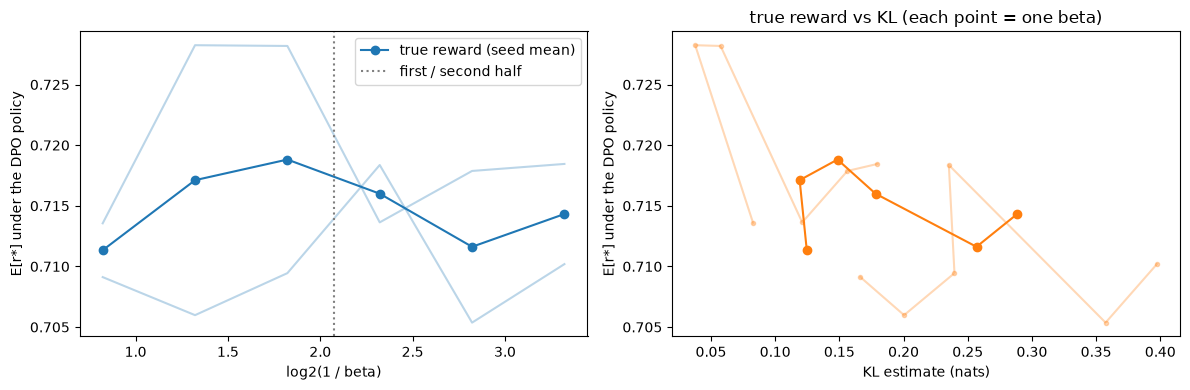

In [16]:
def ols_slope(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    # 最後の軸について y を x に最小二乗で回帰した傾き(y は (..., L))
    x = np.asarray(x, dtype=np.float64)
    xc = x - x.mean()
    return (np.asarray(y) - np.asarray(y).mean(axis=-1, keepdims=True)) @ xc / (xc @ xc)


def three_way_verdict(value: float, sigma: float) -> str:
    # value > 2 sigma: 支持、value < -2 sigma: 反証、それ以外: 判定不能(value は期待する向きが正になるよう渡す)
    if not (math.isfinite(value) and math.isfinite(sigma)):
        return "判定不能"
    if value > 2 * sigma:
        return "支持"
    if value < -2 * sigma:
        return "反証"
    return "判定不能"


_tag = "[スモークテスト・結論ではない] " if SMOKE_TEST else ""
EVAL_BOOTSTRAP_COUNTS = (
    np.random.default_rng(BOOTSTRAP_SEED)
    .multinomial(
        NUM_EVAL_INPUTS, np.full(NUM_EVAL_INPUTS, 1.0 / NUM_EVAL_INPUTS), size=BOOTSTRAP_RESAMPLES
    )
    .astype(np.float64)
)  # (B, |X|)
_per_input = SAMPLES_PER_PROMPT * TASK_COUNT
A_U = np.log2(1.0 / np.array(A_BETAS))  # u_j(昇順)
A_TRUE_BY_INPUT = np.array(
    [[RECORDS[key_a(b, s)]["eval"]["true_reward_by_input"] for b in A_BETAS] for s in SEEDS_A]
)  # (S, L, |X|)
A_KL = np.array([[RECORDS[key_a(b, s)]["eval"]["kl"] for b in A_BETAS] for s in SEEDS_A])  # (S, L)
A_R = A_TRUE_BY_INPUT.sum(axis=2) / (_per_input * NUM_EVAL_INPUTS)  # (S, L) = R_s(beta_j)
A_R_MEAN = A_R.mean(axis=0)
_boot = np.einsum("bx,slx->bl", EVAL_BOOTSTRAP_COUNTS, A_TRUE_BY_INPUT) / (
    _per_input * EVAL_BOOTSTRAP_COUNTS.sum(axis=1)[:, None] * len(SEEDS_A)
)  # (B, L): 再標本ごとのシード平均
_first, _second = slice(0, NUM_A_LEVELS // 2), slice(NUM_A_LEVELS // 2, None)
CONTRAST_A = {}
for _name, _part in (("g1", _first), ("g2", _second)):
    _seed_slopes = ols_slope(A_U[_part], A_R[:, _part])
    _var_boot = float(ols_slope(A_U[_part], _boot[:, _part]).var(ddof=1))
    CONTRAST_A[_name] = {
        "value": float(ols_slope(A_U[_part], A_R_MEAN[_part])),
        "seed_slopes": _seed_slopes.tolist(),
        "var_boot": _var_boot,
        "sigma": math.sqrt(float(np.std(_seed_slopes, ddof=1)) ** 2 / len(SEEDS_A) + _var_boot),
    }
_g1, _g2 = CONTRAST_A["g1"], CONTRAST_A["g2"]
if _g1["value"] > 2 * _g1["sigma"] and _g2["value"] < -2 * _g2["sigma"]:
    verdict_A = "支持"
elif _g2["value"] > 2 * _g2["sigma"]:
    verdict_A = "反証"
else:
    verdict_A = "判定不能"
A_KL_MEAN = A_KL.mean(axis=0)
precondition_status["PA"] = bool(
    A_KL_MEAN[-1] > 0 and A_KL_MEAN[-1] >= KL_RATIO_MIN * max(A_KL_MEAN[0], 0.0)
)
print(
    f"水準 beta_j: {[round(b, 6) for b in A_BETAS]}、u_j = log2(1/beta_j): {A_U.tolist()}、S_A = {len(SEEDS_A)}"
)
print("真の報酬の平均 R(beta_j)(シード平均): " + ", ".join(f"{v:.4f}" for v in A_R_MEAN))
for _name, _label in (("g1", "前半"), ("g2", "後半")):
    _c = CONTRAST_A[_name]
    print(
        f"{_name}({_label}の傾き、u あたり)= {_c['value']:+.5f}、シードごと "
        + ", ".join(f"{v:+.5f}" for v in _c["seed_slopes"])
        + f"、Var_boot = {_c['var_boot']:.3e}、sigma = {_c['sigma']:.5f}、2 sigma = {2 * _c['sigma']:.5f}"
    )
print(
    f"PA: KL(beta_6) = {A_KL_MEAN[-1]:.4f}、KL(beta_1) = {A_KL_MEAN[0]:.4f}、比の下限 {KL_RATIO_MIN} -> "
    f"{'成立' if precondition_status['PA'] else '不成立'}。学習の成立(A): {precondition_status['学習の成立(A)']}"
)
print(f"{_tag}判定関数の結果: {verdict_A}")
_exact = np.array(
    [
        [
            RECORDS[key_a(b, s)]["eval"]["exact_by_input"].sum() / (_per_input * NUM_EVAL_INPUTS)
            for b in A_BETAS
        ]
        for s in SEEDS_A
    ]
)
_length = np.array(
    [
        [
            RECORDS[key_a(b, s)]["eval"]["length_by_input"].sum() / (_per_input * NUM_EVAL_INPUTS)
            for b in A_BETAS
        ]
        for s in SEEDS_A
    ]
)
_eval_pair = [
    [
        pair_statistics(RECORDS[key_a(b, s)]["eval_pairs"], EVAL_PAIR_DATASET["p_hat"])
        for b in A_BETAS
    ]
    for s in SEEDS_A
]
print(
    "診断量(シード平均): "
    + dumps_compact_json(
        {
            "KL": A_KL_MEAN.round(4).tolist(),
            "exact_match_rate": _exact.mean(axis=0).round(4).tolist(),
            "response_tokens": _length.mean(axis=0).round(3).tolist(),
            "eval_pair_margin": np.mean([[p["margin"] for p in row] for row in _eval_pair], axis=0)
            .round(3)
            .tolist(),
            "eval_pair_true_order_agreement": np.mean(
                [[p["accuracy"] for p in row] for row in _eval_pair], axis=0
            )
            .round(4)
            .tolist(),
        }
    )
)

_fig, _axes = plt.subplots(1, 2, figsize=(12, 4))
for _s in range(len(SEEDS_A)):
    _axes[0].plot(A_U, A_R[_s], color="C0", alpha=0.3)
    _axes[1].plot(A_KL[_s], A_R[_s], color="C1", alpha=0.3, marker=".")
_axes[0].plot(A_U, A_R_MEAN, color="C0", marker="o", label="true reward (seed mean)")
_axes[0].axvline(
    (A_U[NUM_A_LEVELS // 2 - 1] + A_U[NUM_A_LEVELS // 2]) / 2,
    color="gray",
    linestyle=":",
    label="first / second half",
)
_axes[0].set_xlabel("log2(1 / beta)")
_axes[0].set_ylabel("E[r*] under the DPO policy")
_axes[0].legend()
_axes[1].plot(A_KL_MEAN, A_R_MEAN, color="C1", marker="o")
_axes[1].set_xlabel("KL estimate (nats)")
_axes[1].set_ylabel("E[r*] under the DPO policy")
_axes[1].set_title("true reward vs KL (each point = one beta)")
plt.tight_layout()
plt.show()

### 6.10 崩壊の領域の観察(判定なし)

**判定基準を設けない観察であり、実験 A の $g_2$ の計算に含めない。** 標準の $\beta$($= \beta_6$)から較正の格子を 2 点・4 点下った
$\beta$(格子の下端を下回る場合は下端。同じ点は 1 つにまとめ、$\beta_6$ と一致する場合は実験 A の学習を共有する)で、DPO・確率的なラベル・シード 0 のみを学習し、実験 A と同じ評価をした(6.8 節)。
KL ダイバージェンスが急増する領域で、真の報酬・応答の長さ・終端記号で止まる割合がどう変わるかを記録する。

シード 0 の実験 A の水準と、崩壊の領域の観察(判定なし): [
  {
    "beta": 0.565685,
    "kind": "A",
    "same_run_as_A": false,
    "true_reward": 0.7091,
    "KL": 0.166,
    "mean_tokens": 13.08,
    "stop_rate": 0.9922,
    "exact_match_rate": 0.0195
  },
  {
    "beta": 0.4,
    "kind": "A",
    "same_run_as_A": false,
    "true_reward": 0.706,
    "KL": 0.2,
    "mean_tokens": 13.14,
    "stop_rate": 0.9883,
    "exact_match_rate": 0.0195
  },
  {
    "beta": 0.282843,
    "kind": "A",
    "same_run_as_A": false,
    "true_reward": 0.7094,
    "KL": 0.24,
    "mean_tokens": 13.19,
    "stop_rate": 0.9805,
    "exact_match_rate": 0.0273
  },
  {
    "beta": 0.2,
    "kind": "A",
    "same_run_as_A": false,
    "true_reward": 0.7184,
    "KL": 0.235,
    "mean_tokens": 12.74,
    "stop_rate": 0.9922,
    "exact_match_rate": 0.0117
  },
  {
    "beta": 0.141421,
    "kind": "A",
    "same_run_as_A": false,
    "true_reward": 0.7054,
    "KL": 0.357,
    "mean_tokens": 12.88,
    "stop_rate": 0.9961,
    "

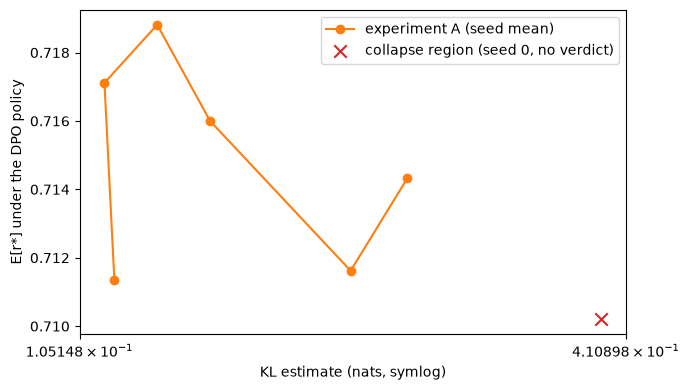

In [17]:
_rows = []
for _beta, _kind in [(b, "A") for b in A_BETAS] + [(b, "collapse") for b in COLLAPSE_BETAS]:
    _e = RECORDS[key_a(_beta, 0)]["eval"]
    _total = _e["count_per_input"] * NUM_EVAL_INPUTS
    _rows.append(
        {
            "beta": round(_beta, 6),
            "kind": _kind,
            "same_run_as_A": _kind == "collapse" and any(math.isclose(_beta, b) for b in A_BETAS),
            "true_reward": round(float(_e["true_reward_by_input"].sum() / _total), 4),
            "KL": round(_e["kl"], 3),
            "mean_tokens": round(_e["mean_tokens"], 2),
            "stop_rate": round(_e["stop_rate"], 4),
            "exact_match_rate": round(float(_e["exact_by_input"].sum() / _total), 4),
        }
    )
print("シード 0 の実験 A の水準と、崩壊の領域の観察(判定なし): " + dumps_compact_json(_rows))
_fig, _ax = plt.subplots(figsize=(7, 4))
_ax.plot(A_KL_MEAN, A_R_MEAN, color="C1", marker="o", label="experiment A (seed mean)")
_collapse = [r for r in _rows if r["kind"] == "collapse"]
_ax.scatter(
    [r["KL"] for r in _collapse],
    [r["true_reward"] for r in _collapse],
    color="C3",
    marker="x",
    s=80,
    label="collapse region (seed 0, no verdict)",
)
_ax.set_xscale("symlog", linthresh=1.0)
_ax.set_xlabel("KL estimate (nats, symlog)")
_ax.set_ylabel("E[r*] under the DPO policy")
_ax.legend()
plt.tight_layout()
plt.show()

### 6.11 実験 B: 決定的なラベルでの過適合(DPO と IPO)

学習用の組を復元抽出するブートストラップの再標本(抽出回数の行列)は、実験 B・C で共通である。

S_B = 2、T/2 = 12、T = 24、beta = tau = 0.1
条件 1(DPO・deterministic): h(T/2) = +1.5115、h(T) = +4.2045、伸び g(シードごと)+2.7895, +2.5963
条件 2(DPO・stochastic): h(T/2) = +0.7046、h(T) = +2.0939、伸び g(シードごと)+1.6824, +1.0963
条件 3(IPO・deterministic): h(T/2) = +1.3506、h(T) = +2.3797、伸び g(シードごと)+1.0741, +0.9840
条件 4(IPO・stochastic): h(T/2) = +0.5891、h(T) = +1.0174、伸び g(シードごと)+0.5302, +0.3264
D = (g1 - g2) - (g3 - g4) = +0.7028、シードごと +0.5631, +0.8424、Var_boot = 8.383e-02、sigma = 0.3214、2 sigma = 0.6429
PB: p_hat が (0, 1) の組の割合(シード順)0.5000, 0.6719(下限 0.4、期待値 0.5961)-> 成立。学習の成立(B・C): True
[スモークテスト・結論ではない] 判定関数の結果: 支持
診断量(シード平均): {
  "condition_1": {"KL": 1.0598, "eval_pair_margin": -0.2381, "final_accuracy": 0.8359},
  "condition_2": {"KL": 0.2885, "eval_pair_margin": -0.0054, "final_accuracy": 0.7773},
  "condition_3": {"KL": 0.3098, "eval_pair_margin": -0.2031, "final_accuracy": 0.9453},
  "condition_4": {"KL": 0.1014, "eval_pair_margin": -0.0471, "final_accuracy": 0.7891}
}


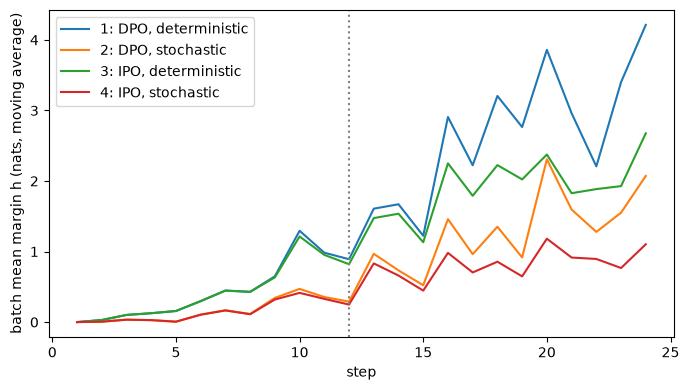

In [18]:
PAIR_BOOTSTRAP_COUNTS = (
    np.random.default_rng(BOOTSTRAP_SEED + 1)
    .multinomial(
        NUM_MAIN_PAIRS, np.full(NUM_MAIN_PAIRS, 1.0 / NUM_MAIN_PAIRS), size=BOOTSTRAP_RESAMPLES
    )
    .astype(np.float32)
)  # (B, N)


def b_contribution(condition: int, seed: int, step: int, quantity: str) -> np.ndarray:
    loss_type, label_kind = B_CONDITIONS[condition]
    record = RECORDS[key_b(condition, seed)]
    p_hat = dataset_for("main", label_kind, seed)["p_hat"]
    return pair_contributions(record["history"]["evaluations"][step], p_hat)[quantity]


# g_{c,s} の組ごとの寄与 (2 p_hat - 1)(h_1(T) - h_1(T/2)) を、条件・シードごとに並べる: (4, S, N)
_growth = np.array(
    [
        [
            b_contribution(c, s, TRAIN_STEPS, "margin") - b_contribution(c, s, HALF_STEP, "margin")
            for s in SEEDS_B
        ]
        for c in B_CONDITIONS
    ]
)
B_GROWTH = _growth.mean(axis=2)  # (4, S) = g_{c,s}
B_D_SEEDS = (B_GROWTH[0] - B_GROWTH[1]) - (B_GROWTH[2] - B_GROWTH[3])  # D_s
_d_pairs = ((_growth[0] - _growth[1]) - (_growth[2] - _growth[3])).mean(
    axis=0
)  # 組ごとの D のシード平均への寄与 (N,)
_boot_d = (PAIR_BOOTSTRAP_COUNTS @ _d_pairs.astype(np.float32)) / NUM_MAIN_PAIRS
CONTRAST_B = {
    "value": float(B_D_SEEDS.mean()),
    "seed_values": B_D_SEEDS.tolist(),
    "var_boot": float(_boot_d.astype(np.float64).var(ddof=1)),
}
CONTRAST_B["sigma"] = math.sqrt(
    float(np.std(B_D_SEEDS, ddof=1)) ** 2 / len(SEEDS_B) + CONTRAST_B["var_boot"]
)
verdict_B = three_way_verdict(CONTRAST_B["value"], CONTRAST_B["sigma"])
B_MIXED = {
    s: float(
        np.mean(
            (dataset_for("main", "stochastic", s)["p_hat"] > 0)
            & (dataset_for("main", "stochastic", s)["p_hat"] < 1)
        )
    )
    for s in SEEDS_B
}
precondition_status["PB"] = bool(min(B_MIXED.values()) >= MIXED_FRACTION_MIN)
_h_bar = {
    (c, step): np.array([b_contribution(c, s, step, "margin").mean() for s in SEEDS_B])
    for c in B_CONDITIONS
    for step in (HALF_STEP, TRAIN_STEPS)
}
print(f"S_B = {len(SEEDS_B)}、T/2 = {HALF_STEP}、T = {TRAIN_STEPS}、beta = tau = {STANDARD_BETA}")
for _c, (_loss, _kind) in B_CONDITIONS.items():
    print(
        f"条件 {_c}({_loss.upper()}・{_kind}): h(T/2) = {_h_bar[(_c, HALF_STEP)].mean():+.4f}、h(T) = "
        f"{_h_bar[(_c, TRAIN_STEPS)].mean():+.4f}、伸び g(シードごと)"
        + ", ".join(f"{v:+.4f}" for v in B_GROWTH[_c - 1])
    )
print(
    f"D = (g1 - g2) - (g3 - g4) = {CONTRAST_B['value']:+.4f}、シードごと "
    + ", ".join(f"{v:+.4f}" for v in B_D_SEEDS)
    + f"、Var_boot = {CONTRAST_B['var_boot']:.3e}、sigma = {CONTRAST_B['sigma']:.4f}、2 sigma = {2 * CONTRAST_B['sigma']:.4f}"
)
print(
    "PB: p_hat が (0, 1) の組の割合(シード順)"
    + ", ".join(f"{v:.4f}" for v in B_MIXED.values())
    + f"(下限 {MIXED_FRACTION_MIN}、期待値 {EXPECTED_MIXED_FRACTION:.4f})-> {'成立' if precondition_status['PB'] else '不成立'}。"
    f"学習の成立(B・C): {precondition_status['学習の成立(B・C)']}"
)
print(f"{_tag}判定関数の結果: {verdict_B}")
print(
    "診断量(シード平均): "
    + dumps_compact_json(
        {
            f"condition_{c}": {
                "KL": round(
                    float(np.mean([RECORDS[key_b(c, s)]["eval"]["kl"] for s in SEEDS_B])), 4
                ),
                "eval_pair_margin": round(
                    float(
                        np.mean(
                            [
                                pair_statistics(
                                    RECORDS[key_b(c, s)]["eval_pairs"], EVAL_PAIR_DATASET["p_hat"]
                                )["margin"]
                                for s in SEEDS_B
                            ]
                        )
                    ),
                    4,
                ),
                "final_accuracy": round(
                    float(np.mean([RECORDS[key_b(c, s)]["final"]["accuracy"] for s in SEEDS_B])), 4
                ),
            }
            for c in B_CONDITIONS
        }
    )
)
_fig, _ax = plt.subplots(figsize=(7, 4))
for _c, (_loss, _kind) in B_CONDITIONS.items():
    _curves = np.array([RECORDS[key_b(_c, s)]["history"]["mean_margin"] for s in SEEDS_B])
    _window = max(1, TRAIN_STEPS // 32)
    _smooth = np.convolve(_curves.mean(axis=0), np.ones(_window) / _window, mode="valid")
    _ax.plot(np.arange(len(_smooth)) + _window, _smooth, label=f"{_c}: {_loss.upper()}, {_kind}")
_ax.axvline(HALF_STEP, color="gray", linestyle=":")
_ax.set_xlabel("step")
_ax.set_ylabel("batch mean margin h (nats, moving average)")
_ax.legend()
plt.tight_layout()
plt.show()

### 6.12 実験 C: 尤度の置き換わりの存在

実験 B の条件 2(DPO・確率的なラベル・標準の $\beta$)の記録を使う(学習を再実行しない)。

選好された応答の対数比の平均 Delta_w(T)(系列単位、nats)= +0.1283、シードごと +0.1422, +0.1145、Var_boot = 5.657e-03、sigma = 0.0765、2 sigma = 0.1530
PC: マージンの平均 h(T)(シード順)+2.4660, +1.7218 > 0 -> 成立。学習の成立(B・C): True
[スモークテスト・結論ではない] 判定関数の結果: 判定不能
診断量(シード平均): {"chosen_log_ratio_per_token": 0.01004, "rejected_log_ratio": -1.9656, "margin": 2.0939}


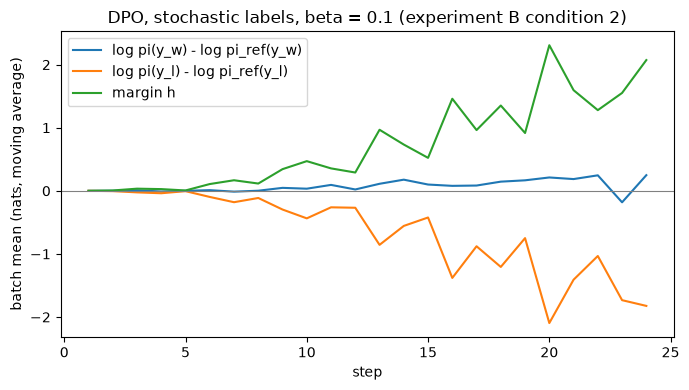

In [19]:
_chosen = np.array(
    [b_contribution(2, s, TRAIN_STEPS, "chosen_log_ratio") for s in SEEDS_B]
)  # (S, N)
C_SEEDS = _chosen.mean(axis=1)
_boot_c = (PAIR_BOOTSTRAP_COUNTS @ _chosen.mean(axis=0).astype(np.float32)) / NUM_MAIN_PAIRS
CONTRAST_C = {
    "value": float(C_SEEDS.mean()),
    "seed_values": C_SEEDS.tolist(),
    "var_boot": float(_boot_c.astype(np.float64).var(ddof=1)),
}
CONTRAST_C["sigma"] = math.sqrt(
    float(np.std(C_SEEDS, ddof=1)) ** 2 / len(SEEDS_B) + CONTRAST_C["var_boot"]
)
verdict_C = three_way_verdict(-CONTRAST_C["value"], CONTRAST_C["sigma"])  # 負の向きが支持
_margins = _h_bar[(2, TRAIN_STEPS)]
precondition_status["PC"] = bool(np.all(_margins > 0))
_dataset = dataset_for("main", "stochastic", 0)
_len_first = np.array([len(r) for r in _dataset["first"]], dtype=np.float64)
_len_second = np.array([len(r) for r in _dataset["second"]], dtype=np.float64)
_per_token = [
    float(
        _chosen[i].sum()
        / (
            dataset_for("main", "stochastic", s)["p_hat"] * _len_first
            + (1 - dataset_for("main", "stochastic", s)["p_hat"]) * _len_second
        ).sum()
    )
    for i, s in enumerate(SEEDS_B)
]
_rejected = np.array(
    [b_contribution(2, s, TRAIN_STEPS, "rejected_log_ratio").mean() for s in SEEDS_B]
)
print(
    f"選好された応答の対数比の平均 Delta_w(T)(系列単位、nats)= {CONTRAST_C['value']:+.4f}、シードごと "
    + ", ".join(f"{v:+.4f}" for v in C_SEEDS)
    + f"、Var_boot = {CONTRAST_C['var_boot']:.3e}、sigma = {CONTRAST_C['sigma']:.4f}、2 sigma = {2 * CONTRAST_C['sigma']:.4f}"
)
print(
    "PC: マージンの平均 h(T)(シード順)"
    + ", ".join(f"{v:+.4f}" for v in _margins)
    + f" > 0 -> {'成立' if precondition_status['PC'] else '不成立'}。学習の成立(B・C): {precondition_status['学習の成立(B・C)']}"
)
print(f"{_tag}判定関数の結果: {verdict_C}")
print(
    "診断量(シード平均): "
    + dumps_compact_json(
        {
            "chosen_log_ratio_per_token": round(float(np.mean(_per_token)), 5),
            "rejected_log_ratio": round(float(_rejected.mean()), 4),
            "margin": round(float(_margins.mean()), 4),
        }
    )
)
_fig, _ax = plt.subplots(figsize=(7, 4))
for _key, _label in (
    ("chosen_log_ratio", "log pi(y_w) - log pi_ref(y_w)"),
    ("rejected_log_ratio", "log pi(y_l) - log pi_ref(y_l)"),
    ("mean_margin", "margin h"),
):
    _curves = np.array([RECORDS[key_b(2, s)]["history"][_key] for s in SEEDS_B]).mean(axis=0)
    _window = max(1, TRAIN_STEPS // 32)
    _ax.plot(
        np.arange(len(_curves) - _window + 1) + _window,
        np.convolve(_curves, np.ones(_window) / _window, mode="valid"),
        label=_label,
    )
_ax.axhline(0, color="gray", linewidth=0.8)
_ax.set_xlabel("step")
_ax.set_ylabel("batch mean (nats, moving average)")
_ax.set_title(f"DPO, stochastic labels, beta = {STANDARD_BETA:g} (experiment B condition 2)")
_ax.legend()
plt.tight_layout()
plt.show()

### 6.13 実験 D: 尤度の置き換わりの類似度依存性

ブートストラップは、各層の中で近い組・遠い組をそれぞれ復元抽出する(層ごとの件数を保つ)。再標本は全シードで共通である。
CHES スコアは参照方策の隠れ状態で計算し、シードごとのラベルの向き($\hat{p}$)で重み付けして平均する。

In [20]:
def stratified_bootstrap_counts(rows: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    # 各層の中で復元抽出した抽出回数の行列 (B, len(rows))
    counts = np.zeros((BOOTSTRAP_RESAMPLES, len(rows)), dtype=np.float32)
    labels = [D_STRATA[r] for r in rows]
    for label in D_COUNTS:
        columns = [j for j, value in enumerate(labels) if value == label]
        if columns:
            counts[:, columns] = rng.multinomial(
                len(columns), np.full(len(columns), 1.0 / len(columns)), size=BOOTSTRAP_RESAMPLES
            )
    return counts


_rng_d = np.random.default_rng(BOOTSTRAP_SEED + 2)
D_BOOTSTRAP_COUNTS = {
    "near": stratified_bootstrap_counts(NEAR_ROWS, _rng_d),
    "far": stratified_bootstrap_counts(FAR_ROWS, _rng_d),
}
_d_chosen = {
    name: np.array(
        [
            pair_contributions(
                RECORDS[key_d(name, s)]["history"]["evaluations"][TRAIN_STEPS],
                dataset_for(name, "stochastic", s)["p_hat"],
            )["chosen_log_ratio"]
            for s in SEEDS_D
        ]
    )
    for name in ("near", "far")
}  # 各 (S, n)
D_SEEDS = _d_chosen["near"].mean(axis=1) - _d_chosen["far"].mean(axis=1)
_boot_e = (D_BOOTSTRAP_COUNTS["near"] @ _d_chosen["near"].mean(axis=0).astype(np.float32)) / len(
    NEAR_ROWS
) - (D_BOOTSTRAP_COUNTS["far"] @ _d_chosen["far"].mean(axis=0).astype(np.float32)) / len(FAR_ROWS)
CONTRAST_D = {
    "value": float(D_SEEDS.mean()),
    "seed_values": D_SEEDS.tolist(),
    "var_boot": float(_boot_e.astype(np.float64).var(ddof=1)),
}
CONTRAST_D["sigma"] = math.sqrt(
    float(np.std(D_SEEDS, ddof=1)) ** 2 / len(SEEDS_D) + CONTRAST_D["var_boot"]
)
verdict_D = three_way_verdict(-CONTRAST_D["value"], CONTRAST_D["sigma"])  # 負の向きが支持
_d_margin = {
    n: np.array([RECORDS[key_d(n, s)]["final"]["margin"] for s in SEEDS_D]) for n in ("near", "far")
}
precondition_status["PD"] = bool(all(np.all(v > 0) for v in _d_margin.values()))

# --- 診断量: CHES スコア・応答の長さ・正規化編集距離 ---
_t0 = time.time()
D_DIAGNOSTICS = {}
for _name in ("near", "far"):
    _ds = dataset_for(_name, "stochastic", SEEDS_D[0])
    _stats = compute_ches_statistics(
        reference_policy, _ds["prompts"], _ds["first"], _ds["second"], device, LOG_PROB_BATCH_SIZE
    )
    _ches, _ches_norm = [], []
    for _s in SEEDS_D:
        _p = dataset_for(_name, "stochastic", _s)["p_hat"]
        _ches.append(
            float(
                np.mean(
                    _p * ches_from_statistics(_stats, np.ones_like(_p, bool))
                    + (1 - _p) * ches_from_statistics(_stats, np.zeros_like(_p, bool))
                )
            )
        )
        _ches_norm.append(
            float(
                np.mean(
                    _p * ches_from_statistics(_stats, np.ones_like(_p, bool), True)
                    + (1 - _p) * ches_from_statistics(_stats, np.zeros_like(_p, bool), True)
                )
            )
        )
    _rows = NEAR_ROWS if _name == "near" else FAR_ROWS
    _lengths = np.concatenate([_stats["length_first"], _stats["length_second"]])
    D_DIAGNOSTICS[_name] = {
        "pairs": len(_rows),
        "normalized_edit_distance": round(
            float(CANDIDATES["distance"][VALID_INDEX[_rows]].mean()), 4
        ),
        "abs_delta_r": round(float(np.abs(VALID_DELTA[_rows]).mean()), 4),
        "ches": round(float(np.mean(_ches)), 2),
        "ches_length_normalized": round(float(np.mean(_ches_norm)), 4),
        "response_tokens_quantiles": np.quantile(_lengths, [0.1, 0.5, 0.9]).tolist(),
        "margin": round(float(_d_margin[_name].mean()), 4),
        "final_accuracy": round(
            float(np.mean([RECORDS[key_d(_name, s)]["final"]["accuracy"] for s in SEEDS_D])), 4
        ),
    }
CHES_SECONDS = time.time() - _t0
print(f"S_D = {len(SEEDS_D)}、近い組 {len(NEAR_ROWS):,}・遠い組 {len(FAR_ROWS):,}")
print(
    f"E = Delta_w(近い組) - Delta_w(遠い組) = {CONTRAST_D['value']:+.4f}、シードごと "
    + ", ".join(f"{v:+.4f}" for v in D_SEEDS)
    + f"、Var_boot = {CONTRAST_D['var_boot']:.3e}、sigma = {CONTRAST_D['sigma']:.4f}、2 sigma = {2 * CONTRAST_D['sigma']:.4f}"
)
print(
    "PD: マージンの平均 h(T) > 0(近い組・遠い組、シード順)"
    + "; ".join(f"{n}: " + ", ".join(f"{v:+.3f}" for v in _d_margin[n]) for n in _d_margin)
    + f" -> {'成立' if precondition_status['PD'] else '不成立'}。学習の成立(D): {precondition_status['学習の成立(D)']}"
)
print(f"{_tag}判定関数の結果: {verdict_D}")
print(
    f"診断量(CHES スコアは参照方策で計算、{CHES_SECONDS:.1f}s): "
    + dumps_compact_json(D_DIAGNOSTICS)
)

S_D = 2、近い組 56・遠い組 56
E = Delta_w(近い組) - Delta_w(遠い組) = -0.0097、シードごと +0.0673, -0.0866、Var_boot = 1.051e-02、sigma = 0.1282、2 sigma = 0.2564
PD: マージンの平均 h(T) > 0(近い組・遠い組、シード順)near: +1.429, +1.123; far: +4.478, +2.854 -> 成立。学習の成立(D): True
[スモークテスト・結論ではない] 判定関数の結果: 判定不能
診断量(CHES スコアは参照方策で計算、0.2s): {
  "near": {
    "pairs": 56,
    "normalized_edit_distance": 0.4015,
    "abs_delta_r": 0.117,
    "ches": -37.71,
    "ches_length_normalized": -2.7582,
    "response_tokens_quantiles": [8.100000000000001, 11.5, 16.0],
    "margin": 1.2759,
    "final_accuracy": 0.7433
  },
  "far": {
    "pairs": 56,
    "normalized_edit_distance": 0.683,
    "abs_delta_r": 0.1609,
    "ches": 20.51,
    "ches_length_normalized": -9.9822,
    "response_tokens_quantiles": [9.0, 13.0, 22.0],
    "margin": 3.6659,
    "final_accuracy": 0.7679
  }
}


### 6.14 不変条件のアサーションと`SMOKE_TEST`の配線

- すべての学習の記録で、ステップ数が $T$、記録されたキーが同じで、学習用の組の評価がステップ $T/2$ と $T$ で行われている。
- 同じシード・同じ大きさのデータの学習は、損失・ラベルの種類・$\beta$ によらず、同じミニバッチの順序を使った(条件間で
  揃えた量)。実験 D の近い組・遠い組は同じ大きさである。
- すべての評価で、同じ評価用のプロンプト・同じサンプル数($m$)を使った。
- 実験 A の水準は格子の連続する 6 点で公比 $\sqrt{2}$、崩壊の領域の観察の 2 学習(シード 0)があり、実験 B の 4 条件と実験 D の 2 データセットがそろっている。
- 参照方策の重みが、すべての学習の後も読み込み直後と bit 単位で一致する(学習が参照方策を書き換えていない)。
- **`SMOKE_TEST`の配線**: 5.2 節で印字した実効水準(シード数・$\beta$ の水準の数・ステップ数・$K$・データ量)と、実際に使われた
  値(history の長さ・ラベルの行列の形・学習の数)が一致する。

In [21]:
_keys = set(RECORDS[next(iter(RECORDS))]["history"])
for _key, _r in RECORDS.items():
    _h = _r["history"]
    assert set(_h) == _keys, _key
    assert all(len(_h[k]) == TRAIN_STEPS for k in _keys if k != "evaluations"), _key
    assert set(_h["evaluations"]) == {HALF_STEP, TRAIN_STEPS}, _key
    assert _r["eval"]["count_per_input"] == SAMPLES_PER_PROMPT * TASK_COUNT
    assert len(_r["eval"]["true_reward_by_input"]) == NUM_EVAL_INPUTS
_by_seed_size: dict = {}
for _key, _r in RECORDS.items():
    _size = len(dataset_for(_r["dataset"], _r["label_kind"], _r["seed"])["instances"]["prompts"])
    _by_seed_size.setdefault((_r["seed"], _size), set()).add(_r["batches_hash"])
assert all(len(v) == 1 for v in _by_seed_size.values()), (
    "同じシード・同じ大きさで異なるミニバッチの順序がある"
)
assert len(NEAR_ROWS) == len(FAR_ROWS)
assert len(A_BETAS) == NUM_A_LEVELS and len(B_CONDITIONS) == 4
assert all(math.isclose(a / b, math.sqrt(2.0)) for a, b in zip(A_BETAS, A_BETAS[1:], strict=False))
assert all(
    b <= min(A_BETAS) for b in COLLAPSE_BETAS
)  # 格子の下端で打ち切った点は beta_6 と一致しうる
_expected_runs = len(
    {key_a(b, s) for b in A_BETAS for s in SEEDS_A}
    | {key_a(b, 0) for b in COLLAPSE_BETAS}
    | {key_b(c, s) for c in B_CONDITIONS for s in SEEDS_B}
    | {key_d(n, s) for n in ("near", "far") for s in SEEDS_D}
)
assert len(RECORDS) == _expected_runs, (len(RECORDS), _expected_runs)
assert all(v.shape == (len(VALID_INDEX), NUM_DRAWS) for v in STOCHASTIC_LABELS.values())
assert DETERMINISTIC_LABELS.shape == (len(VALID_INDEX), NUM_DRAWS)
assert all(len(v["pair_indices"]) == NUM_MAIN_PAIRS for k, v in _datasets.items() if k[0] == "main")
_state_after = reference_policy.state_dict()
assert all(torch.equal(_state_after[k].cpu(), REFERENCE_STATE[k]) for k in REFERENCE_STATE), (
    "参照方策の重みが変わった"
)
print(
    f"不変条件: 全 {len(RECORDS)} 学習の history の長さ {TRAIN_STEPS}・キー {sorted(_keys)}・評価のステップ {HALF_STEP}, {TRAIN_STEPS}、"
    "同じシード・同じ大きさのミニバッチの順序が共通、評価のプロンプトとサンプル数が共通、参照方策の重みが不変: OK"
)
_effective = {
    "level": CURRENT_LEVEL_NAME,
    "seeds": {"A": len(SEEDS_A), "B": len(SEEDS_B), "D": len(SEEDS_D)},
    "a_levels": len(A_BETAS),
    "train_steps": TRAIN_STEPS,
    "num_draws": NUM_DRAWS,
    "main_pairs": NUM_MAIN_PAIRS,
    "candidate_pairs": NUM_CANDIDATE_PAIRS,
    "eval_inputs": NUM_EVAL_INPUTS,
}
_used = {
    "level": CURRENT_LEVEL_NAME,
    "seeds": {
        "A": len({s for s in SEEDS_A if all(key_a(b, s) in RECORDS for b in A_BETAS)}),
        "B": len({k[4] for k in RECORDS if k[0] == "ipo"}),
        "D": len({k[4] for k in RECORDS if k[2] == "near"}),
    },
    "a_levels": len({b for b in A_BETAS if all(key_a(b, s) in RECORDS for s in SEEDS_A)}),
    "train_steps": len(next(iter(RECORDS.values()))["history"]["loss"]),
    "num_draws": STOCHASTIC_LABELS[0].shape[1],
    "main_pairs": len(dataset_for("main", "stochastic", 0)["pair_indices"]),
    "candidate_pairs": len(CANDIDATES["first"]),
    "eval_inputs": len(next(iter(RECORDS.values()))["eval"]["true_reward_by_input"]),
}
assert _used == _effective, (_used, _effective)
assert (CURRENT_LEVEL_NAME == "smoke") == SMOKE_TEST
print(
    f"SMOKE_TEST={SMOKE_TEST} の配線: 実効水準 {json.dumps(_effective)} と実際に使われた値が一致: OK"
)

不変条件: 全 22 学習の history の長さ 24・キー ['accuracy', 'chosen_log_ratio', 'evaluations', 'learning_rate', 'loss', 'mean_margin', 'rejected_log_ratio', 'step']・評価のステップ 12, 24、同じシード・同じ大きさのミニバッチの順序が共通、評価のプロンプトとサンプル数が共通、参照方策の重みが不変: OK
SMOKE_TEST=True の配線: 実効水準 {"level": "smoke", "seeds": {"A": 2, "B": 2, "D": 2}, "a_levels": 6, "train_steps": 24, "num_draws": 4, "main_pairs": 64, "candidate_pairs": 256, "eval_inputs": 8} と実際に使われた値が一致: OK


### 6.15 判定結果の一覧

前提条件が 1 つでも不成立の実験は、判定関数の結果に関わらず「前提不成立」とする(判定不能とは区別する)。判定関数の結果は
参考として別欄に残す。選ばれた段階と、判定に実際に使ったシード数・水準を印字する。

In [22]:
def verdict_label(computed: str, preconditions: list[str]) -> str:
    return computed if all(precondition_status.get(p) for p in preconditions) else "前提不成立"


print(f"{_tag}段階の選択: {STAGE_SELECTION_MESSAGE}")
print(
    f"{_tag}判定に使った値: S_A = {len(SEEDS_A)}、S_B = {len(SEEDS_B)}、S_D = {len(SEEDS_D)}、beta の水準 "
    f"{[round(b, 6) for b in A_BETAS]}、T = {TRAIN_STEPS}、K = {NUM_DRAWS}、N = {NUM_MAIN_PAIRS}"
)
_rows = [
    (
        "A",
        f"g1 = {CONTRAST_A['g1']['value']:+.5f}(sigma {CONTRAST_A['g1']['sigma']:.5f})、g2 = {CONTRAST_A['g2']['value']:+.5f}(sigma {CONTRAST_A['g2']['sigma']:.5f})",
        ["学習の成立(A)", "PA"],
        verdict_A,
    ),
    (
        "B",
        f"D = {CONTRAST_B['value']:+.4f}(sigma {CONTRAST_B['sigma']:.4f})",
        ["学習の成立(B・C)", "PB"],
        verdict_B,
    ),
    (
        "C",
        f"Delta_w(T) = {CONTRAST_C['value']:+.4f}(sigma {CONTRAST_C['sigma']:.4f})",
        ["学習の成立(B・C)", "PC"],
        verdict_C,
    ),
    (
        "D",
        f"E = {CONTRAST_D['value']:+.4f}(sigma {CONTRAST_D['sigma']:.4f})",
        ["学習の成立(D)", "PD"],
        verdict_D,
    ),
]
print(f"{_tag}実験 | 対比量 | 前提条件 | 判定関数の結果 | 最終判定")
for _name, _value, _pre, _computed in _rows:
    print(
        f"{_tag}{_name} | {_value} | "
        + ", ".join(f"{p}={precondition_status.get(p)}" for p in _pre)
        + f" | {_computed} | {verdict_label(_computed, _pre)}"
    )
print(f"\nノートブック全体の実行時間: {(time.time() - NOTEBOOK_START_TIME) / 60:.1f} 分")

[スモークテスト・結論ではない] 段階の選択: 段階 3 でも見積もり 151.7 分が予算 120.0 分を超える(本番なら学習の前に停止する)。スモークテストのため停止せず、段階 3 で動作確認を続ける
[スモークテスト・結論ではない] 判定に使った値: S_A = 2、S_B = 2、S_D = 2、beta の水準 [0.565685, 0.4, 0.282843, 0.2, 0.141421, 0.1]、T = 24、K = 4、N = 64
[スモークテスト・結論ではない] 実験 | 対比量 | 前提条件 | 判定関数の結果 | 最終判定
[スモークテスト・結論ではない] A | g1 = +0.00748(sigma 0.00808)、g2 = -0.00168(sigma 0.00968) | 学習の成立(A)=True, PA=False | 判定不能 | 前提不成立
[スモークテスト・結論ではない] B | D = +0.7028(sigma 0.3214) | 学習の成立(B・C)=True, PB=True | 支持 | 支持
[スモークテスト・結論ではない] C | Delta_w(T) = +0.1283(sigma 0.0765) | 学習の成立(B・C)=True, PC=True | 判定不能 | 判定不能
[スモークテスト・結論ではない] D | E = -0.0097(sigma 0.1282) | 学習の成立(D)=True, PD=True | 判定不能 | 判定不能

ノートブック全体の実行時間: 3.6 分


## 7. 結果・考察 / Results and Discussion

**本番実行(Google Colab T4)の後に、セル出力と突き合わせて記述する。** 以下は各節に何を書くかの一覧である。
判定は 6.1 節で事前に宣言した基準のみから導き、結果を見た後に立てた解釈は 7.7 節に分けて記す。

### 7.1 実行の概要

- 実行環境(5.1 節の印字: GPU・torch・CUDA・コミット・実行日時)、参照方策の照合の値(5.5 節)、決定的な実行の確認(5.8 節)。
- 段階の見積もりと選ばれた段階(6.4 節)、実際の実行時間。
- 較正で決まった標準の $\beta$・実験 A の水準・崩壊の領域の観察の水準と、較正の診断量(応答の長さ・終端記号で止まる割合)。
- 選好の組の統計(除外の割合・$\kappa$・$\hat{p} \in (0, 1)$ の期待値と実際の割合)と実験 D の層(6.5 節)。
- キャッシュの確認(6.6 節)と $\beta$ の較正の結果(6.7 節、KL のみ)・選ばれた実験 A の水準と実験 B との共有の有無。

### 7.2 前提条件

- 学習の成立(実験ごと)・PA・PB・PC・PD の値と成否の表。

### 7.3 実験 A: 直接選好最適化の過最適化

- $g_1$・$g_2$・標準偏差・判定。真の報酬と KL の図の読み取り。
- 崩壊の領域の観察(6.10 節、判定なし): 真の報酬・KL・応答の長さ・終端記号で止まる割合・完全一致の割合の記述。017 の best-of-n・PPO との定性的な比較(KL の範囲の違いに注意)。

### 7.4 実験 B: 決定的なラベルでの過適合

- 4 条件の $\bar{h}(T/2)$・$\bar{h}(T)$・伸び、$D$・標準偏差・判定。マージンの推移の図の読み取り。IPO の目標値 $1/(2\tau)$ との比較。

### 7.5 実験 C: 尤度の置き換わりの存在

- $\bar{\Delta}_w(T)$・標準偏差・判定。トークンあたりの値、選好されなかった応答の対数比、マージンとの関係。

### 7.6 実験 D: 尤度の置き換わりの類似度依存性

- $E$・標準偏差・判定。CHES スコア・応答の長さ・正規化編集距離の診断量(編集距離が CHES スコアの代理として働いたか)。

### 7.7 事後的な解釈(検証済みの結論ではない)

- 想定と異なる結果があれば、結果を見た後の解釈をここに分けて記す。

### 7.8 まとめ

- 判定の一覧と、DPO・IPO の振る舞いについて本トピックの設定から言えること・言えないこと。

### 本番実行の後に更新が必要な箇所

- 7 節の全体(上の箇条書きを、本番のセル出力に基づく本文に置き換える。崩壊の領域の観察の結果の記述を含む)。
- 1 節の概要に結果の要約が必要なら追記する。
- `theories/README.md`の 018 の行に本番の結果の要約を追記する。
- 実行環境が変わった場合は、5.5 節の照合の許容(完全一致率 ±0.005・負の対数尤度 ±0.0005)の範囲で 017 の値と一致したかを 7.1 節に記す。